## Import 

In [5]:
import sys
from pathlib import Path

# Add src directory to path
notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent
src_dir = parent_dir / 'src'
sys.path.insert(0, str(src_dir))

import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Working directory: {Path.cwd()}")
print(f"Source directory: {src_dir}")

Libraries imported successfully!
Working directory: d:\Tsinghua Classes and Papers\Network Science\migra-net-china\Clean Code
Source directory: d:\Tsinghua Classes and Papers\Network Science\migra-net-china\src


## Get Files and Graphs

In [6]:
from graph import create_undirected_graph

# Load geo data to map prefecture codes to names
geo_file_path = notebook_dir / 'df_sin_geo.csv'
df_geo = pd.read_csv(geo_file_path, on_bad_lines='skip')

# Create mappings for all three granularities
code_to_name_prefecture = dict(zip(df_geo['Code_Perfecture'].astype(str), df_geo['Name_Perfecture']))
code_to_name_county = dict(zip(df_geo['Code_County'].astype(str), df_geo['Name_County']))
code_to_name_province = dict(zip(df_geo['Code_Province'].astype(str), df_geo['Name_Province']))

# Helper functions to get names from codes
def get_city_name(code):
    """Convert prefecture code to readable name"""
    code_str = str(code)
    return code_to_name_prefecture.get(code_str, code_str)

def get_county_name(code):
    """Convert county code to readable name"""
    code_str = str(code)
    return code_to_name_county.get(code_str, code_str)

def get_province_name(code):
    """Convert province code to readable name"""
    code_str = str(code)
    return code_to_name_province.get(code_str, code_str)

# Configure matplotlib to display Chinese characters
# Try to find and use an available Chinese font
from matplotlib.font_manager import FontManager

fm = FontManager()
chinese_fonts = []

# Search for common Chinese fonts
font_names_to_try = ['Microsoft YaHei', 'SimHei', 'STSong', 'KaiTi', 'FangSong', 
                      'PingFang SC', 'Heiti SC', 'WenQuanYi Zen Hei', 'Noto Sans CJK SC']

for font_name in font_names_to_try:
    if any(font_name.lower() in f.name.lower() for f in fm.ttflist):
        chinese_fonts.append(font_name)

if chinese_fonts:
    plt.rcParams['font.sans-serif'] = chinese_fonts + ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    print(f"Found Chinese fonts: {chinese_fonts[:3]}")
    print(f"Using font: {chinese_fonts[0]}")
else:
    print("Warning: No Chinese fonts found. Will use codes in plots.")

print(f"\nLoaded geo data:")
print(f"  {len(code_to_name_prefecture)} prefecture codes mapped to names")
print(f"  {len(code_to_name_county)} county codes mapped to names")
print(f"  {len(code_to_name_province)} province codes mapped to names")
print(f"\nSample prefecture mappings:")
for i, (code, name) in enumerate(list(code_to_name_prefecture.items())[:3]):
    print(f"  {code} -> {name}")

Found Chinese fonts: ['Microsoft YaHei', 'SimHei', 'KaiTi']
Using font: Microsoft YaHei

Loaded geo data:
  347 prefecture codes mapped to names
  2901 county codes mapped to names
  34 province codes mapped to names

Sample prefecture mappings:
  1101 -> 北京市
  1201 -> 天津市
  1307 -> 张家口市


## Network Metrics

In [7]:
# ========== HELPER FUNCTIONS FOR NETWORK METRICS ==========

def compute_global_metrics(G):
    """
    Compute basic topological properties of the network.
    """
    metrics = {}
    
    # Basic properties
    metrics['n_nodes'] = G.number_of_nodes()
    metrics['n_edges'] = G.number_of_edges()
    
    if metrics['n_nodes'] <= 1:
        return metrics
    
    # Density and degree
    metrics['density'] = nx.density(G)
    degrees = [d for n, d in G.degree()]
    metrics['avg_degree'] = np.mean(degrees) if degrees else 0
    metrics['max_degree'] = max(degrees) if degrees else 0
    
    # Path length and diameter (on largest connected component)
    if nx.is_connected(G):
        metrics['avg_path_length'] = nx.average_shortest_path_length(G)
        metrics['diameter'] = nx.diameter(G)
        metrics['lcc_fraction'] = 1.0
        subgraph = G  # Use full graph for efficiency calculations
    else:
        # Get largest connected component
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        if len(largest_cc) > 1:
            metrics['avg_path_length'] = nx.average_shortest_path_length(subgraph)
            metrics['diameter'] = nx.diameter(subgraph)
        else:
            metrics['avg_path_length'] = 0
            metrics['diameter'] = 0
        metrics['lcc_fraction'] = len(largest_cc) / metrics['n_nodes']
    
    # Clustering
    metrics['avg_clustering'] = nx.average_clustering(G)
    metrics['transitivity'] = nx.transitivity(G)
    
    # Assortativity
    try:
        metrics['assortativity'] = nx.degree_assortativity_coefficient(G)
    except:
        metrics['assortativity'] = np.nan
    
    # ========== NEW METRICS ==========
    
    # 1. Average Efficiency (Global and Local)
    try:
        metrics['global_efficiency'] = nx.global_efficiency(G)
        metrics['avg_local_efficiency'] = nx.local_efficiency(G)
    except:
        metrics['global_efficiency'] = np.nan
        metrics['avg_local_efficiency'] = np.nan
    
    # 2. Average Closeness Centrality
    try:
        closeness = nx.closeness_centrality(G)
        metrics['avg_closeness_centrality'] = np.mean(list(closeness.values()))
    except:
        metrics['avg_closeness_centrality'] = np.nan
    
    # 3. Average Node Betweenness Centrality
    try:
        betweenness = nx.betweenness_centrality(G)
        metrics['avg_betweenness_centrality'] = np.mean(list(betweenness.values()))
    except:
        metrics['avg_betweenness_centrality'] = np.nan
    
    # 4. Average Radiality
    try:
        if len(subgraph) > 1 and metrics['diameter'] > 0:
            # Compute radiality for each node in the largest connected component
            # Radiality(v) = (diameter + 1 - ecc(v)) / (n - 1)
            # where ecc(v) is the eccentricity of node v
            eccentricity = nx.eccentricity(subgraph)
            n = len(subgraph)
            diameter = metrics['diameter']
            radiality_values = [(diameter + 1 - ecc) / (n - 1) for ecc in eccentricity.values()]
            metrics['avg_radiality'] = np.mean(radiality_values)
        else:
            metrics['avg_radiality'] = np.nan
    except:
        metrics['avg_radiality'] = np.nan
    
    # 5. Local Community Paradigm Correlation (if applicable)
    # This metric measures correlation between local clustering and community structure
    try:
        # Detect communities using Louvain algorithm
        if G.number_of_edges() > 0:
            communities = nx.community.louvain_communities(G)
            
            # Create community assignment for each node
            community_map = {}
            for idx, comm in enumerate(communities):
                for node in comm:
                    community_map[node] = idx
            
            # Compute local clustering coefficient for each node
            local_clustering = nx.clustering(G)
            
            # For each node, compute the fraction of neighbors in the same community
            intra_community_fraction = {}
            for node in G.nodes():
                neighbors = list(G.neighbors(node))
                if len(neighbors) > 0:
                    same_community = sum(1 for n in neighbors if community_map.get(n) == community_map.get(node))
                    intra_community_fraction[node] = same_community / len(neighbors)
                else:
                    intra_community_fraction[node] = 0
            
            # Compute correlation between local clustering and intra-community fraction
            clustering_vals = [local_clustering[n] for n in G.nodes()]
            intra_comm_vals = [intra_community_fraction[n] for n in G.nodes()]
            
            if len(clustering_vals) > 1:
                correlation = np.corrcoef(clustering_vals, intra_comm_vals)[0, 1]
                metrics['local_community_paradigm_corr'] = correlation
            else:
                metrics['local_community_paradigm_corr'] = np.nan
        else:
            metrics['local_community_paradigm_corr'] = np.nan
    except:
        metrics['local_community_paradigm_corr'] = np.nan
    
    return metrics


def detect_communities(G):
    """
    Detect communities using Louvain algorithm (or greedy modularity as fallback).
    Returns partition dict and modularity score.
    """
    try:
        import community as community_louvain
        partition = community_louvain.best_partition(G, weight='weight', random_state=8) #6
        modularity = community_louvain.modularity(partition, G, weight='weight')
    except ImportError:
        # Fallback to greedy modularity
        communities = nx.community.greedy_modularity_communities(G, weight='weight')
        partition = {}
        for i, community in enumerate(communities):
            for node in community:
                partition[node] = i
        modularity = nx.community.modularity(G, communities, weight='weight')
    
    return partition, modularity


def compute_hub_measures(G, partition):
    """
    Compute gateway-ness (B), provincial-ness (Z), and connector-ness (P)
    for all nodes in the network.
    """
    measures = {}
    
    # Group nodes by community
    communities = defaultdict(list)
    for node, comm in partition.items():
        communities[comm].append(node)
    
    for node in G.nodes():
        node_comm = partition[node]
        neighbors = list(G.neighbors(node))
        
        if len(neighbors) == 0:
            measures[node] = {'B': 0, 'Z': 0, 'P': 0}
            continue
        
        # Count inside-module and outside-module connections
        k_inside = sum(1 for n in neighbors if partition[n] == node_comm)
        k_outside = sum(1 for n in neighbors if partition[n] != node_comm)
        
        # Compute Z-score for inside-module degree (Provincial-ness)
        community_nodes = communities[node_comm]
        k_inside_values = []
        for n in community_nodes:
            if n in G:
                n_neighbors = list(G.neighbors(n))
                k_inside_n = sum(1 for nn in n_neighbors if partition[nn] == node_comm)
                k_inside_values.append(k_inside_n)
        
        if len(k_inside_values) > 1:
            mean_k_inside = np.mean(k_inside_values)
            std_k_inside = np.std(k_inside_values)
            Z = (k_inside - mean_k_inside) / std_k_inside if std_k_inside > 0 else 0
        else:
            Z = 0
        
        # Compute Z-score for outside-module degree (Gateway-ness)
        k_outside_values = []
        for n in community_nodes:
            if n in G:
                n_neighbors = list(G.neighbors(n))
                k_outside_n = sum(1 for nn in n_neighbors if partition[nn] != node_comm)
                k_outside_values.append(k_outside_n)
        
        if len(k_outside_values) > 1:
            mean_k_outside = np.mean(k_outside_values)
            std_k_outside = np.std(k_outside_values)
            B = (k_outside - mean_k_outside) / std_k_outside if std_k_outside > 0 else 0
        else:
            B = 0
        
        # Compute participation coefficient (Connector-ness)
        k_total = len(neighbors)
        k_per_module = defaultdict(int)
        for n in neighbors:
            k_per_module[partition[n]] += 1
        
        P = 1 - sum((k_s / k_total) ** 2 for k_s in k_per_module.values())
        
        measures[node] = {'B': B, 'Z': Z, 'P': P}
    
    return measures


def classify_hubs(hub_measures, B_threshold=1.5, Z_threshold=1.5, P_threshold=0.7):
    """
    Classify nodes as gateway, provincial, or connector hubs.
    """
    gateway_hubs = []
    provincial_hubs = []
    connector_hubs = []
    
    for node, measures in hub_measures.items():
        if measures['B'] >= B_threshold:
            gateway_hubs.append(node)
        if measures['Z'] >= Z_threshold:
            provincial_hubs.append(node)
        if measures['P'] >= P_threshold:
            connector_hubs.append(node)
    
    return {
        'gateway': gateway_hubs,
        'provincial': provincial_hubs,
        'connector': connector_hubs
    }


def get_graph(graphs_dict, granularity, years=None):
    """
    Retrieve a graph from the pre-generated graphs dictionary.

    Args:
        graphs_dict: Dictionary containing pre-generated graphs
        granularity: "county", "prefecture", or "province"
        years: list of years, or None for all years combined

    Returns:
        NetworkX graph
    """
    if years is None:
        year_key = 'all'
    elif isinstance(years, list) and len(years) == 1:
        year_key = years[0]
    else:
        # For multiple years, need to create on the fly (shouldn't happen if we pre-generate properly)
        year_key = str(years)

    graph = graphs_dict.get(granularity, {}).get(year_key)
    if graph is None:
        print(f"Warning: Graph not found for granularity={granularity}, years={years}")
    return graph

print("Helper functions defined successfully!")

Helper functions defined successfully!


## Pre-Generate All Networks

To avoid redundant network creation, we pre-generate all networks we'll need for the analysis.

In [4]:
# ============================================================================
# PRE-GENERATE ALL NETWORKS
# ============================================================================

print("\n" + "="*80)
print("PRE-GENERATING ALL NETWORKS")
print("="*80)

# Define granularities and years to pre-generate
granularities = ["county", "prefecture", "province"]
sample_years = list(range(1980, 2017))

# Initialize graphs dictionary
# Structure: graphs[granularity][year_key] = G
# where year_key is either 'all' or a specific year (e.g., 2000)
graphs = {granularity: {} for granularity in granularities}

# Generate graphs for all years combined
print("\nGenerating graphs for all years combined...")
for granularity in granularities:
    print(f"  {granularity}...", end=" ")
    G = create_undirected_graph(granularity=granularity, years=None)
    graphs[granularity]['all'] = G
    print(f"✓ ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")

# Generate graphs for individual years
print("\nGenerating graphs for individual years...")
for granularity in tqdm(granularities, desc="Granularities"):
    for year in sample_years:
        G = create_undirected_graph(granularity=granularity, years=[year])
        graphs[granularity][year] = G

print("\n" + "="*80)
print("GRAPH GENERATION COMPLETE")
print("="*80)
print(f"\nTotal graphs created: {sum(len(graphs[g]) for g in granularities)}")
print("\nGraphs available:")
for granularity in granularities:
    n_graphs = len(graphs[granularity])
    print(f"  {granularity}: {n_graphs} graphs")
    # Show sample
    all_graph = graphs[granularity]['all']
    print(f"    - All years: {all_graph.number_of_nodes()} nodes, {all_graph.number_of_edges()} edges")
    if sample_years:
        sample_graph = graphs[granularity][sample_years[0]]
        print(f"    - {sample_years[0]}: {sample_graph.number_of_nodes()} nodes, {sample_graph.number_of_edges()} edges")

print("\n✓ All networks pre-generated and stored in 'graphs' dictionary")


PRE-GENERATING ALL NETWORKS

Generating graphs for all years combined...
  county... ✓ (2697 nodes, 83069 edges)
  prefecture... ✓ (331 nodes, 16518 edges)
  province... ✓ (31 nodes, 465 edges)

Generating graphs for individual years...


Granularities: 100%|██████████| 3/3 [12:31<00:00, 250.62s/it]


GRAPH GENERATION COMPLETE

Total graphs created: 114

Graphs available:
  county: 38 graphs
    - All years: 2697 nodes, 83069 edges
    - 1980: 240 nodes, 133 edges
  prefecture: 38 graphs
    - All years: 331 nodes, 16518 edges
    - 1980: 130 nodes, 104 edges
  province: 38 graphs
    - All years: 31 nodes, 465 edges
    - 1980: 30 nodes, 55 edges

✓ All networks pre-generated and stored in 'graphs' dictionary


In [ ]:
#save the graphs as a pickle files for later use
import pickle
with open('pre_generated_graphs.pkl', 'wb') as f:
    pickle.dump(graphs, f)

In [2]:
import pickle

print("\n" + "="*80)
print("LOADING PRE-GENERATED GRAPHS")
print("="*80)

# Load the pre-generated graphs from pickle file
pickle_file = 'pre_generated_graphs.pkl'
print(f"\nLoading graphs from {pickle_file}...")

with open(pickle_file, 'rb') as f:
    graphs = pickle.load(f)

# Define granularities for reference
granularities = ["county", "prefecture", "province"]
sample_years = list(range(1980, 2017))

print("\n" + "="*80)
print("GRAPHS LOADED SUCCESSFULLY")
print("="*80)
print(f"\nTotal graphs loaded: {sum(len(graphs[g]) for g in granularities)}")

print("\nGraphs available:")
for granularity in granularities:
    n_graphs = len(graphs[granularity])
    print(f"  {granularity}: {n_graphs} graphs")
    # Show sample
    all_graph = graphs[granularity]['all']
    print(f"    - All years: {all_graph.number_of_nodes()} nodes, {all_graph.number_of_edges()} edges")
    if sample_years:
        sample_graph = graphs[granularity][sample_years[0]]
        print(f"    - {sample_years[0]}: {sample_graph.number_of_nodes()} nodes, {sample_graph.number_of_edges()} edges")

print("\n✓ All networks loaded and stored in 'graphs' dictionary")


LOADING PRE-GENERATED GRAPHS

Loading graphs from pre_generated_graphs.pkl...

GRAPHS LOADED SUCCESSFULLY

Total graphs loaded: 114

Graphs available:
  county: 38 graphs
    - All years: 2697 nodes, 83069 edges
    - 1980: 240 nodes, 133 edges
  prefecture: 38 graphs
    - All years: 331 nodes, 16518 edges
    - 1980: 130 nodes, 104 edges
  province: 38 graphs
    - All years: 31 nodes, 465 edges
    - 1980: 30 nodes, 55 edges

✓ All networks loaded and stored in 'graphs' dictionary


In [10]:
# ========== MAIN COMPUTATION FUNCTION ==========
#Node Betweenness centrality, Degree Centrality, 
def compute_all_metrics_for_config(granularity, years=None, G=None):
    """
    Compute all network metrics for a given granularity and year(s).
    
    Args:
        granularity: "county", "prefecture", or "province"
        years: list of years, or None for all years combined
        G: Pre-generated graph (optional). If None, will create graph on the fly.
        
    Returns:
        Dictionary with all computed metrics
    """
    print(f"\nComputing metrics for granularity={granularity}, years={years}")
    
    # Use pre-generated graph if provided, otherwise create it
    if G is None:
        print("  Creating graph...")
        G = create_undirected_graph(granularity=granularity, years=years)
    else:
        print("  Using pre-generated graph...")
    
    if G.number_of_nodes() < 10:
        print(f"  Warning: Graph has only {G.number_of_nodes()} nodes, skipping analysis")
        return None
    
    print(f"  Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    results = {
        'granularity': granularity,
        'years': str(years) if years else 'all'
    }
    
    # 1. Global metrics
    print("  Computing global metrics...")
    global_metrics = compute_global_metrics(G)
    results.update(global_metrics)
    
    # 2. Community detection
    print("  Detecting communities...")
    partition, modularity = detect_communities(G)
    n_communities = len(set(partition.values()))
    results['modularity'] = modularity
    results['n_communities'] = n_communities
    
    # 3. Hub measures
    print("  Computing hub measures...")
    hub_measures = compute_hub_measures(G, partition)
    hub_classification = classify_hubs(hub_measures)
    results['n_gateway_hubs'] = len(hub_classification['gateway'])
    results['n_provincial_hubs'] = len(hub_classification['provincial'])
    results['n_connector_hubs'] = len(hub_classification['connector'])
    
    # Store top hubs
    top_B = sorted(hub_measures.items(), key=lambda x: x[1]['B'], reverse=True)[:5]
    top_Z = sorted(hub_measures.items(), key=lambda x: x[1]['Z'], reverse=True)[:5]
    top_P = sorted(hub_measures.items(), key=lambda x: x[1]['P'], reverse=True)[:5]
    
    results['top_gateway_hubs'] = [str(node) for node, _ in top_B]
    results['top_provincial_hubs'] = [str(node) for node, _ in top_Z]
    results['top_connector_hubs'] = [str(node) for node, _ in top_P]
    
    print(f"  ✓ Completed: Q={modularity:.3f}, {n_communities} communities")
    
    return results


def compute_metrics_across_granularities_and_years(granularities, year_list=None, graphs_dict=None):
    """
    Compute metrics across different granularities and years.
    
    Args:
        granularities: list of granularities ["county", "prefecture", "province"]
        year_list: list of years to analyze, or None for aggregate only
        graphs_dict: Pre-generated graphs dictionary (optional)
        
    Returns:
        DataFrame with all metrics
    """
    all_results = []
    
    # Compute for each granularity with all years combined
    print("\n" + "="*60)
    print("COMPUTING METRICS FOR ALL YEARS COMBINED")
    print("="*60)
    for granularity in granularities:
        # Get pre-generated graph if available
        G = get_graph(graphs_dict, granularity, years=None) if graphs_dict else None
        result = compute_all_metrics_for_config(granularity, years=None, G=G)
        if result:
            all_results.append(result)
    
    # Compute for each granularity and year combination
    if year_list:
        print("\n" + "="*60)
        print("COMPUTING METRICS FOR INDIVIDUAL YEARS")
        print("="*60)
        for granularity in granularities:
            for year in year_list:
                # Get pre-generated graph if available
                G = get_graph(graphs_dict, granularity, years=[year]) if graphs_dict else None
                result = compute_all_metrics_for_config(granularity, years=[year], G=G)
                if result:
                    result['year'] = year
                    all_results.append(result)
    
    # Convert to DataFrame
    df = pd.DataFrame(all_results)
    
    # Reorder columns
    priority_cols = ['granularity', 'years', 'year', 'n_nodes', 'n_edges', 'density', 
                 'avg_degree', 'modularity', 'n_communities',
                 'avg_clustering', 'transitivity', 'assortativity',
                 'avg_path_length', 'diameter', 'lcc_fraction',
                 'global_efficiency', 'avg_local_efficiency',
                 'avg_closeness_centrality', 'avg_betweenness_centrality', 
                 'avg_radiality', 'local_community_paradigm_corr']
    other_cols = [col for col in df.columns if col not in priority_cols]
    df = df[[col for col in priority_cols if col in df.columns] + other_cols]
    
    return df

print("Main computation functions defined!")

Main computation functions defined!


## Compute Metrics for All Granularities and Years

Using the pre-generated graphs to compute all network metrics efficiently.

In [11]:
# Compute metrics across all configurations using pre-generated graphs
metrics_df = compute_metrics_across_granularities_and_years(
    granularities=granularities,
    year_list=sample_years,
    graphs_dict=graphs  # Pass the pre-generated graphs
)

# Display summary
print("\n" + "="*80)
print("METRICS SUMMARY")
print("="*80)
display(metrics_df[['granularity', 'years', 'year', 'n_nodes', 'n_edges', 'density', 
                     'modularity', 'n_communities', 'n_gateway_hubs', 
                     'n_provincial_hubs', 'n_connector_hubs']])

# Save to CSV
metrics_df.to_csv('network_metrics_all_granularities.csv', index=False)
print("\n✓ Results saved to: network_metrics_all_granularities.csv")

# Display full dataframe
metrics_df


COMPUTING METRICS FOR ALL YEARS COMBINED

Computing metrics for granularity=county, years=None
  Using pre-generated graph...
  Graph: 2697 nodes, 83069 edges
  Computing global metrics...
  Detecting communities...
  Computing hub measures...
  ✓ Completed: Q=0.549, 13 communities

Computing metrics for granularity=prefecture, years=None
  Using pre-generated graph...
  Graph: 331 nodes, 16518 edges
  Computing global metrics...
  Detecting communities...
  Computing hub measures...
  ✓ Completed: Q=0.461, 7 communities

Computing metrics for granularity=province, years=None
  Using pre-generated graph...
  Graph: 31 nodes, 465 edges
  Computing global metrics...
  Detecting communities...
  Computing hub measures...
  ✓ Completed: Q=0.282, 4 communities

COMPUTING METRICS FOR INDIVIDUAL YEARS

Computing metrics for granularity=county, years=[1980]
  Using pre-generated graph...
  Graph: 240 nodes, 133 edges
  Computing global metrics...
  Detecting communities...
  Computing hub mea

,granularity,years,year,n_nodes,n_edges,density,modularity,n_communities,n_gateway_hubs,n_provincial_hubs,n_connector_hubs
0,county,all,NaN,2697,83069,0.022849,0.549270,13,173,206,910
1,prefecture,all,NaN,331,16518,0.302444,0.460997,7,32,30,278
2,province,all,NaN,31,465,1.000000,0.281931,4,0,0,0
3,county,[1980],1980.0,240,133,0.004637,0.986941,107,0,3,0
4,county,[1981],1981.0,161,85,0.006599,0.985467,76,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
109,province,[2012],2012.0,31,409,0.879570,0.268232,4,1,0,11
110,province,[2013],2013.0,31,412,0.886022,0.283855,4,2,0,27
111,province,[2014],2014.0,31,417,0.896774,0.286653,4,0,0,3
112,province,[2015],2015.0,31,426,0.916129,0.268775,4,0,0,22



✓ Results saved to: network_metrics_all_granularities.csv


,granularity,years,year,n_nodes,n_edges,density,avg_degree,modularity,n_communities,avg_clustering,...,avg_betweenness_centrality,avg_radiality,local_community_paradigm_corr,max_degree,n_gateway_hubs,n_provincial_hubs,n_connector_hubs,top_gateway_hubs,top_provincial_hubs,top_connector_hubs
0,county,all,NaN,2697,83069,0.022849,61.601038,0.549270,13,0.305133,...,0.000480,0.000770,0.462306,1242,173,206,910,"[110105, 440306, 310115, 110108, 440307]","[110105, 110108, 440306, 440111, 410105]","[429006, 350305, 110105, 511902, 610924]"
1,prefecture,all,NaN,331,16518,0.302444,99.806647,0.460997,7,0.587380,...,0.002124,0.005511,0.614556,309,32,30,278,"[4403, 1101, 2101, 4401, 5001]","[5001, 4403, 4401, 4406, 1101]","[1501, 1201, 1101, 1301, 1401]"
2,province,all,NaN,31,465,1.000000,30.000000,0.281931,4,1.000000,...,0.000000,0.033333,NaN,30,0,0,0,"[36, 44, 51, 35, 23]","[36, 44, 51, 35, 23]","[36, 44, 51, 35, 45]"
3,county,[1980],1980.0,240,133,0.004637,1.108333,0.986941,107,0.000000,...,0.000011,0.250000,NaN,4,0,3,0,"[511323, 150981, 500231, 532501, 150924]","[310101, 622921, 450205, 150981, 520181]","[511323, 150981, 500231, 532501, 150924]"
4,county,[1981],1981.0,161,85,0.006599,1.055901,0.985467,76,0.000000,...,0.000005,0.500000,NaN,2,0,0,0,"[520525, 520201, 320804, 321322, 140321]","[520201, 640381, 340826, 150923, 654002]","[520525, 520201, 320804, 321322, 140321]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,province,[2012],2012.0,31,409,0.879570,26.387097,0.268232,4,0.907292,...,0.004153,0.041935,0.239792,30,1,0,11,"[41, 13, 37, 35, 42]","[41, 65, 61, 62, 43]","[15, 64, 65, 62, 11]"
110,province,[2013],2013.0,31,412,0.886022,26.580645,0.283855,4,0.903168,...,0.003930,0.040860,0.176699,30,2,0,27,"[42, 44, 41, 51, 37]","[43, 53, 42, 44, 52]","[65, 22, 21, 64, 13]"
111,province,[2014],2014.0,31,417,0.896774,26.903226,0.286653,4,0.914864,...,0.003560,0.041935,0.161884,30,0,0,3,"[34, 61, 11, 37, 41]","[11, 12, 37, 23, 21]","[14, 12, 22, 63, 15]"
112,province,[2015],2015.0,31,426,0.916129,27.483871,0.268775,4,0.926242,...,0.002892,0.041935,0.198422,30,0,0,22,"[11, 13, 41, 44, 42]","[51, 44, 43, 35, 36]","[54, 64, 14, 12, 22]"


## Visualization: Metrics Across Granularities

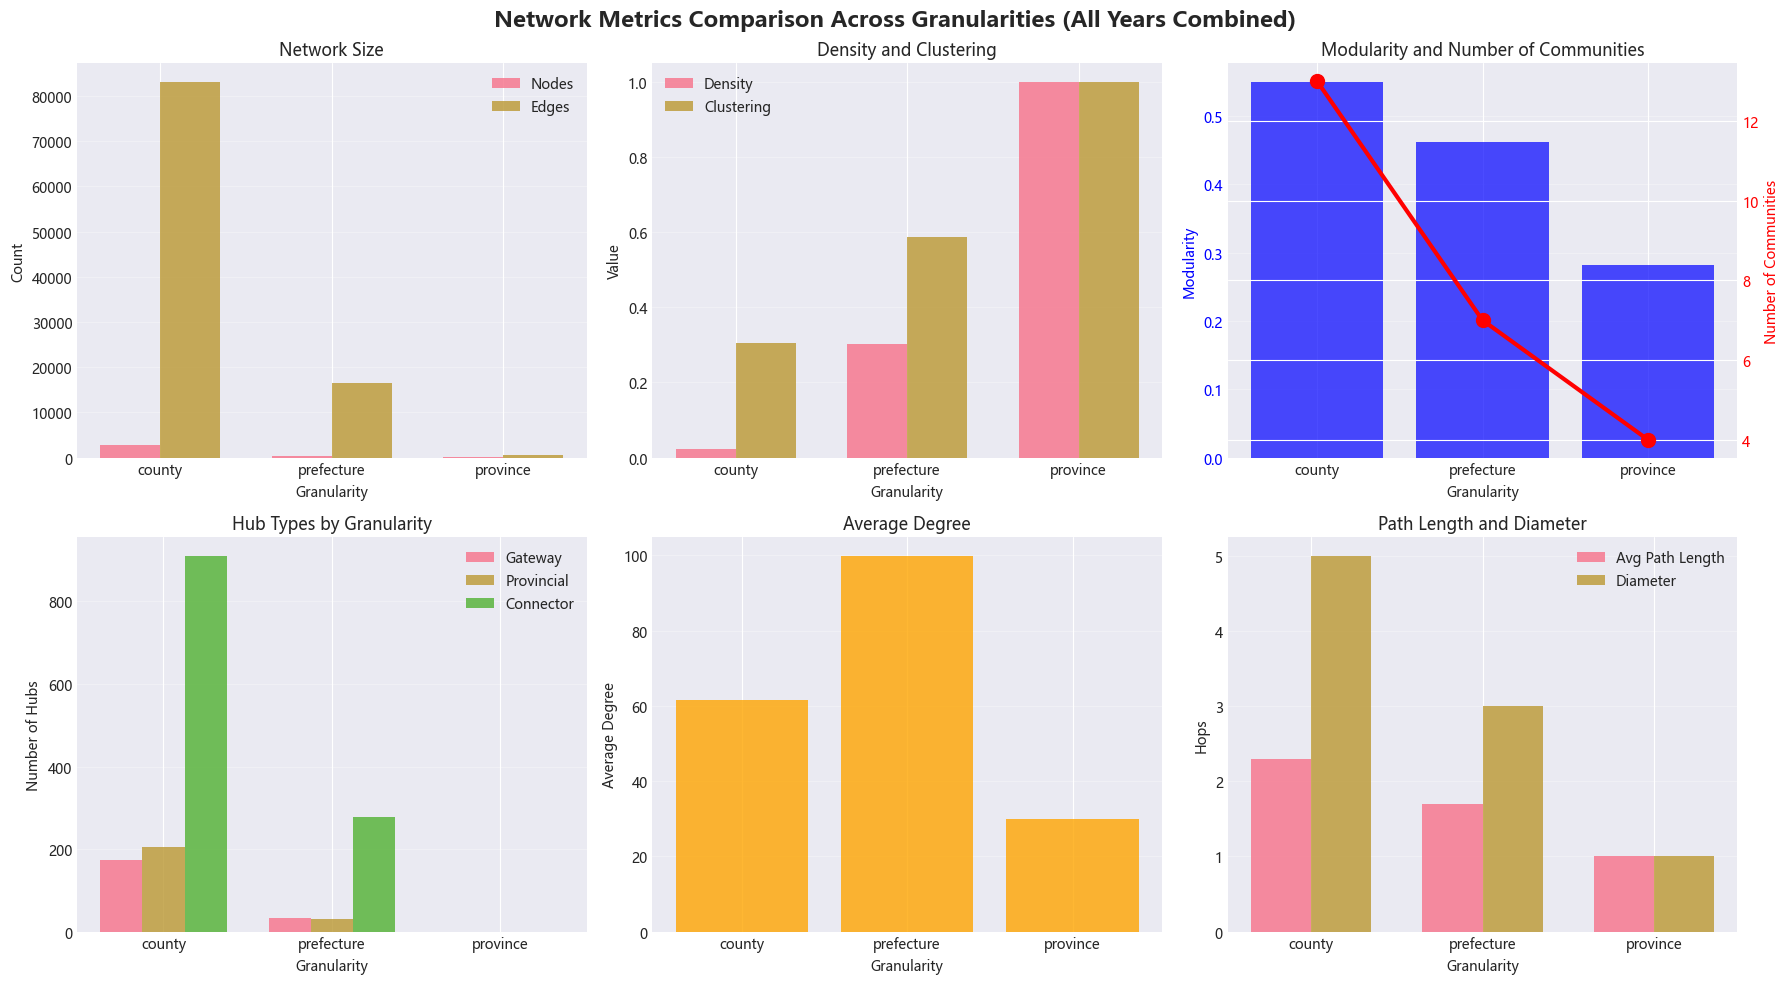

In [13]:
# Filter for aggregate data (all years combined)
aggregate_df = metrics_df[metrics_df['years'] == 'all'].copy()

# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Network Metrics Comparison Across Granularities (All Years Combined)', 
             fontsize=16, fontweight='bold')

# 1. Network size
ax = axes[0, 0]
x = range(len(aggregate_df))
width = 0.35
ax.bar([i - width/2 for i in x], aggregate_df['n_nodes'], width, label='Nodes', alpha=0.8)
ax.bar([i + width/2 for i in x], aggregate_df['n_edges'], width, label='Edges', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Network Size')
ax.set_ylabel('Count')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Density and clustering
ax = axes[0, 1]
x = range(len(aggregate_df))
width = 0.35
ax.bar([i - width/2 for i in x], aggregate_df['density'], width, label='Density', alpha=0.8)
ax.bar([i + width/2 for i in x], aggregate_df['avg_clustering'], width, label='Clustering', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Density and Clustering')
ax.set_ylabel('Value')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Modularity and communities
ax = axes[0, 2]
ax2 = ax.twinx()
x = range(len(aggregate_df))
ax.bar(x, aggregate_df['modularity'], color='blue', alpha=0.7, label='Modularity')
ax2.plot(x, aggregate_df['n_communities'], color='red', marker='o', 
         markersize=10, linewidth=3, label='Communities')
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Modularity and Number of Communities')
ax.set_ylabel('Modularity', color='blue')
ax2.set_ylabel('Number of Communities', color='red')
ax.set_xlabel('Granularity')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax.grid(axis='y', alpha=0.3)

# 4. Hub counts
ax = axes[1, 0]
x = range(len(aggregate_df))
width = 0.25
ax.bar([i - width for i in x], aggregate_df['n_gateway_hubs'], width, 
       label='Gateway', alpha=0.8)
ax.bar(x, aggregate_df['n_provincial_hubs'], width, 
       label='Provincial', alpha=0.8)
ax.bar([i + width for i in x], aggregate_df['n_connector_hubs'], width, 
       label='Connector', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Hub Types by Granularity')
ax.set_ylabel('Number of Hubs')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 5. Average degree
ax = axes[1, 1]
x = range(len(aggregate_df))
ax.bar(x, aggregate_df['avg_degree'], alpha=0.8, color='orange')
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Average Degree')
ax.set_ylabel('Average Degree')
ax.set_xlabel('Granularity')
ax.grid(axis='y', alpha=0.3)

# 6. Average path length and diameter
ax = axes[1, 2]
x = range(len(aggregate_df))
width = 0.35
ax.bar([i - width/2 for i in x], aggregate_df['avg_path_length'], width, 
       label='Avg Path Length', alpha=0.8)
ax.bar([i + width/2 for i in x], aggregate_df['diameter'], width, 
       label='Diameter', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Path Length and Diameter')
ax.set_ylabel('Hops')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

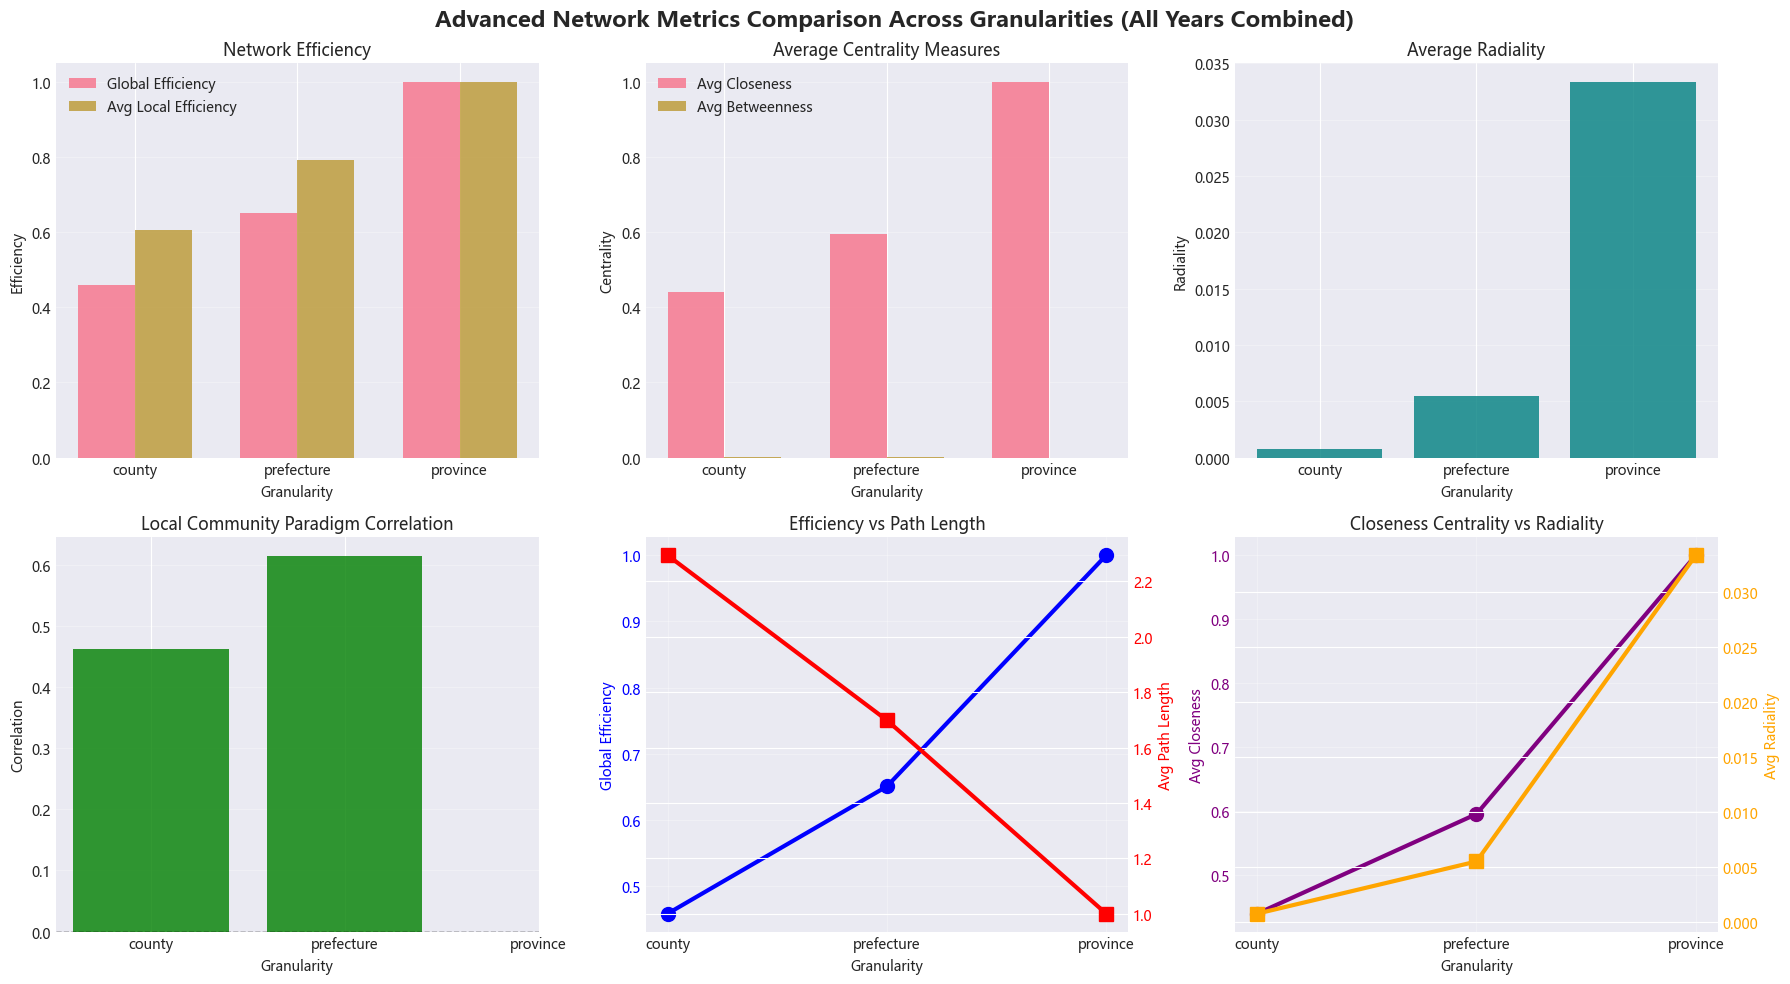

In [14]:
# ============================================================================
# NEW VISUALIZATION: Advanced Network Metrics
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Advanced Network Metrics Comparison Across Granularities (All Years Combined)', 
             fontsize=16, fontweight='bold')

# Plot 1: Efficiency Metrics
ax = axes[0, 0]
x = range(len(aggregate_df))
width = 0.35
ax.bar([i - width/2 for i in x], aggregate_df['global_efficiency'], width, 
       label='Global Efficiency', alpha=0.8)
ax.bar([i + width/2 for i in x], aggregate_df['avg_local_efficiency'], width, 
       label='Avg Local Efficiency', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Network Efficiency')
ax.set_ylabel('Efficiency')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Centrality Metrics
ax = axes[0, 1]
x = range(len(aggregate_df))
width = 0.35
ax.bar([i - width/2 for i in x], aggregate_df['avg_closeness_centrality'], width, 
       label='Avg Closeness', alpha=0.8)
ax.bar([i + width/2 for i in x], aggregate_df['avg_betweenness_centrality'], width, 
       label='Avg Betweenness', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Average Centrality Measures')
ax.set_ylabel('Centrality')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: Radiality
ax = axes[0, 2]
x = range(len(aggregate_df))
ax.bar(x, aggregate_df['avg_radiality'], alpha=0.8, color='teal')
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Average Radiality')
ax.set_ylabel('Radiality')
ax.set_xlabel('Granularity')
ax.grid(axis='y', alpha=0.3)

# Plot 4: Local Community Paradigm Correlation
ax = axes[1, 0]
x = range(len(aggregate_df))
colors = ['green' if v >= 0 else 'red' for v in aggregate_df['local_community_paradigm_corr']]
ax.bar(x, aggregate_df['local_community_paradigm_corr'], alpha=0.8, color=colors)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Local Community Paradigm Correlation')
ax.set_ylabel('Correlation')
ax.set_xlabel('Granularity')
ax.grid(axis='y', alpha=0.3)

# Plot 5: Comparison - Efficiency vs Path Length
ax = axes[1, 1]
ax2 = ax.twinx()
x = range(len(aggregate_df))
ax.plot(x, aggregate_df['global_efficiency'], color='blue', marker='o', 
        markersize=10, linewidth=3, label='Global Efficiency')
ax2.plot(x, aggregate_df['avg_path_length'], color='red', marker='s', 
         markersize=10, linewidth=3, label='Avg Path Length')
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Efficiency vs Path Length')
ax.set_ylabel('Global Efficiency', color='blue')
ax2.set_ylabel('Avg Path Length', color='red')
ax.set_xlabel('Granularity')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax.grid(alpha=0.3)

# Plot 6: Comparison - Centrality vs Radiality
ax = axes[1, 2]
ax2 = ax.twinx()
x = range(len(aggregate_df))
ax.plot(x, aggregate_df['avg_closeness_centrality'], color='purple', marker='o', 
        markersize=10, linewidth=3, label='Closeness')
ax2.plot(x, aggregate_df['avg_radiality'], color='orange', marker='s', 
         markersize=10, linewidth=3, label='Radiality')
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Closeness Centrality vs Radiality')
ax.set_ylabel('Avg Closeness', color='purple')
ax2.set_ylabel('Avg Radiality', color='orange')
ax.set_xlabel('Granularity')
ax.tick_params(axis='y', labelcolor='purple')
ax2.tick_params(axis='y', labelcolor='orange')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization: Temporal Evolution by Granularity

Visualize how metrics evolve over time for each granularity level.


TEMPORAL EVOLUTION ANALYSIS


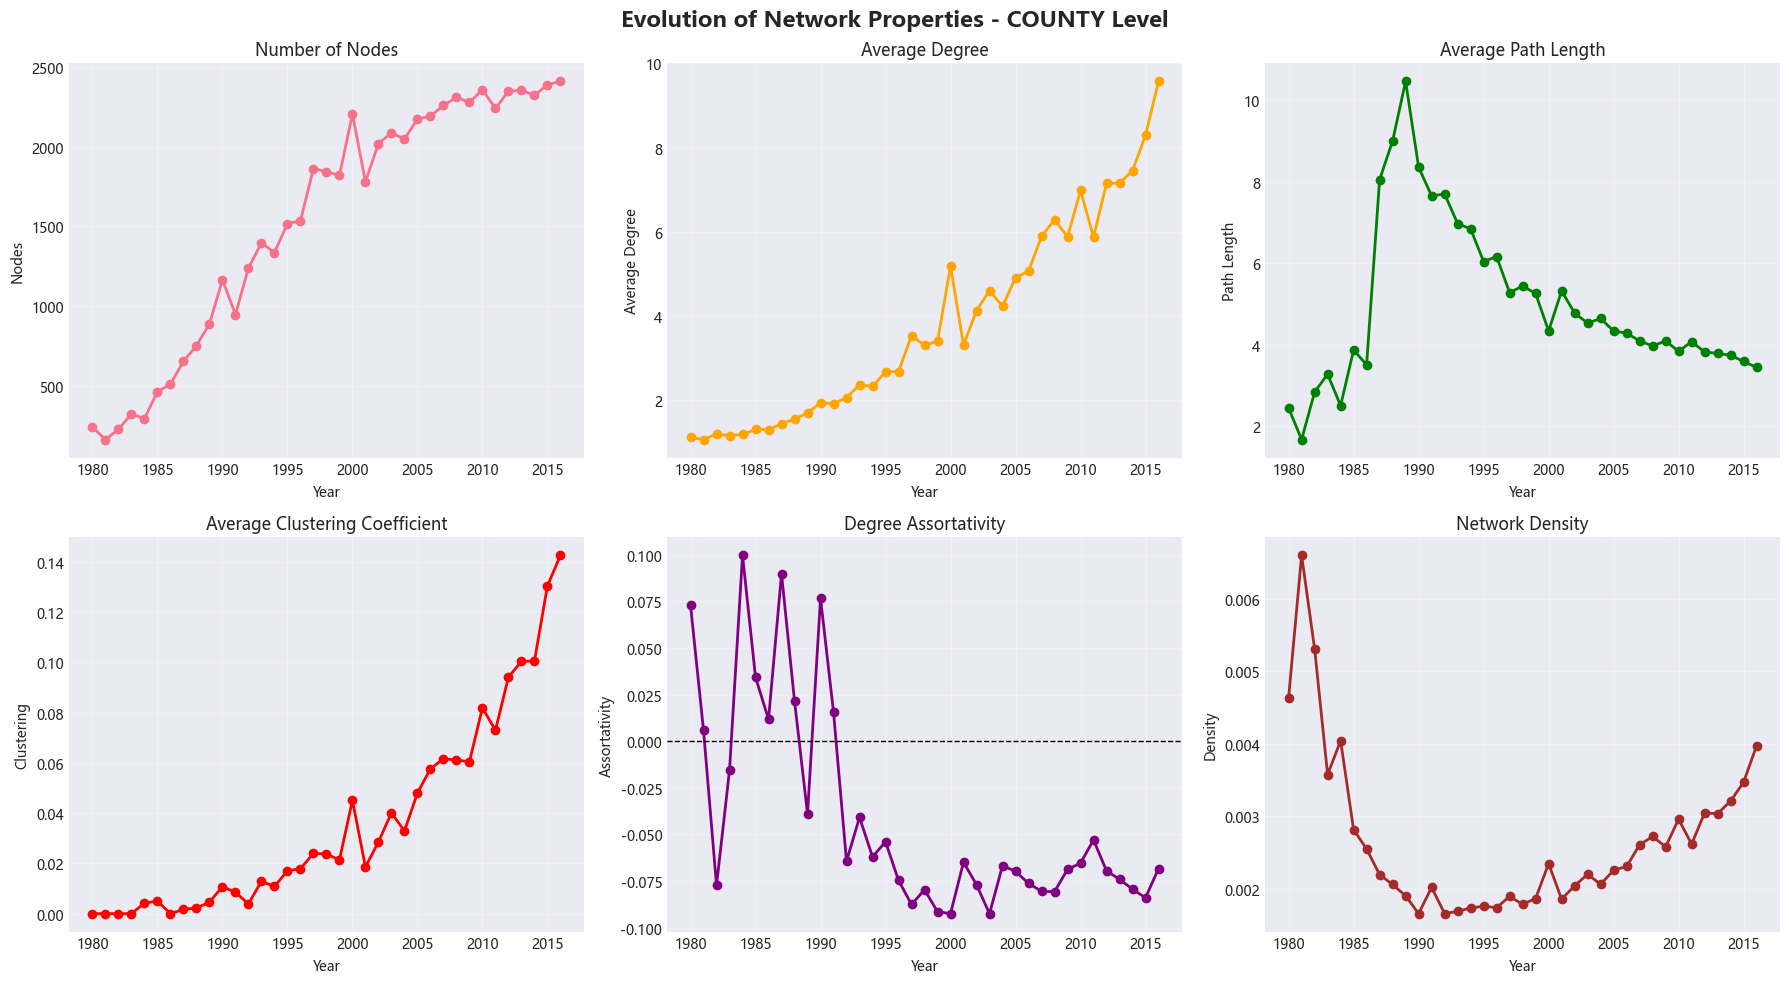

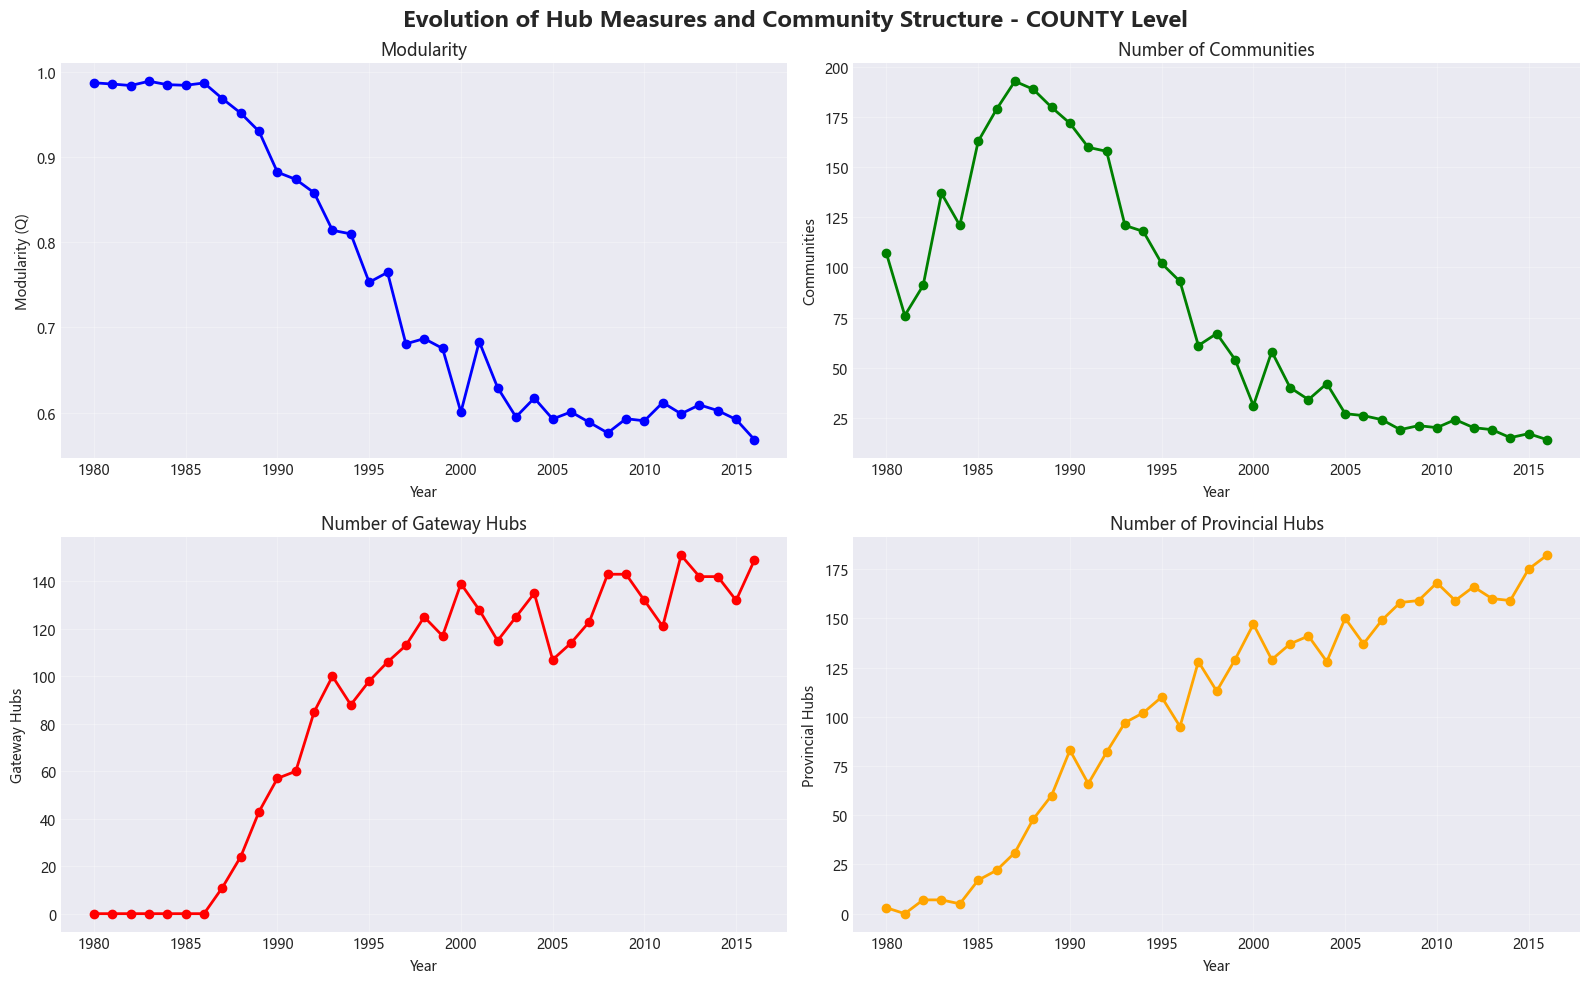

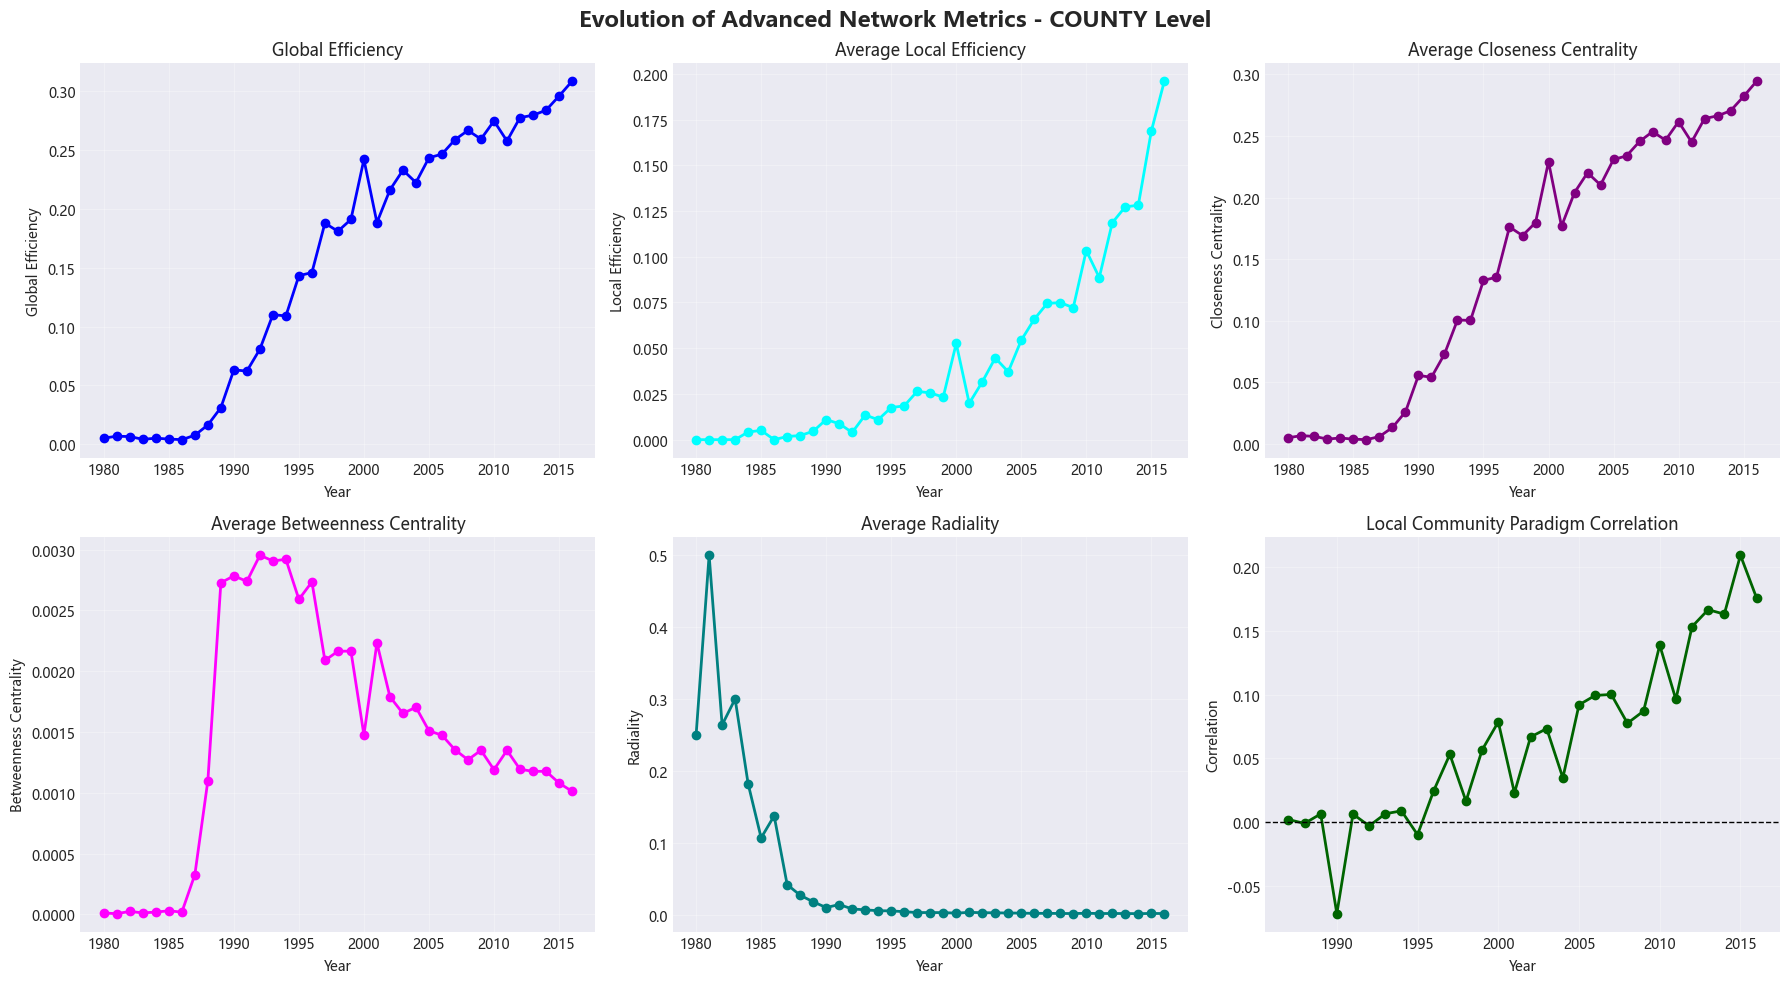

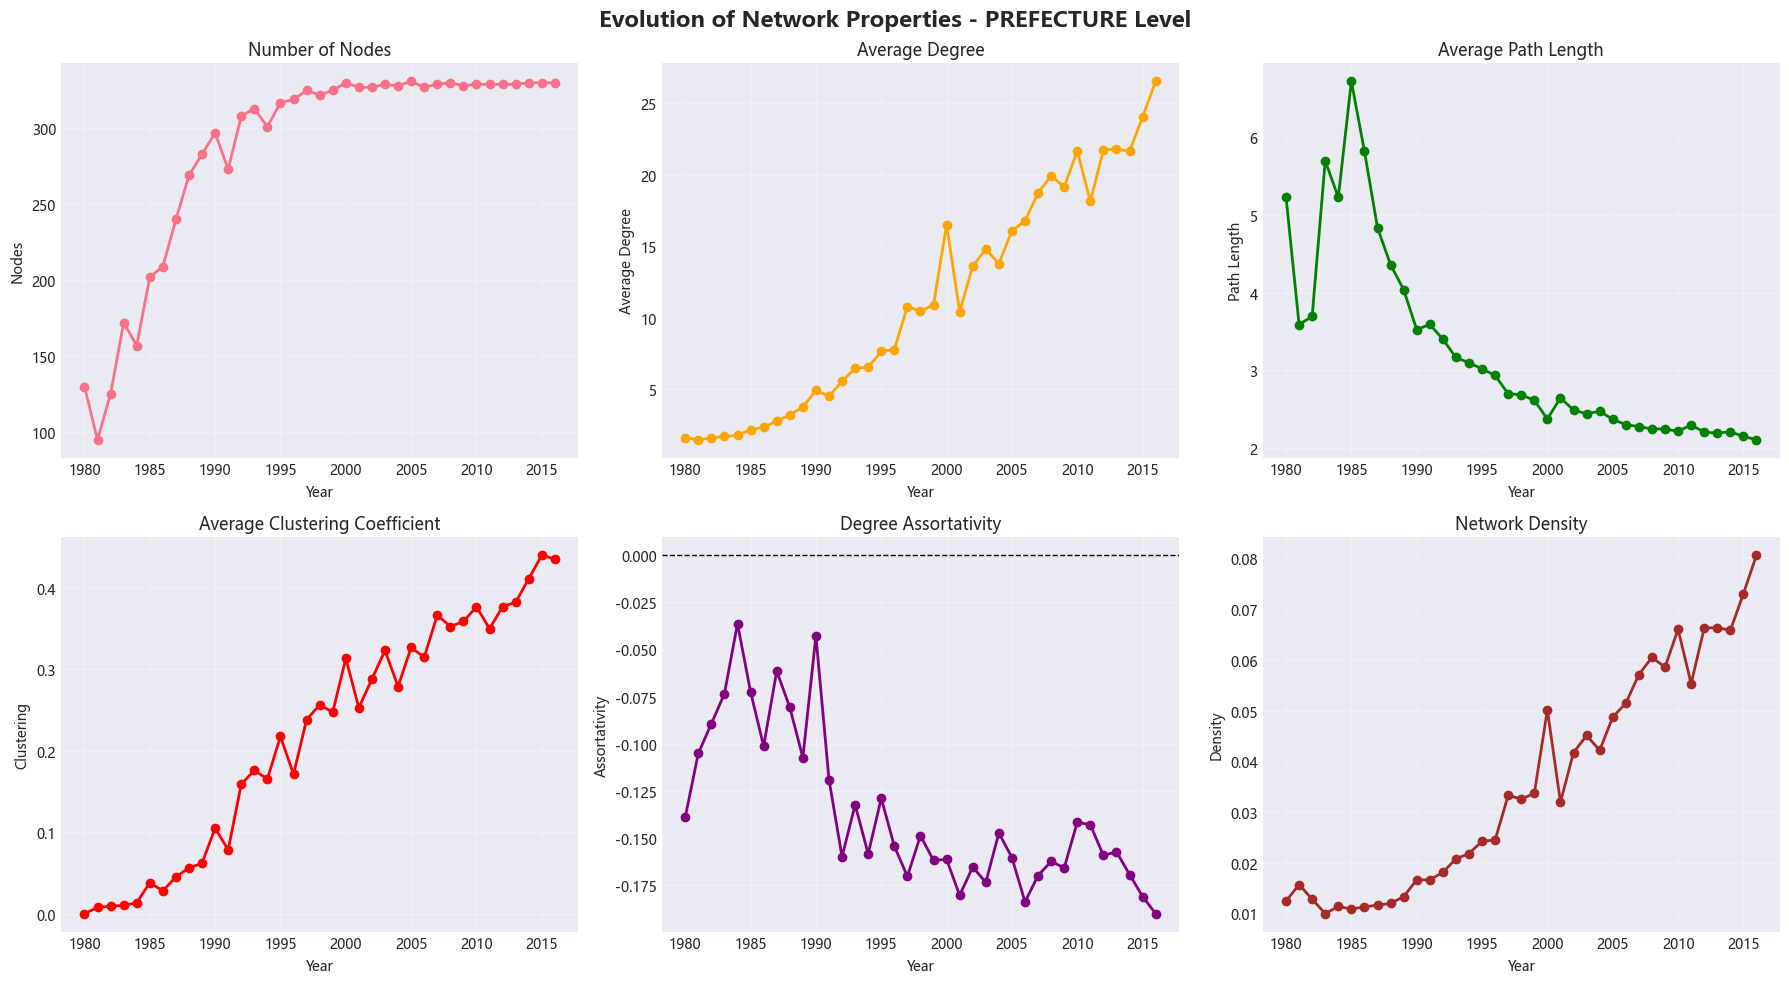

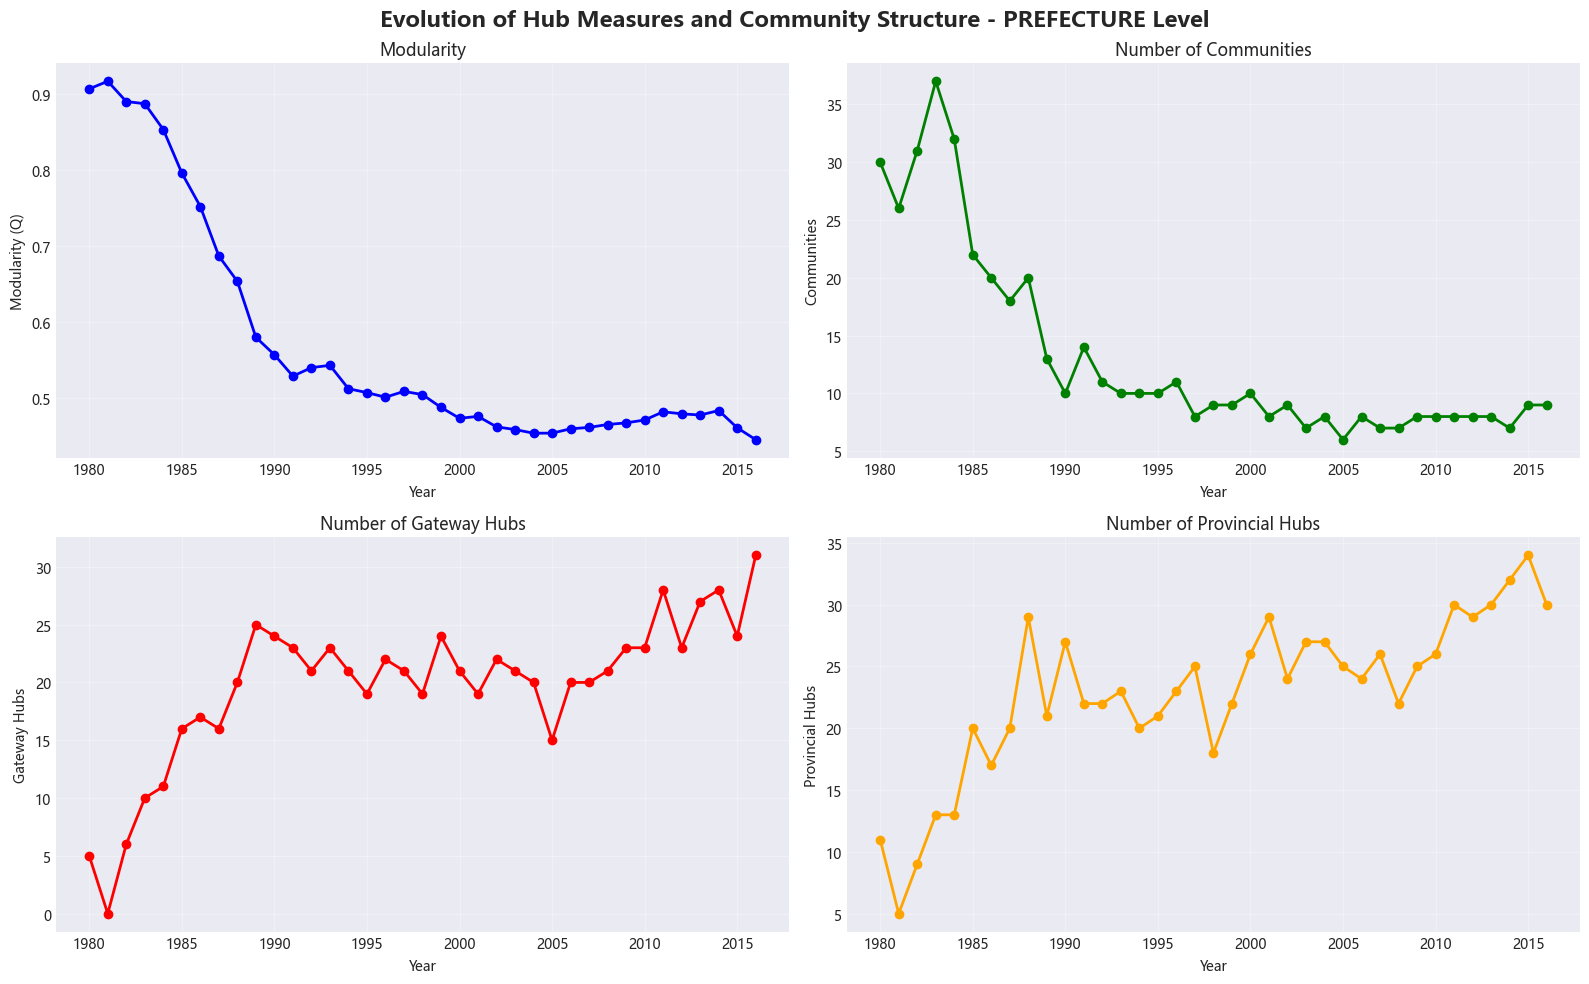

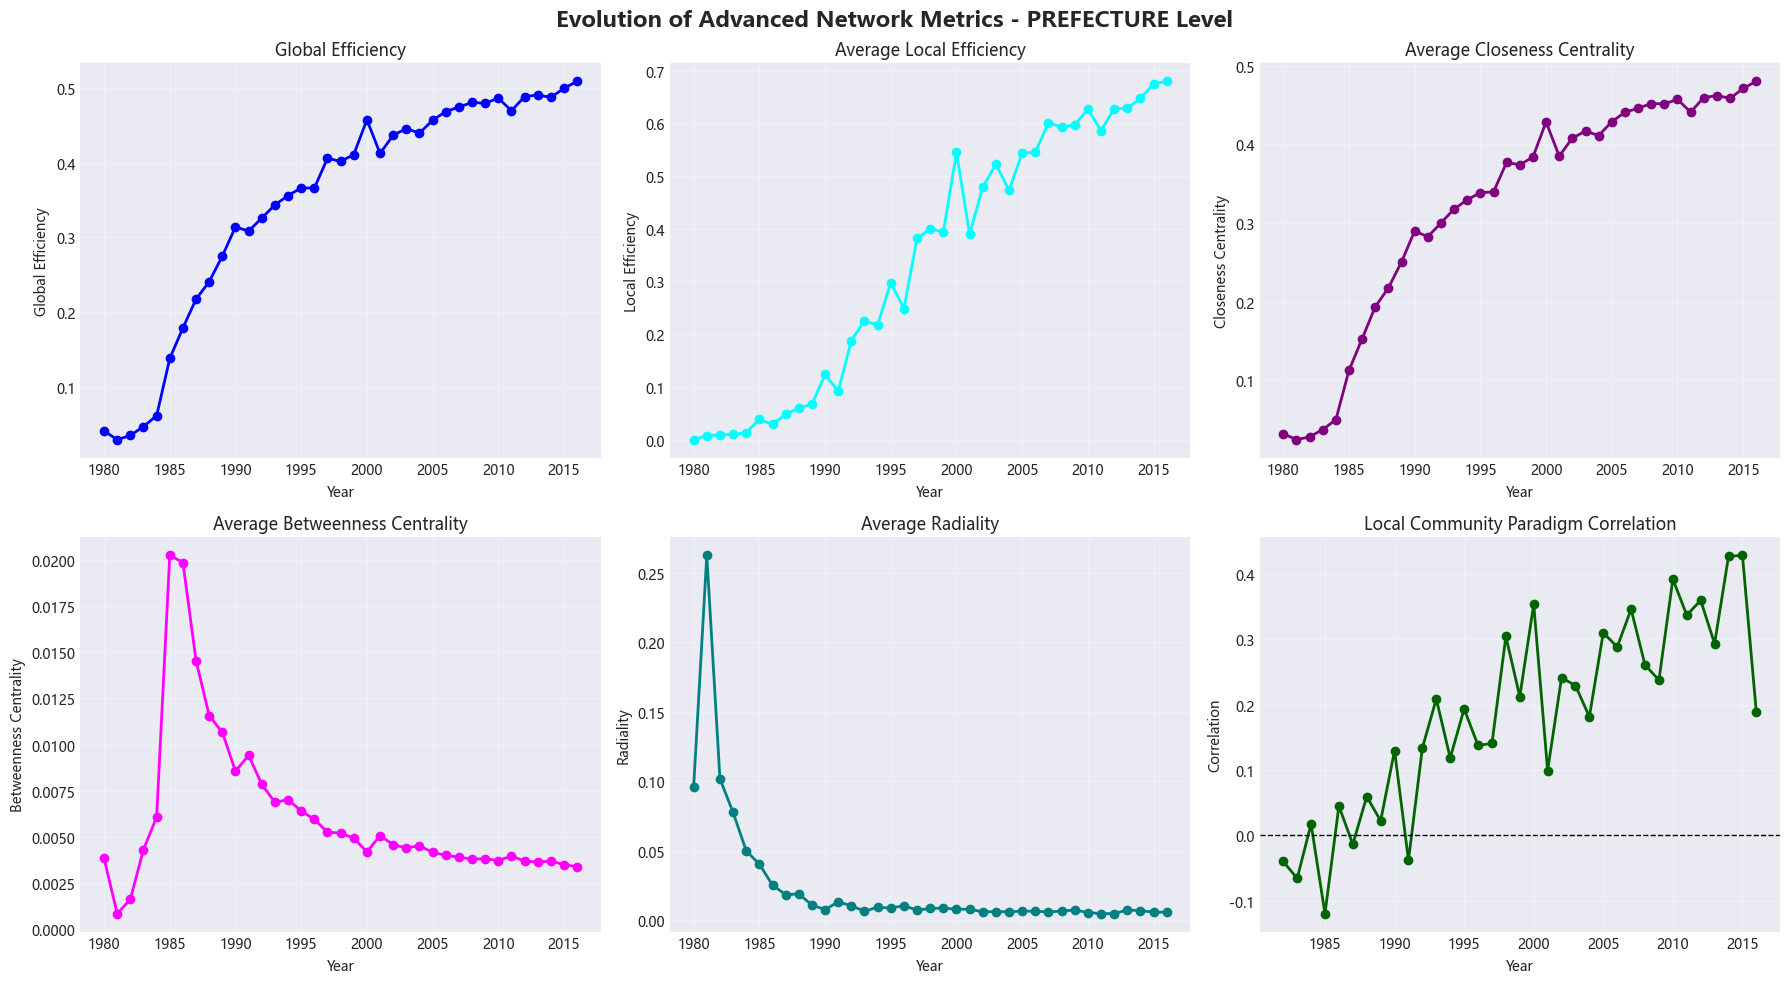

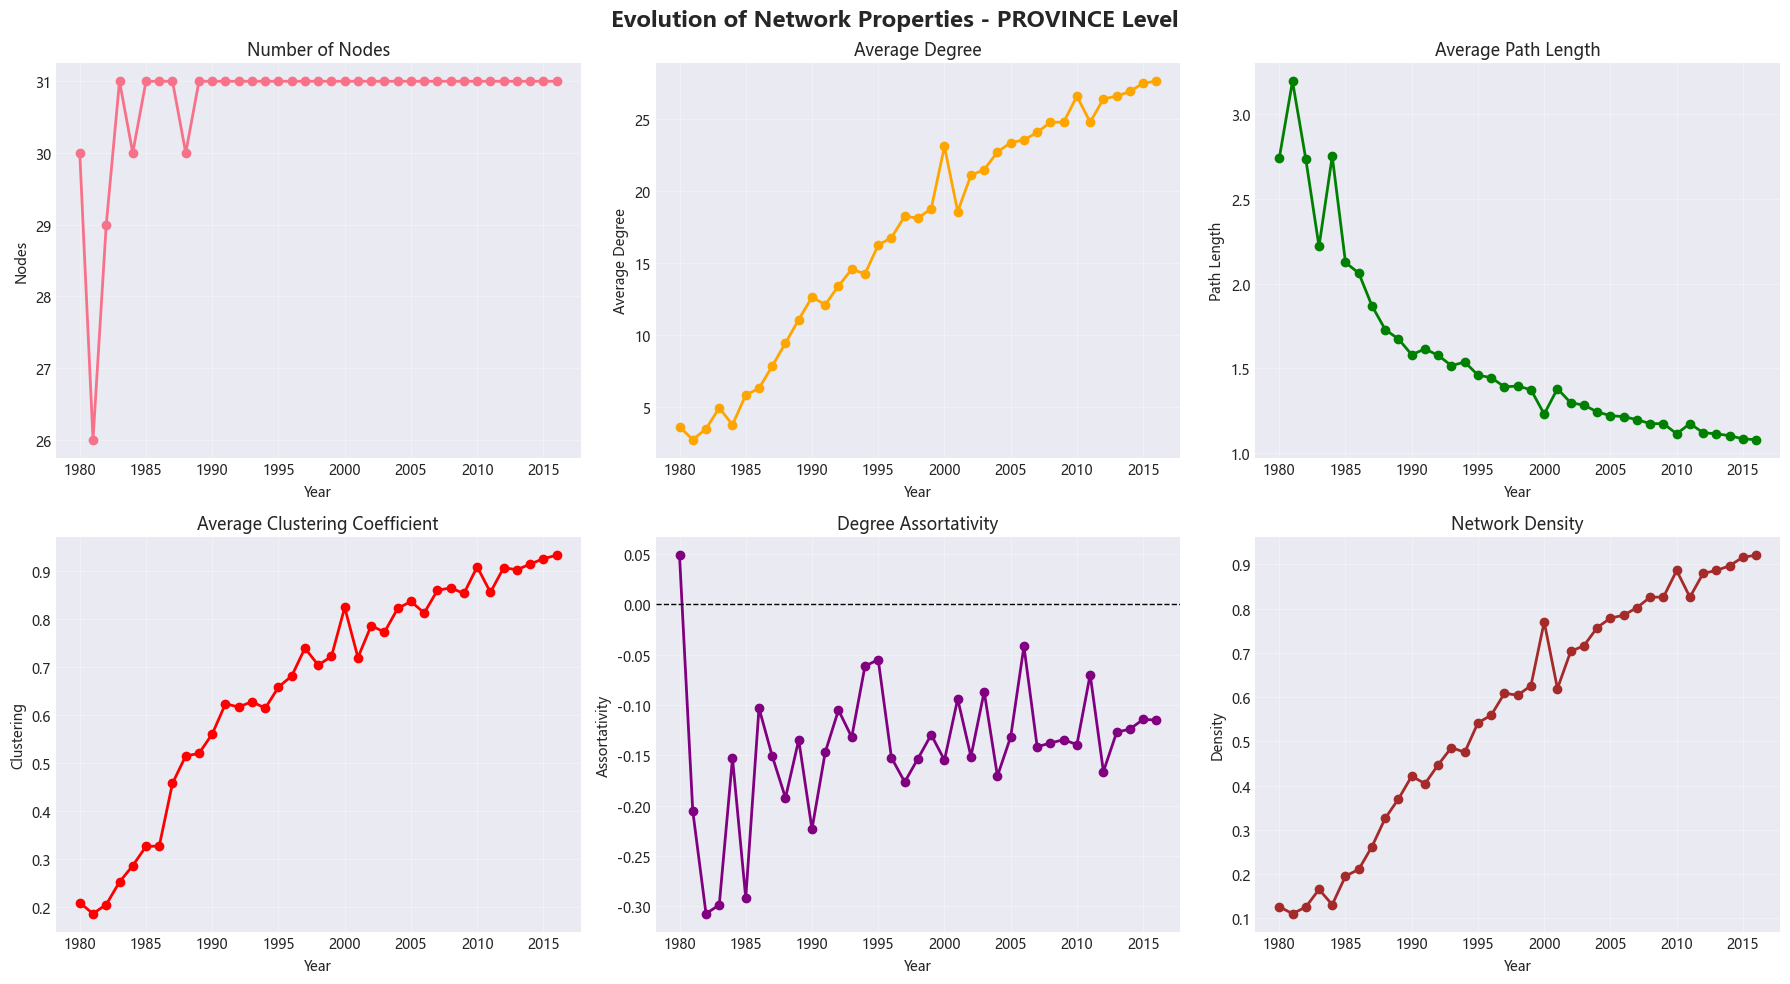

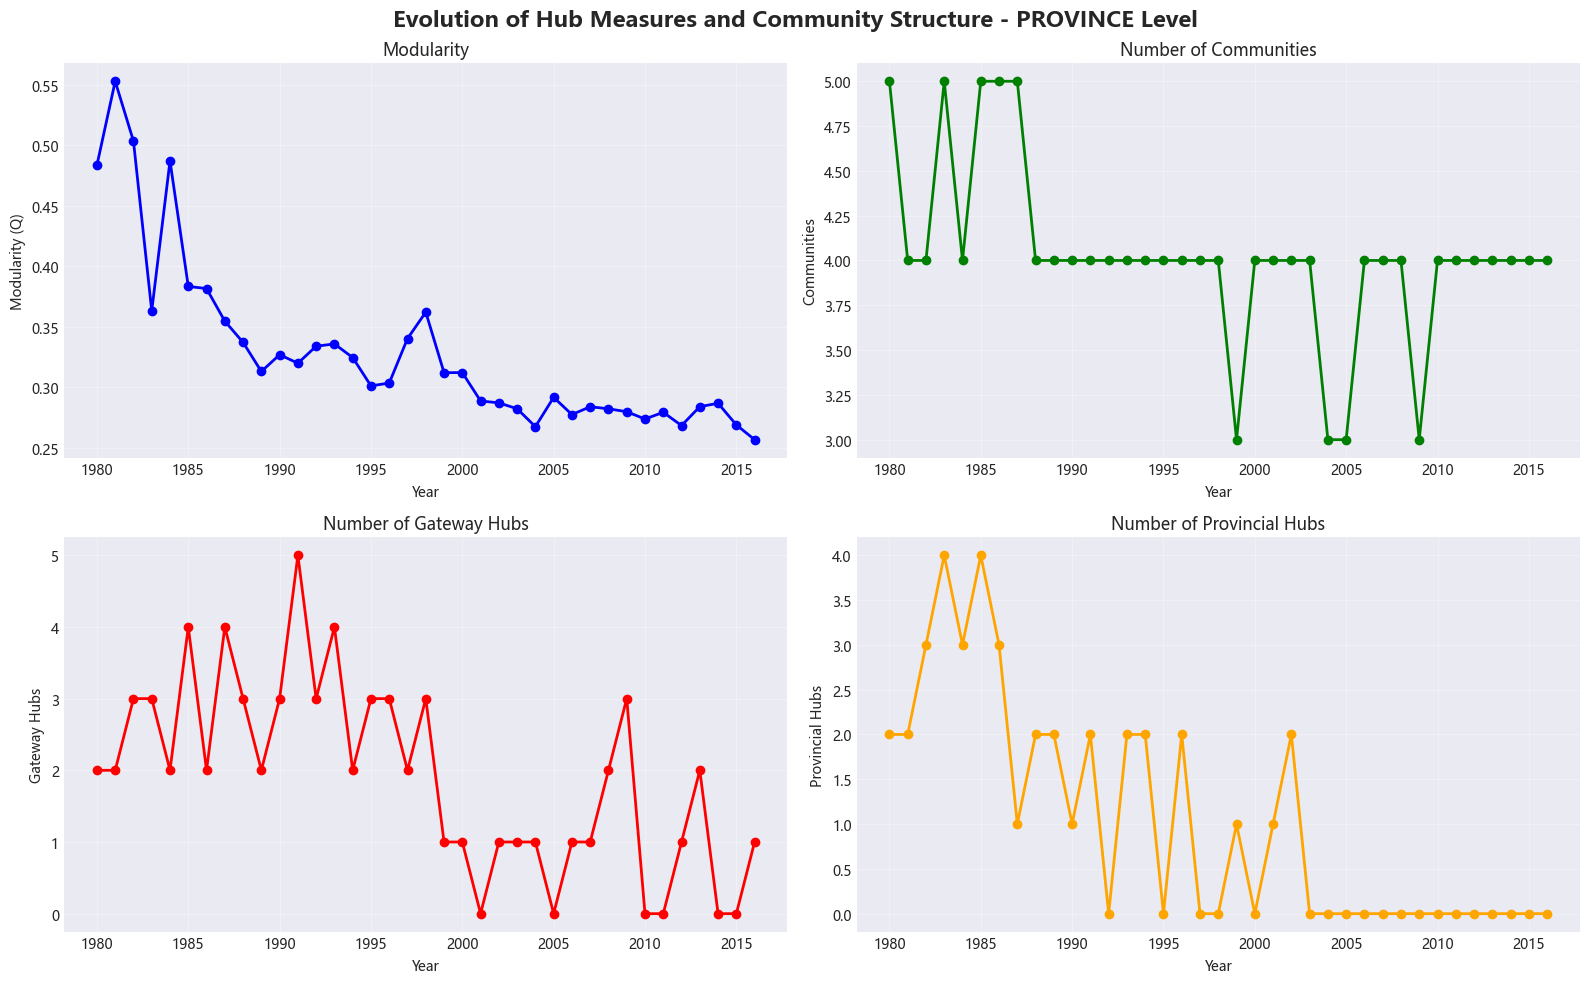

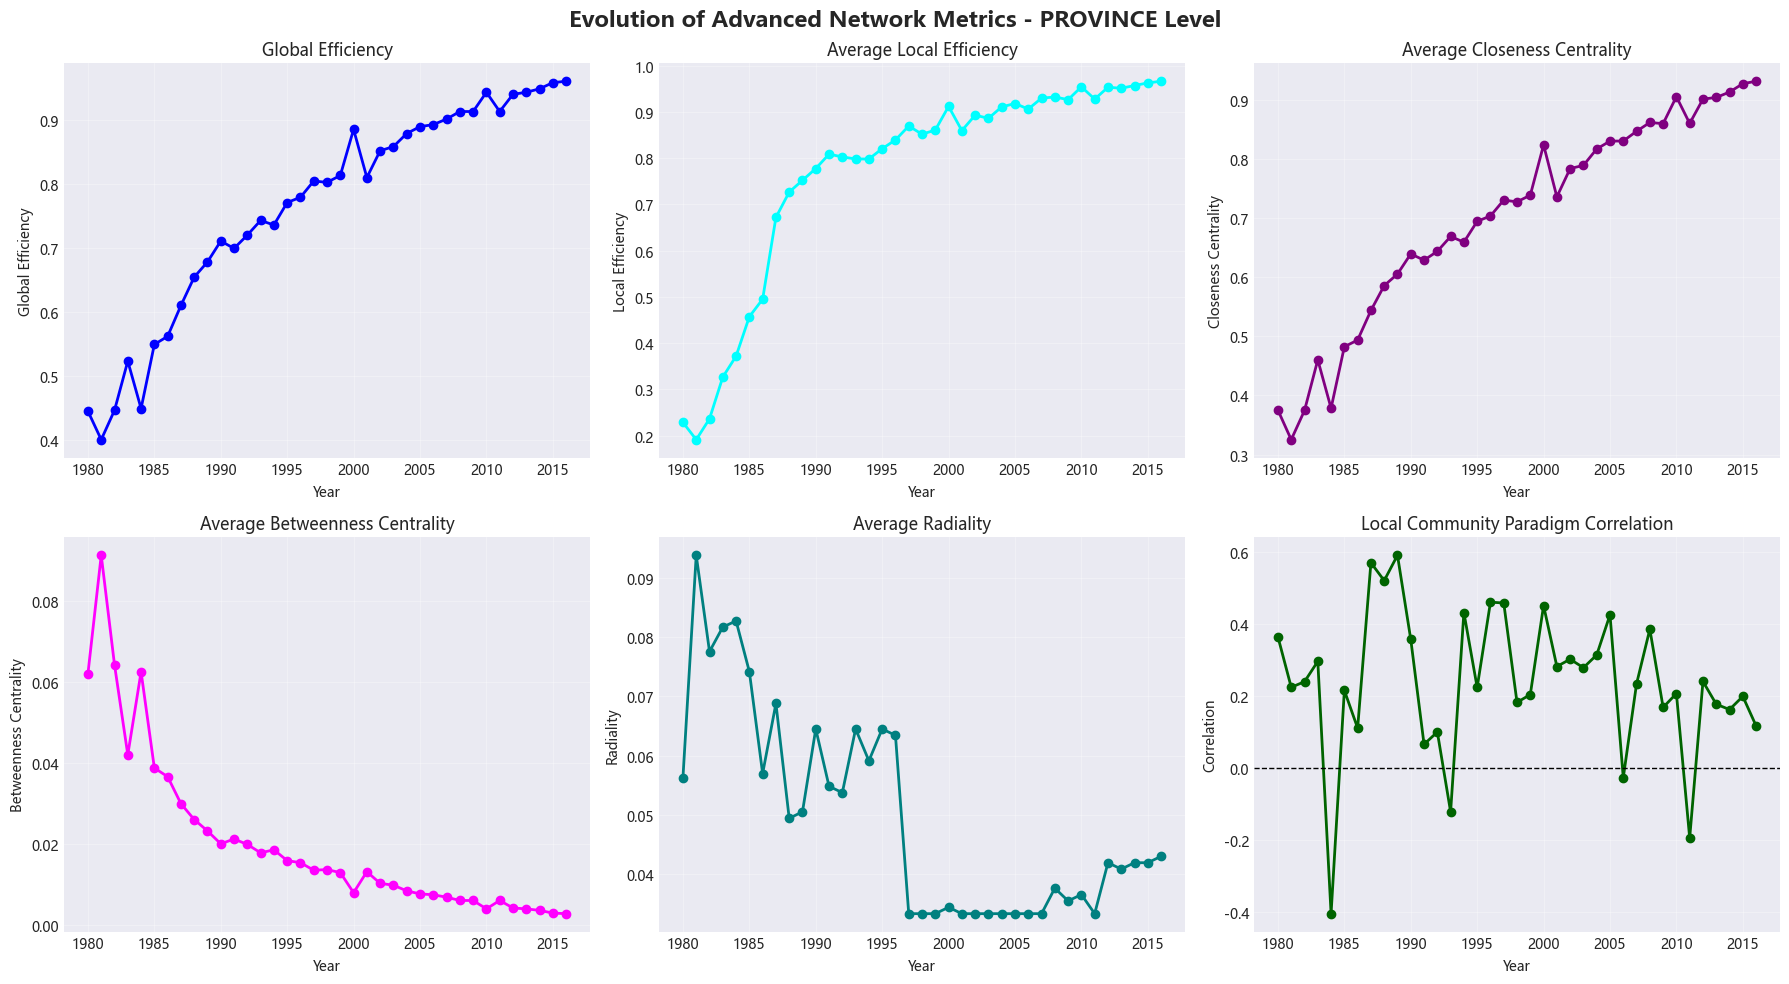

In [16]:
# ============================================================================
# TEMPORAL EVOLUTION ANALYSIS
# ============================================================================

if 'year' in metrics_df.columns:
    # Filter for yearly data (exclude 'all' years aggregate)
    yearly_df = metrics_df[metrics_df['years'] != 'all'].copy()
    
    if not yearly_df.empty:
        print("\n" + "="*80)
        print("TEMPORAL EVOLUTION ANALYSIS")
        print("="*80)
        
        for granularity in granularities:
            gran_df = yearly_df[yearly_df['granularity'] == granularity].copy()
            
            if not gran_df.empty and 'year' in gran_df.columns:
                # Convert year to numeric and sort
                gran_df['year'] = pd.to_numeric(gran_df['year'], errors='coerce')
                gran_df = gran_df.dropna(subset=['year'])
                gran_df = gran_df.sort_values('year')
                
                # Set year as index for easier plotting
                gran_df_indexed = gran_df.set_index('year')
                
                # ============================================================
                # FIGURE 1: Basic Network Properties
                # ============================================================
                fig, axes = plt.subplots(2, 3, figsize=(18, 10))
                fig.suptitle(f'Evolution of Network Properties - {granularity.upper()} Level', 
                             fontsize=16, fontweight='bold')
                
                # Number of nodes
                ax = axes[0, 0]
                gran_df_indexed['n_nodes'].plot(ax=ax, marker='o', linewidth=2)
                ax.set_title('Number of Nodes')
                ax.set_xlabel('Year')
                ax.set_ylabel('Nodes')
                ax.grid(alpha=0.3)
                
                # Average degree
                ax = axes[0, 1]
                gran_df_indexed['avg_degree'].plot(ax=ax, marker='o', linewidth=2, color='orange')
                ax.set_title('Average Degree')
                ax.set_xlabel('Year')
                ax.set_ylabel('Average Degree')
                ax.grid(alpha=0.3)
                
                # Average path length
                ax = axes[0, 2]
                gran_df_indexed['avg_path_length'].plot(ax=ax, marker='o', linewidth=2, color='green')
                ax.set_title('Average Path Length')
                ax.set_xlabel('Year')
                ax.set_ylabel('Path Length')
                ax.grid(alpha=0.3)
                
                # Average clustering
                ax = axes[1, 0]
                gran_df_indexed['avg_clustering'].plot(ax=ax, marker='o', linewidth=2, color='red')
                ax.set_title('Average Clustering Coefficient')
                ax.set_xlabel('Year')
                ax.set_ylabel('Clustering')
                ax.grid(alpha=0.3)
                
                # Assortativity
                ax = axes[1, 1]
                gran_df_indexed['assortativity'].plot(ax=ax, marker='o', linewidth=2, color='purple')
                ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
                ax.set_title('Degree Assortativity')
                ax.set_xlabel('Year')
                ax.set_ylabel('Assortativity')
                ax.grid(alpha=0.3)
                
                # Network density
                ax = axes[1, 2]
                gran_df_indexed['density'].plot(ax=ax, marker='o', linewidth=2, color='brown')
                ax.set_title('Network Density')
                ax.set_xlabel('Year')
                ax.set_ylabel('Density')
                ax.grid(alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                # ============================================================
                # FIGURE 2: Hub Measures and Community Structure
                # ============================================================
                fig, axes = plt.subplots(2, 2, figsize=(16, 10))
                fig.suptitle(f'Evolution of Hub Measures and Community Structure - {granularity.upper()} Level', 
                             fontsize=16, fontweight='bold')
                
                # Modularity
                ax = axes[0, 0]
                gran_df_indexed['modularity'].plot(ax=ax, marker='o', linewidth=2, color='blue')
                ax.set_title('Modularity')
                ax.set_xlabel('Year')
                ax.set_ylabel('Modularity (Q)')
                ax.grid(alpha=0.3)
                
                # Number of communities
                ax = axes[0, 1]
                gran_df_indexed['n_communities'].plot(ax=ax, marker='o', linewidth=2, color='green')
                ax.set_title('Number of Communities')
                ax.set_xlabel('Year')
                ax.set_ylabel('Communities')
                ax.grid(alpha=0.3)
                
                # Gateway hubs
                ax = axes[1, 0]
                gran_df_indexed['n_gateway_hubs'].plot(ax=ax, marker='o', linewidth=2, color='red')
                ax.set_title('Number of Gateway Hubs')
                ax.set_xlabel('Year')
                ax.set_ylabel('Gateway Hubs')
                ax.grid(alpha=0.3)
                
                # Provincial hubs
                ax = axes[1, 1]
                gran_df_indexed['n_provincial_hubs'].plot(ax=ax, marker='o', linewidth=2, color='orange')
                ax.set_title('Number of Provincial Hubs')
                ax.set_xlabel('Year')
                ax.set_ylabel('Provincial Hubs')
                ax.grid(alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                # ============================================================
                # FIGURE 3: Advanced Network Metrics (NEW)
                # ============================================================
                fig, axes = plt.subplots(2, 3, figsize=(18, 10))
                fig.suptitle(f'Evolution of Advanced Network Metrics - {granularity.upper()} Level', 
                             fontsize=16, fontweight='bold')
                
                # Global Efficiency
                ax = axes[0, 0]
                gran_df_indexed['global_efficiency'].plot(ax=ax, marker='o', linewidth=2, color='blue')
                ax.set_title('Global Efficiency')
                ax.set_xlabel('Year')
                ax.set_ylabel('Global Efficiency')
                ax.grid(alpha=0.3)
                
                # Local Efficiency
                ax = axes[0, 1]
                gran_df_indexed['avg_local_efficiency'].plot(ax=ax, marker='o', linewidth=2, color='cyan')
                ax.set_title('Average Local Efficiency')
                ax.set_xlabel('Year')
                ax.set_ylabel('Local Efficiency')
                ax.grid(alpha=0.3)
                
                # Closeness Centrality
                ax = axes[0, 2]
                gran_df_indexed['avg_closeness_centrality'].plot(ax=ax, marker='o', linewidth=2, color='purple')
                ax.set_title('Average Closeness Centrality')
                ax.set_xlabel('Year')
                ax.set_ylabel('Closeness Centrality')
                ax.grid(alpha=0.3)
                
                # Betweenness Centrality
                ax = axes[1, 0]
                gran_df_indexed['avg_betweenness_centrality'].plot(ax=ax, marker='o', linewidth=2, color='magenta')
                ax.set_title('Average Betweenness Centrality')
                ax.set_xlabel('Year')
                ax.set_ylabel('Betweenness Centrality')
                ax.grid(alpha=0.3)
                
                # Radiality
                ax = axes[1, 1]
                gran_df_indexed['avg_radiality'].plot(ax=ax, marker='o', linewidth=2, color='teal')
                ax.set_title('Average Radiality')
                ax.set_xlabel('Year')
                ax.set_ylabel('Radiality')
                ax.grid(alpha=0.3)
                
                # Local Community Paradigm Correlation
                ax = axes[1, 2]
                gran_df_indexed['local_community_paradigm_corr'].plot(ax=ax, marker='o', linewidth=2, color='darkgreen')
                ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
                ax.set_title('Local Community Paradigm Correlation')
                ax.set_xlabel('Year')
                ax.set_ylabel('Correlation')
                ax.grid(alpha=0.3)
                
                plt.tight_layout()
                plt.show()


## Detailed Hub Analysis: Global and Temporal

Now let's analyze the top 10 hub cities in detail, both for the global network (all years combined) and for temporal evolution (each year).

In [81]:
# ============================================================================
# PART 1: GLOBAL HUB ANALYSIS (ALL YEARS COMBINED)
# ============================================================================

print("\n" + "="*80)
print("GLOBAL HUB ANALYSIS - PREFECTURE LEVEL (ALL YEARS COMBINED)")
print("="*80)

# Use pre-generated global graph for prefecture level
G_global = graphs['prefecture']['all']

print(f"\nGlobal network: {G_global.number_of_nodes()} nodes, {G_global.number_of_edges()} edges")

# Detect communities
print("\nDetecting communities in global network...")
partition_global, modularity_global = detect_communities(G_global)
n_communities = len(set(partition_global.values()))
print(f"Number of communities: {n_communities}")
print(f"Modularity Q: {modularity_global:.3f}")

# Compute hub measures
print("\nComputing hub measures for global network...")
hub_measures_global = compute_hub_measures(G_global, partition_global)

# Print top 10 cities by each measure
print("\n" + "="*80)
print("=== Top 10 Cities by Gateway-ness (B) - GLOBAL ===")
print("="*80)
top_B_global = sorted(hub_measures_global.items(), key=lambda x: x[1]['B'], reverse=True)[:10]
for i, (city, measures) in enumerate(top_B_global, 1):
    city_name = get_city_name(city)
    print(f"{i:2d}. {city_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

print("\n" + "="*80)
print("=== Top 10 Cities by Provincial-ness (Z) - GLOBAL ===")
print("="*80)
top_Z_global = sorted(hub_measures_global.items(), key=lambda x: x[1]['Z'], reverse=True)[:10]
for i, (city, measures) in enumerate(top_Z_global, 1):
    city_name = get_city_name(city)
    print(f"{i:2d}. {city_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

print("\n" + "="*80)
print("=== Top 10 Cities by Connector-ness (P) - GLOBAL ===")
print("="*80)
top_P_global = sorted(hub_measures_global.items(), key=lambda x: x[1]['P'], reverse=True)[:10]
for i, (city, measures) in enumerate(top_P_global, 1):
    city_name = get_city_name(city)
    print(f"{i:2d}. {city_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

# Classify hubs in global network
classification_global = classify_hubs(hub_measures_global)
print("\n" + "="*80)
print("Global Hub Classification:")
print(f"  Gateway hubs (B ≥ 1.5): {len(classification_global['gateway'])}")
print(f"  Provincial hubs (Z ≥ 1.5): {len(classification_global['provincial'])}")
print(f"  Connector hubs (P ≥ 0.7): {len(classification_global['connector'])}")
print("="*80)


GLOBAL HUB ANALYSIS - PREFECTURE LEVEL (ALL YEARS COMBINED)

Global network: 331 nodes, 16518 edges

Detecting communities in global network...
Number of communities: 7
Modularity Q: 0.461

Computing hub measures for global network...

=== Top 10 Cities by Gateway-ness (B) - GLOBAL ===
 1. 深圳市                      : B=  3.67, Z=  2.36, P=  0.83
 2. 北京市                      : B=  3.48, Z=  2.10, P=  0.85
 3. 沈阳市                      : B=  3.37, Z=  1.87, P=  0.84
 4. 广州市                      : B=  3.33, Z=  2.36, P=  0.83
 5. 重庆市                      : B=  3.30, Z=  2.38, P=  0.83
 6. 太原市                      : B=  3.22, Z=  1.35, P=  0.84
 7. 西安市                      : B=  2.99, Z=  1.50, P=  0.84
 8. 天津市                      : B=  2.96, Z=  1.87, P=  0.85
 9. 上海市                      : B=  2.81, Z=  1.50, P=  0.84
10. 兰州市                      : B=  2.56, Z=  1.90, P=  0.84

=== Top 10 Cities by Provincial-ness (Z) - GLOBAL ===
 1. 重庆市                      : B=  3.30, Z=  2.38, P=  0.

In [82]:
# ============================================================================
# PART 2: TEMPORAL HUB ANALYSIS (YEAR BY YEAR)
# ============================================================================

print("\n" + "="*80)
print("TEMPORAL HUB ANALYSIS - YEAR BY YEAR")
print("="*80)

# Define years to analyze
years_to_analyze = list(range(1980, 2017))

# Compute hub measures for all years using pre-generated graphs
yearly_hub_measures = {}
yearly_modularity = {}
yearly_top10_B = {}
yearly_top10_Z = {}
yearly_top10_P = {}
yearly_hub_classification = {}

print("\nComputing hub measures for each year using pre-generated graphs...")
for year in tqdm(years_to_analyze):
    # Use pre-generated graph
    G = graphs['prefecture'][year]
    
    if G.number_of_nodes() > 10:
        partition, modularity = detect_communities(G)
        hub_measures = compute_hub_measures(G, partition)
        
        yearly_hub_measures[year] = hub_measures
        yearly_modularity[year] = modularity
        
        # Get top 10 for each measure
        top_B = sorted(hub_measures.items(), key=lambda x: x[1]['B'], reverse=True)[:10]
        top_Z = sorted(hub_measures.items(), key=lambda x: x[1]['Z'], reverse=True)[:10]
        top_P = sorted(hub_measures.items(), key=lambda x: x[1]['P'], reverse=True)[:10]
        
        yearly_top10_B[year] = top_B
        yearly_top10_Z[year] = top_Z
        yearly_top10_P[year] = top_P
        
        # Classify hubs
        classification = classify_hubs(hub_measures)
        yearly_hub_classification[year] = classification
        
        n_communities = len(set(partition.values()))

print("\n✓ Computed hub measures for all years!")

# Print top 10 for selected years
selected_years = [2000, 2005, 2010, 2015, 2016]

for year in selected_years:
    if year in yearly_top10_B:
        print("\n" + "="*80)
        print(f"YEAR {year}")
        print("="*80)
        
        print("\n--- Top 10 Cities by Gateway-ness (B) ---")
        for i, (city, measures) in enumerate(yearly_top10_B[year], 1):
            city_name = get_city_name(city)
            print(f"{i:2d}. {city_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")
        
        print("\n--- Top 10 Cities by Provincial-ness (Z) ---")
        for i, (city, measures) in enumerate(yearly_top10_Z[year], 1):
            city_name = get_city_name(city)
            print(f"{i:2d}. {city_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")
        
        print("\n--- Top 10 Cities by Connector-ness (P) ---")
        for i, (city, measures) in enumerate(yearly_top10_P[year], 1):
            city_name = get_city_name(city)
            print(f"{i:2d}. {city_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")


TEMPORAL HUB ANALYSIS - YEAR BY YEAR

Computing hub measures for each year using pre-generated graphs...


100%|██████████| 37/37 [00:04<00:00,  8.45it/s]


✓ Computed hub measures for all years!

YEAR 2000

--- Top 10 Cities by Gateway-ness (B) ---
 1. 北京市                      : B=  6.19, Z=  4.87, P=  0.84
 2. 深圳市                      : B=  5.71, Z=  5.37, P=  0.76
 3. 上海市                      : B=  4.64, Z=  3.52, P=  0.82
 4. 西安市                      : B=  4.49, Z=  2.79, P=  0.84
 5. 重庆市                      : B=  3.94, Z=  2.08, P=  0.85
 6. 广州市                      : B=  3.90, Z=  4.58, P=  0.72
 7. 兰州市                      : B=  3.72, Z=  3.12, P=  0.84
 8. 金华市                      : B=  3.26, Z=  0.86, P=  0.77
 9. 大连市                      : B=  2.88, Z=  2.83, P=  0.62
10. 温州市                      : B=  2.52, Z=  0.92, P=  0.83

--- Top 10 Cities by Provincial-ness (Z) ---
 1. 深圳市                      : B=  5.71, Z=  5.37, P=  0.76
 2. 北京市                      : B=  6.19, Z=  4.87, P=  0.84
 3. 广州市                      : B=  3.90, Z=  4.58, P=  0.72
 4. 上海市                      : B=  4.64, Z=  3.52, P=  0.82
 5. 天津市             


GENERATING VISUALIZATIONS

Major cities (appear in ≥15 years): 330

Tracking top 10 cities by average Gateway-ness:
   1. 北京市                      : Average B = 5.06
   2. 上海市                      : Average B = 4.41
   3. 深圳市                      : Average B = 4.26
   4. 广州市                      : Average B = 3.45
   5. 重庆市                      : Average B = 3.31
   6. 西安市                      : Average B = 2.85
   7. 温州市                      : Average B = 2.52
   8. 天津市                      : Average B = 2.40
   9. 泉州市                      : Average B = 2.01
  10. 乌鲁木齐市                    : Average B = 1.98


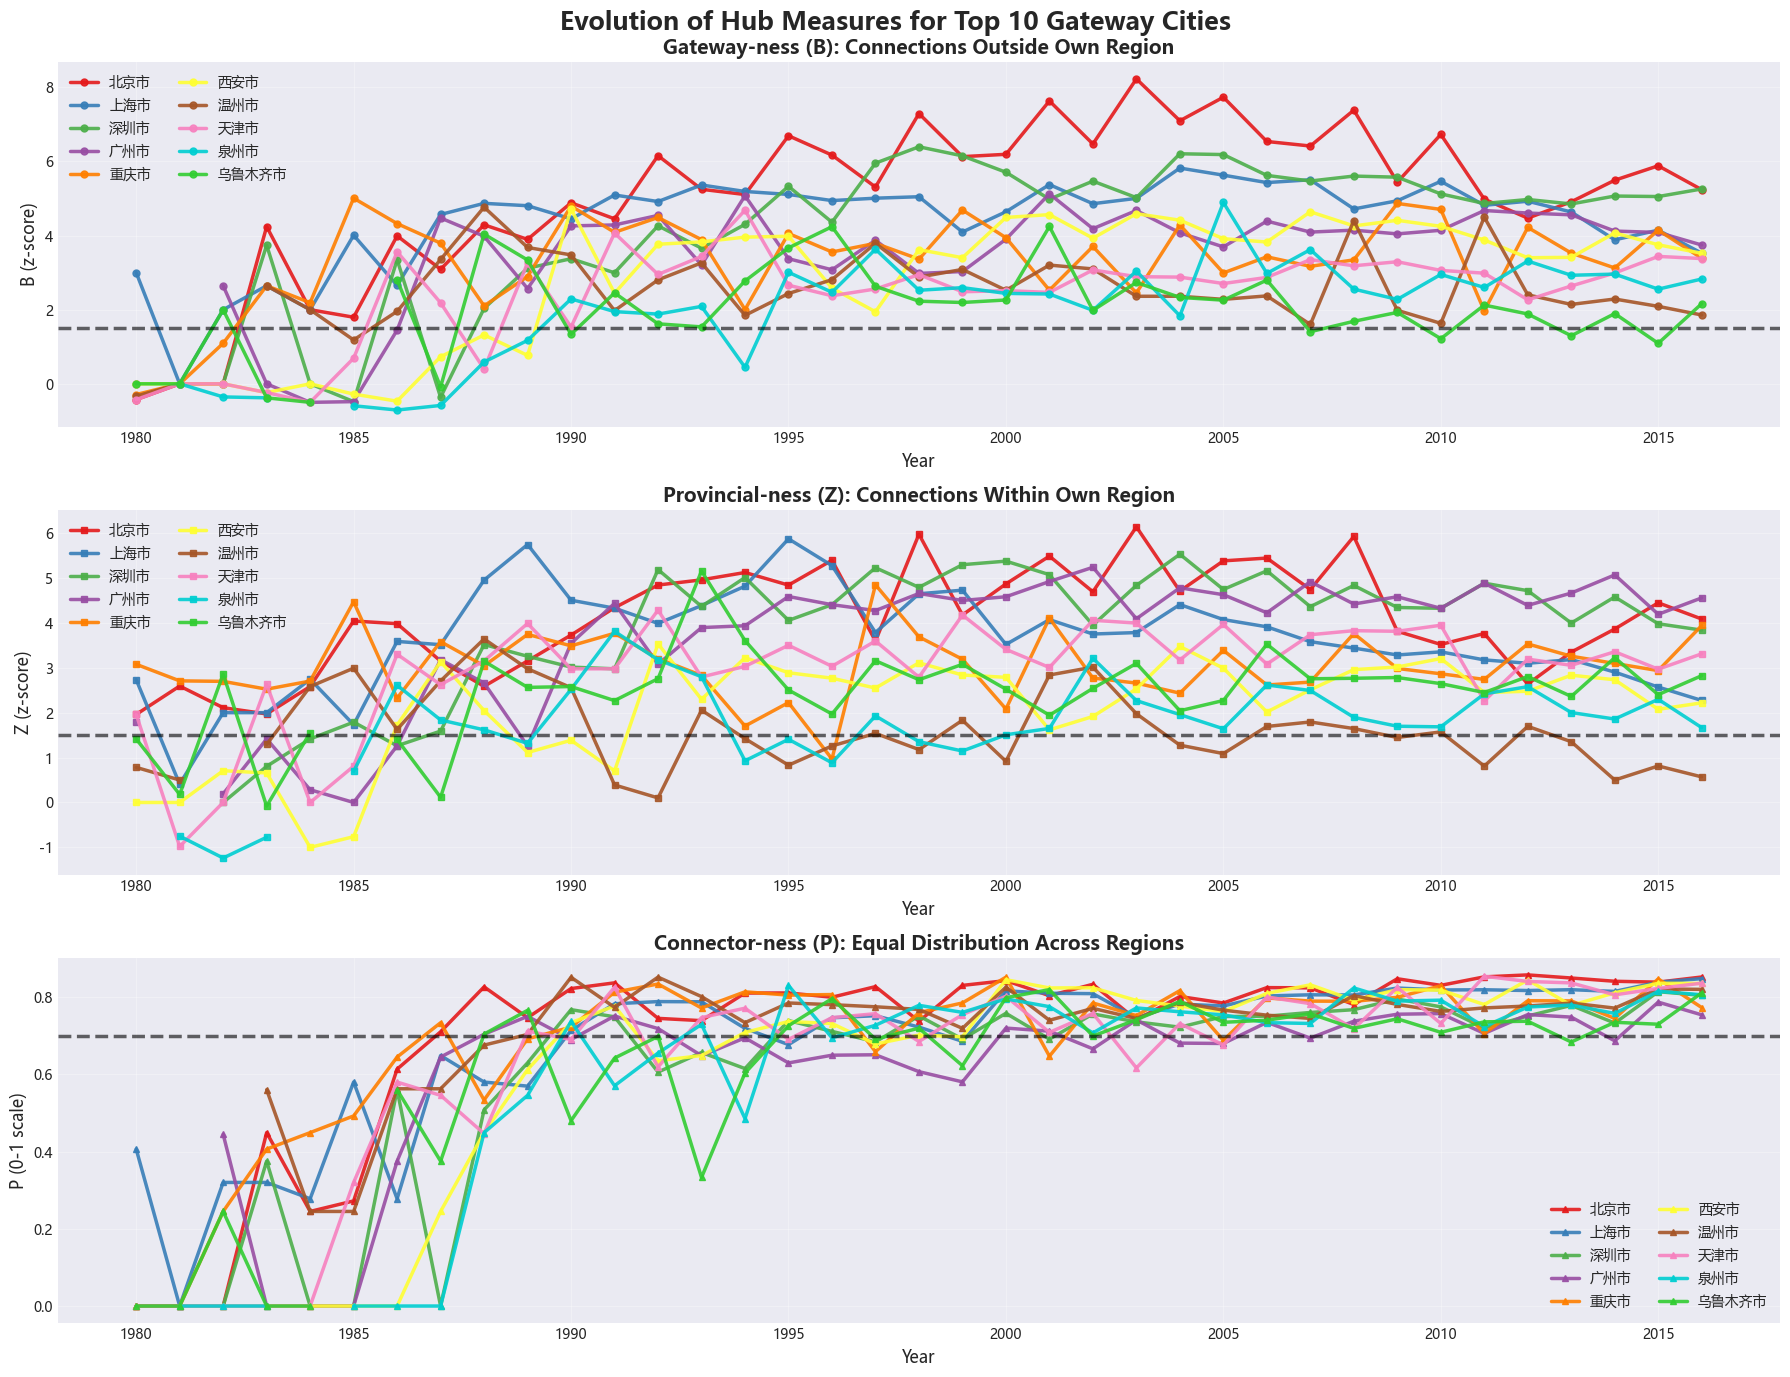

In [83]:
# ============================================================================
# PART 3: VISUALIZATION - EVOLUTION OF TOP CITIES
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Select major cities that appear frequently
city_counts = defaultdict(int)
city_avg_B = defaultdict(list)

for year, measures in yearly_hub_measures.items():
    for city, vals in measures.items():
        city_counts[city] += 1
        city_avg_B[city].append(vals['B'])

# Get cities that appear in at least 15 years
major_cities = [city for city, count in city_counts.items() if count >= 15]
print(f"\nMajor cities (appear in ≥15 years): {len(major_cities)}")

# Calculate average B for each major city
city_avg_B_score = {city: np.mean(city_avg_B[city]) for city in major_cities}
top_cities = sorted(city_avg_B_score.items(), key=lambda x: x[1], reverse=True)[:10]
cities_to_track = [city for city, _ in top_cities]

print(f"\nTracking top 10 cities by average Gateway-ness:")
for i, (city, avg_b) in enumerate(top_cities, 1):
    city_name = get_city_name(city)
    print(f"  {i:2d}. {city_name:25s}: Average B = {avg_b:.2f}")

# Extract time series for each measure
city_B_series = {city: [] for city in cities_to_track}
city_Z_series = {city: [] for city in cities_to_track}
city_P_series = {city: [] for city in cities_to_track}
years_available = []

for year in sorted(yearly_hub_measures.keys()):
    measures = yearly_hub_measures[year]
    years_available.append(year)
    
    for city in cities_to_track:
        if city in measures:
            city_B_series[city].append(measures[city]['B'])
            city_Z_series[city].append(measures[city]['Z'])
            city_P_series[city].append(measures[city]['P'])
        else:
            city_B_series[city].append(np.nan)
            city_Z_series[city].append(np.nan)
            city_P_series[city].append(np.nan)

# Define a custom color palette with 10 distinct, easily distinguishable colors
distinct_colors = [
    '#e41a1c',  # Red
    '#377eb8',  # Blue
    '#4daf4a',  # Green
    '#984ea3',  # Purple
    '#ff7f00',  # Orange
    '#ffff33',  # Yellow
    '#a65628',  # Brown
    '#f781bf',  # Pink
    '#00CED1',  # Dark Turquoise
    '#32CD32',  # Lime Green
]

# Plot evolution with enhanced styling
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('Evolution of Hub Measures for Top 10 Gateway Cities', fontsize=18, fontweight='bold')

# Gateway-ness
ax = axes[0]
for i, city in enumerate(cities_to_track):
    city_name = get_city_name(city)
    ax.plot(years_available, city_B_series[city], marker='o', label=city_name,
            linewidth=2.5, markersize=5, alpha=0.9, color=distinct_colors[i])
ax.set_title('Gateway-ness (B): Connections Outside Own Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('B (z-score)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=1.5, color='black', linestyle='--', alpha=0.6, linewidth=2.5, label='Gateway hub threshold')

# Provincial-ness
ax = axes[1]
for i, city in enumerate(cities_to_track):
    city_name = get_city_name(city)
    ax.plot(years_available, city_Z_series[city], marker='s', label=city_name,
            linewidth=2.5, markersize=5, alpha=0.9, color=distinct_colors[i])
ax.set_title('Provincial-ness (Z): Connections Within Own Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Z (z-score)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=1.5, color='black', linestyle='--', alpha=0.6, linewidth=2.5, label='Provincial hub threshold')

# Connector-ness
ax = axes[2]
for i, city in enumerate(cities_to_track):
    city_name = get_city_name(city)
    ax.plot(years_available, city_P_series[city], marker='^', label=city_name,
            linewidth=2.5, markersize=5, alpha=0.9, color=distinct_colors[i])
ax.set_title('Connector-ness (P): Equal Distribution Across Regions', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('P (0-1 scale)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=0.7, color='black', linestyle='--', alpha=0.6, linewidth=2.5, label='Connector hub threshold')

plt.tight_layout()
plt.show()

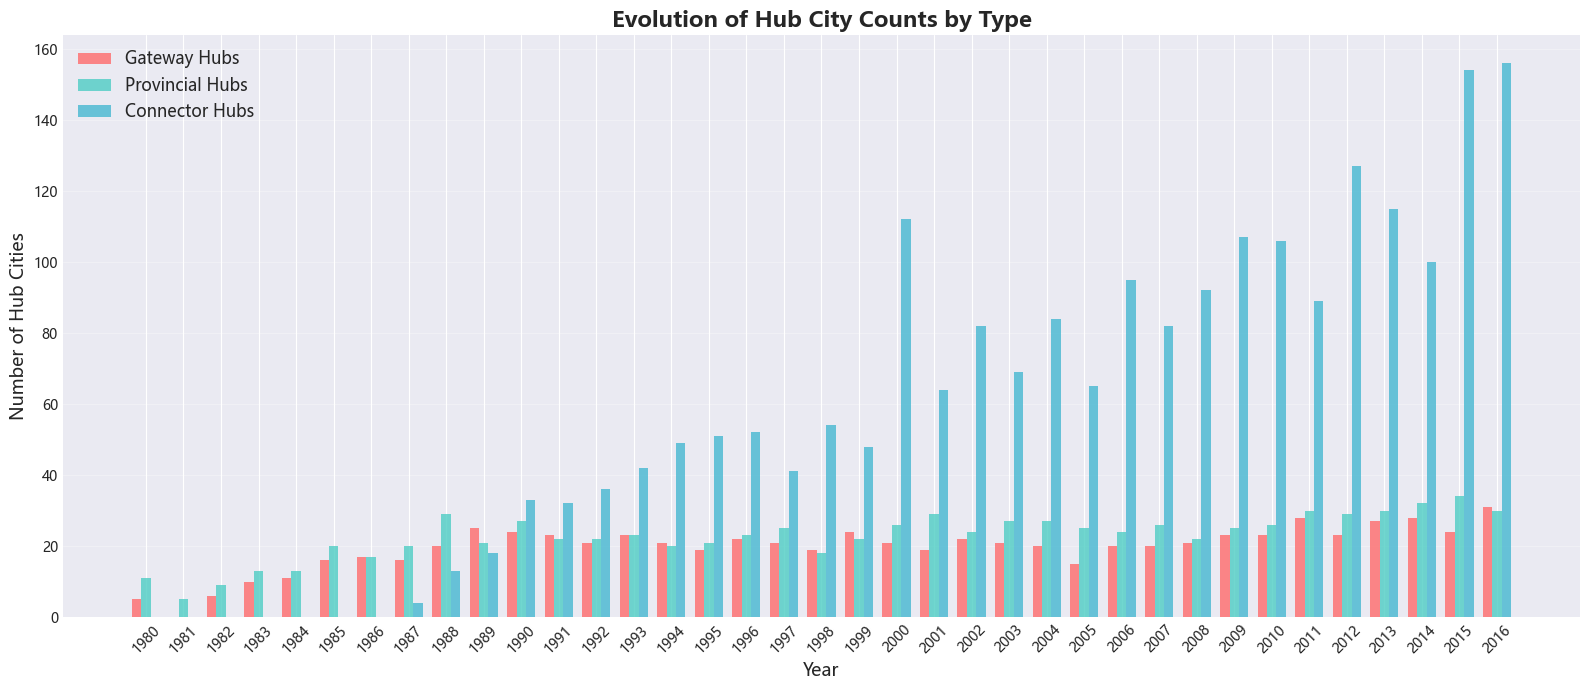


HUB COUNTS SUMMARY

Gateway Hubs:
  Min: 0, Max: 31, Avg: 19.7

Provincial Hubs:
  Min: 5, Max: 34, Avg: 22.9

Connector Hubs:
  Min: 0, Max: 156, Avg: 58.7


In [84]:
# ============================================================================
# PART 4: HUB COUNTS EVOLUTION BAR CHART
# ============================================================================

# Plot evolution of hub counts
hub_counts_data = {
    'Gateway': [],
    'Provincial': [],
    'Connector': []
}

years_list = sorted(yearly_hub_classification.keys())
for year in years_list:
    classification = yearly_hub_classification[year]
    hub_counts_data['Gateway'].append(len(classification['gateway']))
    hub_counts_data['Provincial'].append(len(classification['provincial']))
    hub_counts_data['Connector'].append(len(classification['connector']))

fig, ax = plt.subplots(figsize=(16, 7))
width = 0.25
x = np.arange(len(years_list))

ax.bar(x - width, hub_counts_data['Gateway'], width, label='Gateway Hubs', alpha=0.8, color='#FF6B6B')
ax.bar(x, hub_counts_data['Provincial'], width, label='Provincial Hubs', alpha=0.8, color='#4ECDC4')
ax.bar(x + width, hub_counts_data['Connector'], width, label='Connector Hubs', alpha=0.8, color='#45B7D1')

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Number of Hub Cities', fontsize=13)
ax.set_title('Evolution of Hub City Counts by Type', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(years_list, rotation=45)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("HUB COUNTS SUMMARY")
print("="*80)
print(f"\nGateway Hubs:")
print(f"  Min: {min(hub_counts_data['Gateway'])}, Max: {max(hub_counts_data['Gateway'])}, Avg: {np.mean(hub_counts_data['Gateway']):.1f}")
print(f"\nProvincial Hubs:")
print(f"  Min: {min(hub_counts_data['Provincial'])}, Max: {max(hub_counts_data['Provincial'])}, Avg: {np.mean(hub_counts_data['Provincial']):.1f}")
print(f"\nConnector Hubs:")
print(f"  Min: {min(hub_counts_data['Connector'])}, Max: {max(hub_counts_data['Connector'])}, Avg: {np.mean(hub_counts_data['Connector']):.1f}")


Generating heatmaps for temporal evolution...


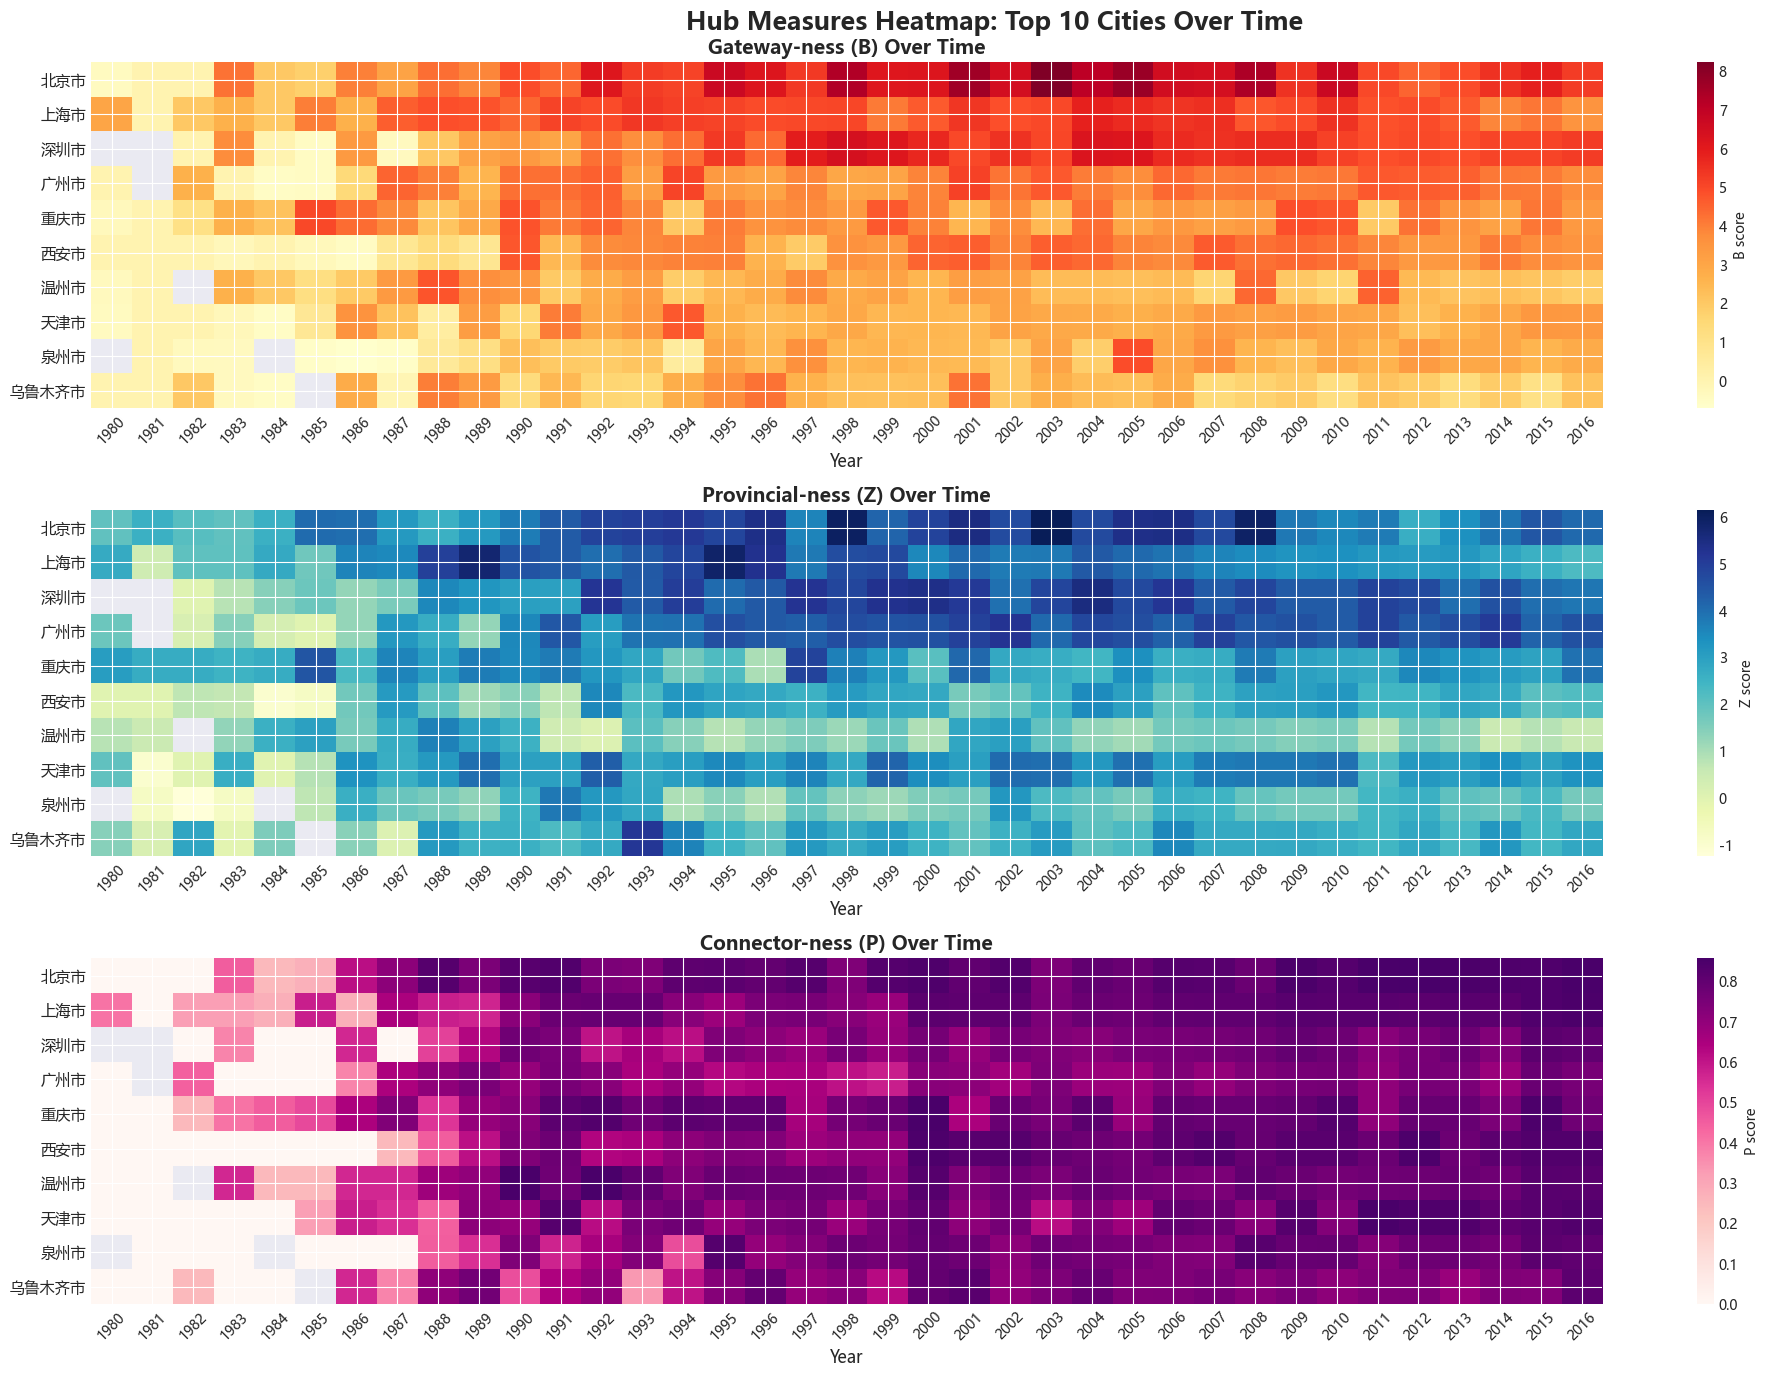


✓ All visualizations complete!


In [85]:
# ============================================================================
# PART 5: HEATMAP VISUALIZATION
# ============================================================================

print("\nGenerating heatmaps for temporal evolution...")

fig, axes = plt.subplots(3, 1, figsize=(20, 14))
fig.suptitle('Hub Measures Heatmap: Top 10 Cities Over Time', fontsize=18, fontweight='bold')

# Prepare data matrices
B_matrix = []
Z_matrix = []
P_matrix = []

for city in cities_to_track:
    B_matrix.append(city_B_series[city])
    Z_matrix.append(city_Z_series[city])
    P_matrix.append(city_P_series[city])

# Create city name labels for heatmap
city_name_labels = [get_city_name(city) for city in cities_to_track]

# Gateway-ness heatmap
ax = axes[0]
im = ax.imshow(B_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(cities_to_track)))
ax.set_yticklabels(city_name_labels, fontsize=11)
ax.set_xticks(range(len(years_available)))
ax.set_xticklabels(years_available, rotation=45)
ax.set_title('Gateway-ness (B) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='B score')

# Provincial-ness heatmap
ax = axes[1]
im = ax.imshow(Z_matrix, aspect='auto', cmap='YlGnBu', interpolation='nearest')
ax.set_yticks(range(len(cities_to_track)))
ax.set_yticklabels(city_name_labels, fontsize=11)
ax.set_xticks(range(len(years_available)))
ax.set_xticklabels(years_available, rotation=45)
ax.set_title('Provincial-ness (Z) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='Z score')

# Connector-ness heatmap
ax = axes[2]
im = ax.imshow(P_matrix, aspect='auto', cmap='RdPu', interpolation='nearest')
ax.set_yticks(range(len(cities_to_track)))
ax.set_yticklabels(city_name_labels, fontsize=11)
ax.set_xticks(range(len(years_available)))
ax.set_xticklabels(years_available, rotation=45)
ax.set_title('Connector-ness (P) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='P score')

plt.tight_layout()
plt.show()

print("\n✓ All visualizations complete!")

## County-Level Hub Analysis (Top 10)

In [86]:
# ============================================================================
# COUNTY LEVEL HUB ANALYSIS (ALL YEARS COMBINED)
# ============================================================================

print("\n" + "="*80)
print("COUNTY LEVEL HUB ANALYSIS (ALL YEARS COMBINED)")
print("="*80)

# Use pre-generated global graph for county level
G_county = graphs['county']['all']

print(f"\nCounty network: {G_county.number_of_nodes()} nodes, {G_county.number_of_edges()} edges")

# Detect communities
print("\nDetecting communities in county network...")
partition_county, modularity_county = detect_communities(G_county)
n_communities_county = len(set(partition_county.values()))
print(f"Number of communities: {n_communities_county}")
print(f"Modularity Q: {modularity_county:.3f}")

# Compute hub measures
print("\nComputing hub measures for county network...")
hub_measures_county = compute_hub_measures(G_county, partition_county)

# Print top 10 counties by each measure
print("\n" + "="*80)
print("=== Top 10 Counties by Gateway-ness (B) ===")
print("="*80)
top_B_county = sorted(hub_measures_county.items(), key=lambda x: x[1]['B'], reverse=True)[:10]
for i, (county, measures) in enumerate(top_B_county, 1):
    county_name = get_county_name(county)
    print(f"{i:2d}. {county_name:30s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

print("\n" + "="*80)
print("=== Top 10 Counties by Provincial-ness (Z) ===")
print("="*80)
top_Z_county = sorted(hub_measures_county.items(), key=lambda x: x[1]['Z'], reverse=True)[:10]
for i, (county, measures) in enumerate(top_Z_county, 1):
    county_name = get_county_name(county)
    print(f"{i:2d}. {county_name:30s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

print("\n" + "="*80)
print("=== Top 10 Counties by Connector-ness (P) ===")
print("="*80)
top_P_county = sorted(hub_measures_county.items(), key=lambda x: x[1]['P'], reverse=True)[:10]
for i, (county, measures) in enumerate(top_P_county, 1):
    county_name = get_county_name(county)
    print(f"{i:2d}. {county_name:30s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

# Classify hubs in county network
classification_county = classify_hubs(hub_measures_county)
print("\n" + "="*80)
print("County Hub Classification:")
print(f"  Gateway hubs (B ≥ 1.5): {len(classification_county['gateway'])}")
print(f"  Provincial hubs (Z ≥ 1.5): {len(classification_county['provincial'])}")
print(f"  Connector hubs (P ≥ 0.7): {len(classification_county['connector'])}")
print("="*80)


COUNTY LEVEL HUB ANALYSIS (ALL YEARS COMBINED)

County network: 2697 nodes, 83069 edges

Detecting communities in county network...
Number of communities: 13
Modularity Q: 0.549

Computing hub measures for county network...

=== Top 10 Counties by Gateway-ness (B) ===
 1. 朝阳区                           : B= 11.40, Z=  7.17, P=  0.87
 2. 宝安区                           : B= 10.19, Z=  6.74, P=  0.85
 3. 浦东新区                          : B=  9.78, Z=  5.26, P=  0.86
 4. 海淀区                           : B=  9.39, Z=  6.84, P=  0.87
 5. 龙岗区                           : B=  7.79, Z=  5.51, P=  0.84
 6. 城关区                           : B=  7.34, Z=  5.19, P=  0.82
 7. 白云区                           : B=  6.54, Z=  5.82, P=  0.81
 8. 武昌区                           : B=  6.11, Z=  3.94, P=  0.86
 9. 官渡区                           : B=  5.89, Z=  4.99, P=  0.82
10. 晋江市                           : B=  5.75, Z=  3.72, P=  0.84

=== Top 10 Counties by Provincial-ness (Z) ===
 1. 朝阳区                         

In [87]:
# ============================================================================
# PART 2: TEMPORAL HUB ANALYSIS (YEAR BY YEAR) - COUNTY LEVEL
# ============================================================================

print("\n" + "="*80)
print("TEMPORAL HUB ANALYSIS - YEAR BY YEAR (COUNTY LEVEL)")
print("="*80)

# Define years to analyze
years_to_analyze_county = list(range(1980, 2017))

# Compute hub measures for all years using pre-generated graphs
yearly_hub_measures_county = {}
yearly_modularity_county = {}
yearly_top10_B_county = {}
yearly_top10_Z_county = {}
yearly_top10_P_county = {}
yearly_hub_classification_county = {}

print("\nComputing hub measures for each year using pre-generated graphs...")
for year in tqdm(years_to_analyze_county):
    # Use pre-generated graph
    G = graphs['county'][year]
    
    if G.number_of_nodes() > 10:
        partition, modularity = detect_communities(G)
        hub_measures = compute_hub_measures(G, partition)
        
        yearly_hub_measures_county[year] = hub_measures
        yearly_modularity_county[year] = modularity
        
        # Get top 10 for each measure
        top_B = sorted(hub_measures.items(), key=lambda x: x[1]['B'], reverse=True)[:10]
        top_Z = sorted(hub_measures.items(), key=lambda x: x[1]['Z'], reverse=True)[:10]
        top_P = sorted(hub_measures.items(), key=lambda x: x[1]['P'], reverse=True)[:10]
        
        yearly_top10_B_county[year] = top_B
        yearly_top10_Z_county[year] = top_Z
        yearly_top10_P_county[year] = top_P
        
        # Classify hubs
        classification = classify_hubs(hub_measures)
        yearly_hub_classification_county[year] = classification
        
        n_communities = len(set(partition.values()))

print("\n✓ Computed hub measures for all years!")

# Print top 10 for selected years
selected_years_county = [2000, 2005, 2010, 2015, 2016]

for year in selected_years_county:
    if year in yearly_top10_B_county:
        print("\n" + "="*80)
        print(f"YEAR {year} - COUNTY LEVEL")
        print("="*80)
        
        print("\n--- Top 10 Counties by Gateway-ness (B) ---")
        for i, (county, measures) in enumerate(yearly_top10_B_county[year], 1):
            county_name = get_county_name(county)
            print(f"{i:2d}. {county_name:30s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")
        
        print("\n--- Top 10 Counties by Provincial-ness (Z) ---")
        for i, (county, measures) in enumerate(yearly_top10_Z_county[year], 1):
            county_name = get_county_name(county)
            print(f"{i:2d}. {county_name:30s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")
        
        print("\n--- Top 10 Counties by Connector-ness (P) ---")
        for i, (county, measures) in enumerate(yearly_top10_P_county[year], 1):
            county_name = get_county_name(county)
            print(f"{i:2d}. {county_name:30s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")


TEMPORAL HUB ANALYSIS - YEAR BY YEAR (COUNTY LEVEL)

Computing hub measures for each year using pre-generated graphs...


100%|██████████| 37/37 [00:45<00:00,  1.23s/it]


✓ Computed hub measures for all years!

YEAR 2000 - COUNTY LEVEL

--- Top 10 Counties by Gateway-ness (B) ---
 1. 宝安区                           : B= 10.74, Z= 11.33, P=  0.66
 2. 浦东新区                          : B= 10.36, Z=  9.59, P=  0.61
 3. 海淀区                           : B=  9.66, Z=  8.49, P=  0.81
 4. 龙岗区                           : B=  9.12, Z=  6.67, P=  0.73
 5. 朝阳区                           : B=  9.11, Z=  9.10, P=  0.78
 6. 滨海新区                          : B=  7.32, Z=  6.35, P=  0.68
 7. 白云区                           : B=  6.11, Z=  3.76, P=  0.76
 8. 城关区                           : B=  5.40, Z=  8.98, P=  0.51
 9. 义乌市                           : B=  5.09, Z=  0.93, P=  0.78
10. 库尔勒市                          : B=  5.05, Z=  4.09, P=  0.65

--- Top 10 Counties by Provincial-ness (Z) ---
 1. 宝安区                           : B= 10.74, Z= 11.33, P=  0.66
 2. 浦东新区                          : B= 10.36, Z=  9.59, P=  0.61
 3. 朝阳区                           : B=  9.11, Z=  9.10, P=  0


GENERATING VISUALIZATIONS - COUNTY LEVEL

Major counties (appear in ≥15 years): 2164

Tracking top 10 counties by average Gateway-ness:
   1. 浦东新区                          : Average B = 7.49
   2. 宝安区                           : Average B = 7.49
   3. 朝阳区                           : Average B = 7.38
   4. 海淀区                           : Average B = 5.85
   5. 龙岗区                           : Average B = 5.43
   6. 城关区                           : Average B = 4.17
   7. 白云区                           : Average B = 4.08
   8. 晋江市                           : Average B = 3.66
   9. 义乌市                           : Average B = 3.40
  10. 库尔勒市                          : Average B = 3.26


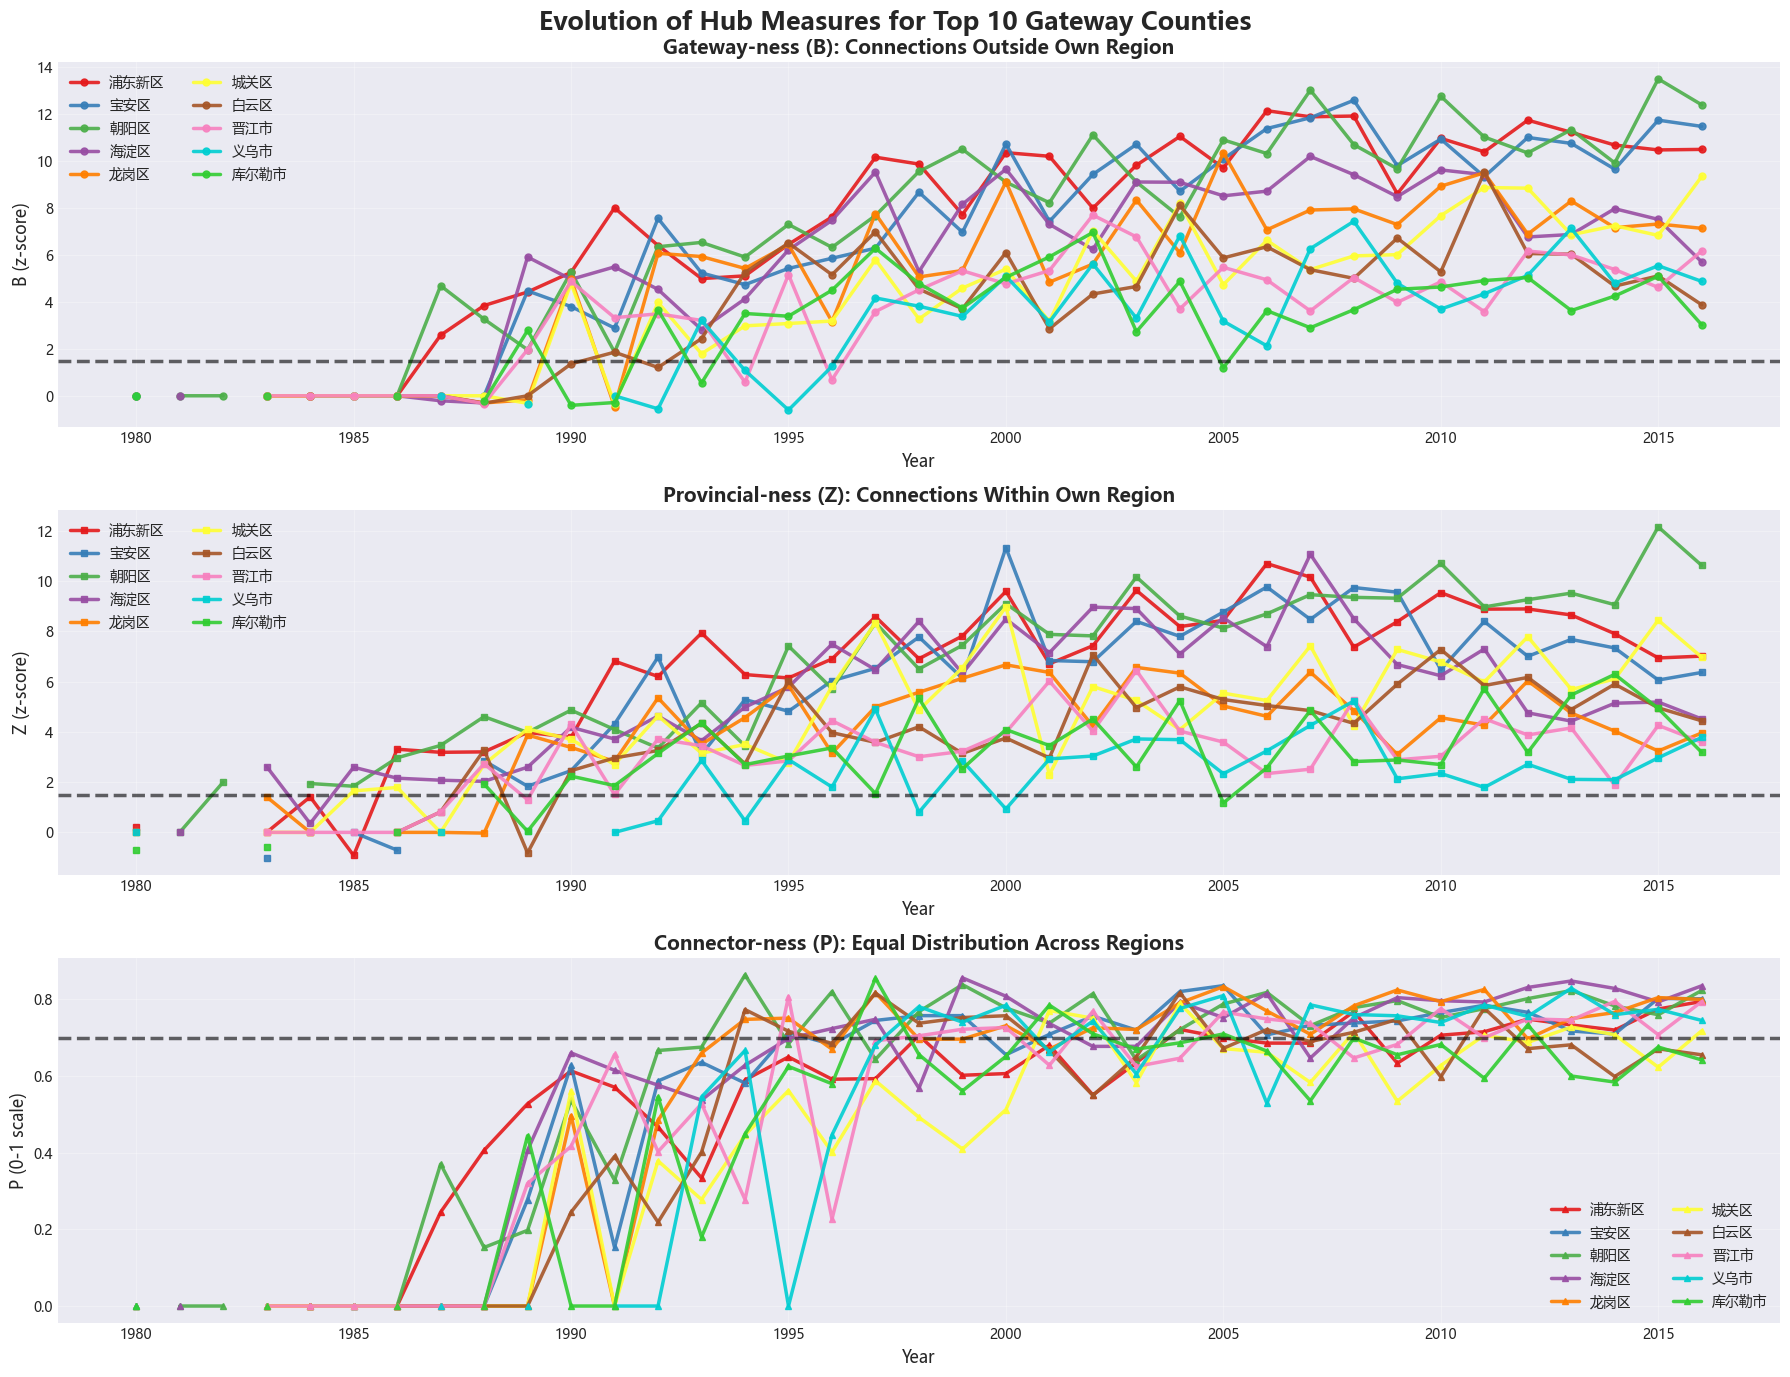

In [92]:
# ============================================================================
# PART 3: VISUALIZATION - EVOLUTION OF TOP COUNTIES
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS - COUNTY LEVEL")
print("="*80)

# Select major counties that appear frequently
county_counts = defaultdict(int)
county_avg_B = defaultdict(list)

for year, measures in yearly_hub_measures_county.items():
    for county, vals in measures.items():
        county_counts[county] += 1
        county_avg_B[county].append(vals['B'])

# Get counties that appear in at least 15 years
major_counties = [county for county, count in county_counts.items() if count >= 15]
print(f"\nMajor counties (appear in ≥15 years): {len(major_counties)}")

# Calculate average B for each major county
county_avg_B_score = {county: np.mean(county_avg_B[county]) for county in major_counties}
top_counties = sorted(county_avg_B_score.items(), key=lambda x: x[1], reverse=True)[:10]
counties_to_track = [county for county, _ in top_counties]

print(f"\nTracking top 10 counties by average Gateway-ness:")
for i, (county, avg_b) in enumerate(top_counties, 1):
    county_name = get_county_name(county)
    print(f"  {i:2d}. {county_name:30s}: Average B = {avg_b:.2f}")

# Extract time series for each measure
county_B_series = {county: [] for county in counties_to_track}
county_Z_series = {county: [] for county in counties_to_track}
county_P_series = {county: [] for county in counties_to_track}
years_available_county = []

for year in sorted(yearly_hub_measures_county.keys()):
    measures = yearly_hub_measures_county[year]
    years_available_county.append(year)
    
    for county in counties_to_track:
        if county in measures:
            county_B_series[county].append(measures[county]['B'])
            county_Z_series[county].append(measures[county]['Z'])
            county_P_series[county].append(measures[county]['P'])
        else:
            county_B_series[county].append(np.nan)
            county_Z_series[county].append(np.nan)
            county_P_series[county].append(np.nan)

# Plot evolution with enhanced styling
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('Evolution of Hub Measures for Top 10 Gateway Counties', fontsize=18, fontweight='bold')

# Gateway-ness
ax = axes[0]
for i, county in enumerate(counties_to_track):
    county_name = get_county_name(county)
    ax.plot(years_available_county, county_B_series[county], marker='o', label=county_name,
            linewidth=2.5, markersize=5, alpha=0.9, color=distinct_colors[i])
ax.set_title('Gateway-ness (B): Connections Outside Own Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('B (z-score)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=1.5, color='black', linestyle='--', alpha=0.6, linewidth=2.5, label='Gateway hub threshold')

# Provincial-ness
ax = axes[1]
for i, county in enumerate(counties_to_track):
    county_name = get_county_name(county)
    ax.plot(years_available_county, county_Z_series[county], marker='s', label=county_name,
            linewidth=2.5, markersize=5, alpha=0.9, color=distinct_colors[i])
ax.set_title('Provincial-ness (Z): Connections Within Own Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Z (z-score)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=1.5, color='black', linestyle='--', alpha=0.6, linewidth=2.5, label='Provincial hub threshold')

# Connector-ness
ax = axes[2]
for i, county in enumerate(counties_to_track):
    county_name = get_county_name(county)
    ax.plot(years_available_county, county_P_series[county], marker='^', label=county_name,
            linewidth=2.5, markersize=5, alpha=0.9, color=distinct_colors[i])
ax.set_title('Connector-ness (P): Equal Distribution Across Regions', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('P (0-1 scale)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=0.7, color='black', linestyle='--', alpha=0.6, linewidth=2.5, label='Connector hub threshold')

plt.tight_layout()
plt.show()

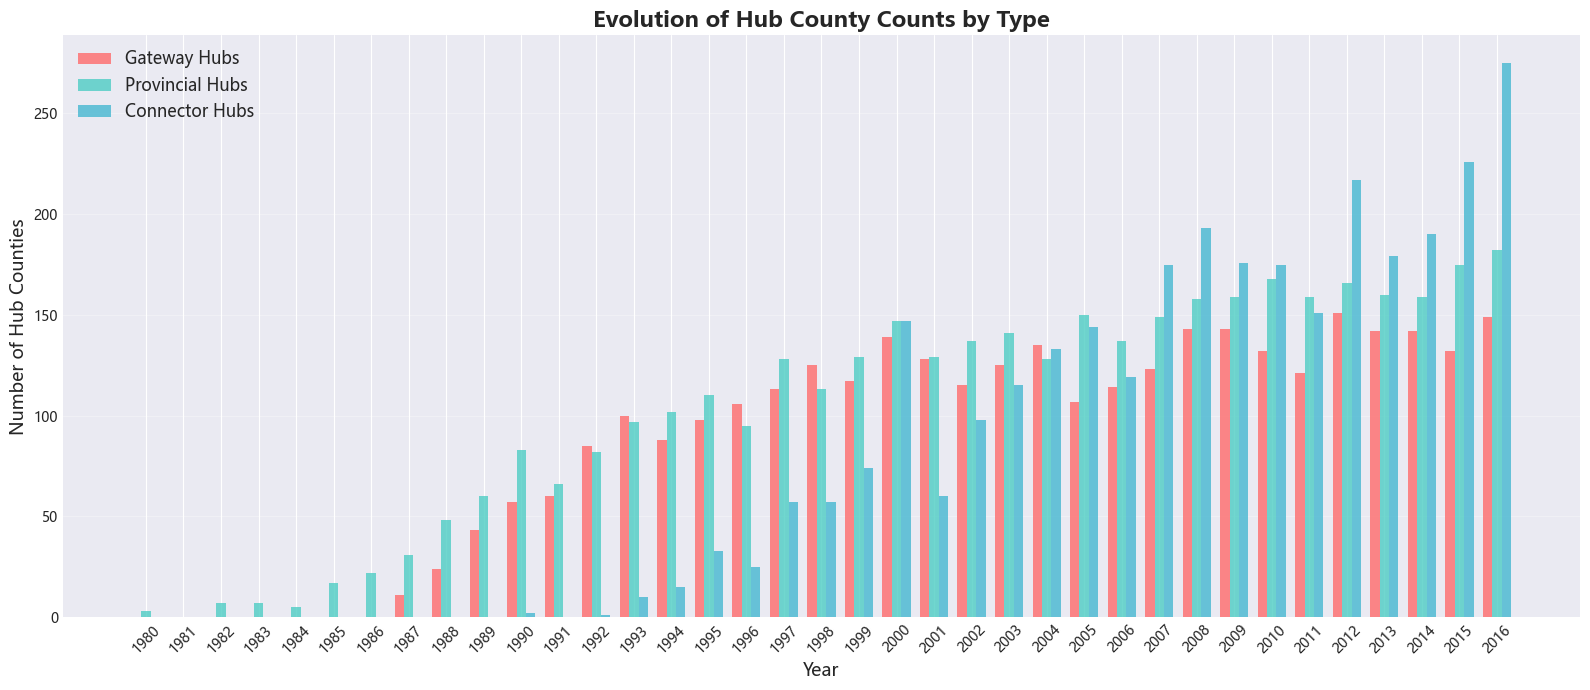


HUB COUNTS SUMMARY - COUNTY LEVEL

Gateway Hubs:
  Min: 0, Max: 151, Avg: 88.3

Provincial Hubs:
  Min: 0, Max: 182, Avg: 102.9

Connector Hubs:
  Min: 0, Max: 275, Avg: 82.4


In [90]:
# ============================================================================
# PART 4: HUB COUNTS EVOLUTION BAR CHART - COUNTY LEVEL
# ============================================================================

# Plot evolution of hub counts
hub_counts_data_county = {
    'Gateway': [],
    'Provincial': [],
    'Connector': []
}

years_list_county = sorted(yearly_hub_classification_county.keys())
for year in years_list_county:
    classification = yearly_hub_classification_county[year]
    hub_counts_data_county['Gateway'].append(len(classification['gateway']))
    hub_counts_data_county['Provincial'].append(len(classification['provincial']))
    hub_counts_data_county['Connector'].append(len(classification['connector']))

fig, ax = plt.subplots(figsize=(16, 7))
width = 0.25
x = np.arange(len(years_list_county))

ax.bar(x - width, hub_counts_data_county['Gateway'], width, label='Gateway Hubs', alpha=0.8, color='#FF6B6B')
ax.bar(x, hub_counts_data_county['Provincial'], width, label='Provincial Hubs', alpha=0.8, color='#4ECDC4')
ax.bar(x + width, hub_counts_data_county['Connector'], width, label='Connector Hubs', alpha=0.8, color='#45B7D1')

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Number of Hub Counties', fontsize=13)
ax.set_title('Evolution of Hub County Counts by Type', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(years_list_county, rotation=45)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("HUB COUNTS SUMMARY - COUNTY LEVEL")
print("="*80)
print(f"\nGateway Hubs:")
print(f"  Min: {min(hub_counts_data_county['Gateway'])}, Max: {max(hub_counts_data_county['Gateway'])}, Avg: {np.mean(hub_counts_data_county['Gateway']):.1f}")
print(f"\nProvincial Hubs:")
print(f"  Min: {min(hub_counts_data_county['Provincial'])}, Max: {max(hub_counts_data_county['Provincial'])}, Avg: {np.mean(hub_counts_data_county['Provincial']):.1f}")
print(f"\nConnector Hubs:")
print(f"  Min: {min(hub_counts_data_county['Connector'])}, Max: {max(hub_counts_data_county['Connector'])}, Avg: {np.mean(hub_counts_data_county['Connector']):.1f}")


Generating heatmaps for temporal evolution...


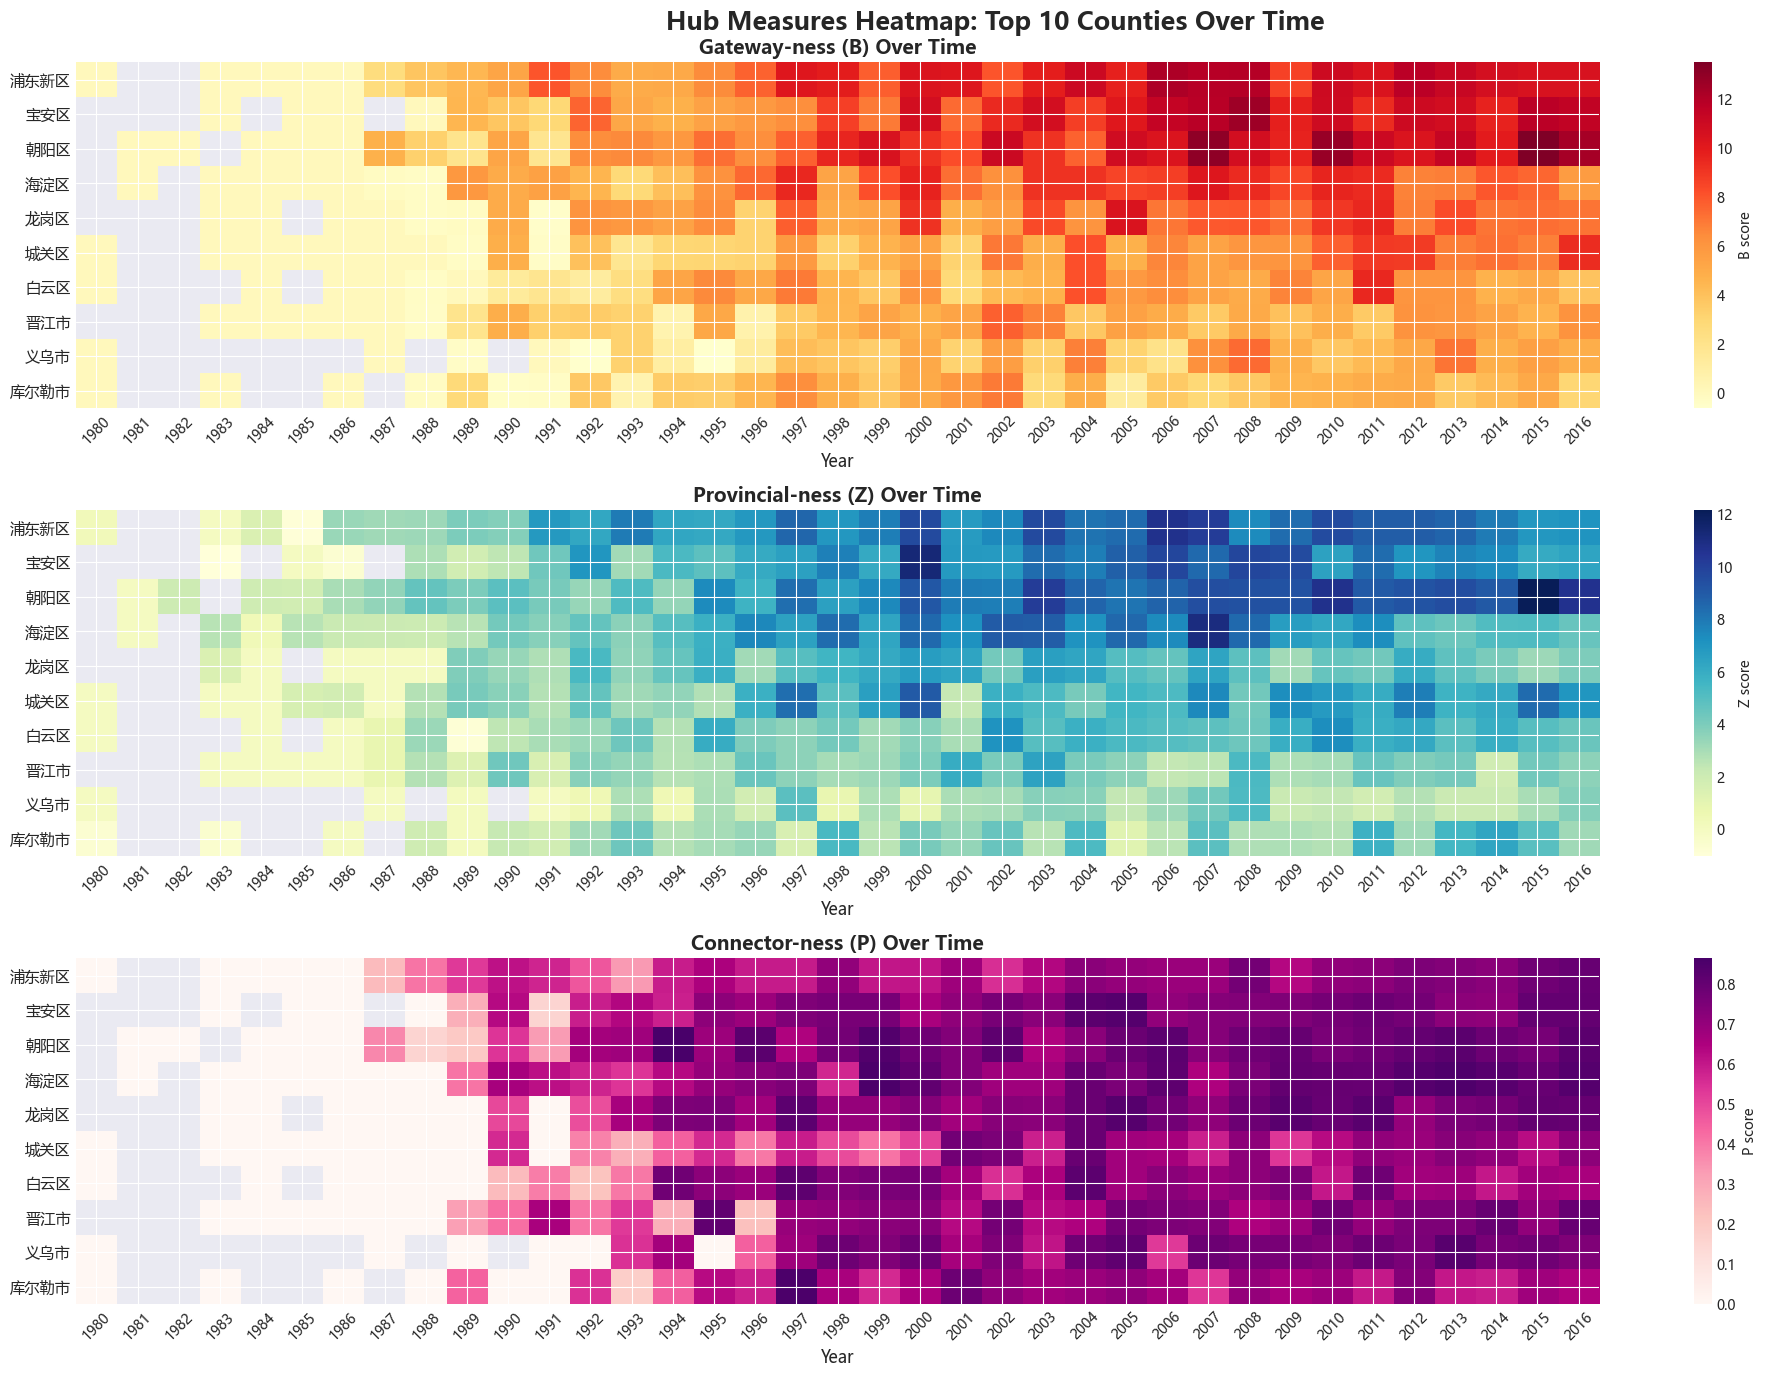


✓ All county-level visualizations complete!


In [93]:
# ============================================================================
# PART 5: HEATMAP VISUALIZATION - COUNTY LEVEL
# ============================================================================

print("\nGenerating heatmaps for temporal evolution...")

fig, axes = plt.subplots(3, 1, figsize=(20, 14))
fig.suptitle('Hub Measures Heatmap: Top 10 Counties Over Time', fontsize=18, fontweight='bold')

# Prepare data matrices
B_matrix_county = []
Z_matrix_county = []
P_matrix_county = []

for county in counties_to_track:
    B_matrix_county.append(county_B_series[county])
    Z_matrix_county.append(county_Z_series[county])
    P_matrix_county.append(county_P_series[county])

# Create county name labels for heatmap
county_name_labels = [get_county_name(county) for county in counties_to_track]

# Gateway-ness heatmap
ax = axes[0]
im = ax.imshow(B_matrix_county, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(counties_to_track)))
ax.set_yticklabels(county_name_labels, fontsize=11)
ax.set_xticks(range(len(years_available_county)))
ax.set_xticklabels(years_available_county, rotation=45)
ax.set_title('Gateway-ness (B) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='B score')

# Provincial-ness heatmap
ax = axes[1]
im = ax.imshow(Z_matrix_county, aspect='auto', cmap='YlGnBu', interpolation='nearest')
ax.set_yticks(range(len(counties_to_track)))
ax.set_yticklabels(county_name_labels, fontsize=11)
ax.set_xticks(range(len(years_available_county)))
ax.set_xticklabels(years_available_county, rotation=45)
ax.set_title('Provincial-ness (Z) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='Z score')

# Connector-ness heatmap
ax = axes[2]
im = ax.imshow(P_matrix_county, aspect='auto', cmap='RdPu', interpolation='nearest')
ax.set_yticks(range(len(counties_to_track)))
ax.set_yticklabels(county_name_labels, fontsize=11)
ax.set_xticks(range(len(years_available_county)))
ax.set_xticklabels(years_available_county, rotation=45)
ax.set_title('Connector-ness (P) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='P score')

plt.tight_layout()
plt.show()

print("\n✓ All county-level visualizations complete!")

## Province-Level Hub Analysis (Top 10)

In [104]:
# ============================================================================
# PROVINCE LEVEL HUB ANALYSIS (ALL YEARS COMBINED)
# ============================================================================

print("\n" + "="*80)
print("PROVINCE LEVEL HUB ANALYSIS (ALL YEARS COMBINED)")
print("="*80)

# Use pre-generated global graph for province level
G_province = graphs['province']['all']

print(f"\nProvince network: {G_province.number_of_nodes()} nodes, {G_province.number_of_edges()} edges")

# Detect communities
print("\nDetecting communities in province network...")
partition_province, modularity_province = detect_communities(G_province)
n_communities_province = len(set(partition_province.values()))
print(f"Number of communities: {n_communities_province}")
print(f"Modularity Q: {modularity_province:.3f}")

# Compute hub measures
print("\nComputing hub measures for province network...")
hub_measures_province = compute_hub_measures(G_province, partition_province)

# Print top 10 provinces by each measure
print("\n" + "="*80)
print("=== Top 10 Provinces by Gateway-ness (B) ===")
print("="*80)
top_B_province = sorted(hub_measures_province.items(), key=lambda x: x[1]['B'], reverse=True)[:10]
for i, (province, measures) in enumerate(top_B_province, 1):
    province_name = get_province_name(province)
    print(f"{i:2d}. {province_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

print("\n" + "="*80)
print("=== Top 10 Provinces by Provincial-ness (Z) ===")
print("="*80)
top_Z_province = sorted(hub_measures_province.items(), key=lambda x: x[1]['Z'], reverse=True)[:10]
for i, (province, measures) in enumerate(top_Z_province, 1):
    province_name = get_province_name(province)
    print(f"{i:2d}. {province_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

print("\n" + "="*80)
print("=== Top 10 Provinces by Connector-ness (P) ===")
print("="*80)
top_P_province = sorted(hub_measures_province.items(), key=lambda x: x[1]['P'], reverse=True)[:10]
for i, (province, measures) in enumerate(top_P_province, 1):
    province_name = get_province_name(province)
    print(f"{i:2d}. {province_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

# Classify hubs in province network
classification_province = classify_hubs(hub_measures_province)
print("\n" + "="*80)
print("Province Hub Classification:")
print(f"  Gateway hubs (B ≥ 1.5): {len(classification_province['gateway'])}")
print(f"  Provincial hubs (Z ≥ 1.5): {len(classification_province['provincial'])}")
print(f"  Connector hubs (P ≥ 0.7): {len(classification_province['connector'])}")
print("="*80)


PROVINCE LEVEL HUB ANALYSIS (ALL YEARS COMBINED)

Province network: 31 nodes, 465 edges

Detecting communities in province network...
Number of communities: 4
Modularity Q: 0.282

Computing hub measures for province network...

=== Top 10 Provinces by Gateway-ness (B) ===
 1. 江西省                      : B=  0.00, Z=  0.00, P=  0.69
 2. 广东省                      : B=  0.00, Z=  0.00, P=  0.69
 3. 四川省                      : B=  0.00, Z=  0.00, P=  0.69
 4. 福建省                      : B=  0.00, Z=  0.00, P=  0.69
 5. 黑龙江省                     : B=  0.00, Z=  0.00, P=  0.68
 6. 辽宁省                      : B=  0.00, Z=  0.00, P=  0.68
 7. 广西壮族自治区                  : B=  0.00, Z=  0.00, P=  0.69
 8. 云南省                      : B=  0.00, Z=  0.00, P=  0.69
 9. 河南省                      : B=  0.00, Z=  0.00, P=  0.68
10. 河北省                      : B=  0.00, Z=  0.00, P=  0.68

=== Top 10 Provinces by Provincial-ness (Z) ===
 1. 江西省                      : B=  0.00, Z=  0.00, P=  0.69
 2. 广东省          

In [105]:
# ============================================================================
# PART 2: TEMPORAL HUB ANALYSIS (YEAR BY YEAR) - PROVINCE LEVEL
# ============================================================================

print("\n" + "="*80)
print("TEMPORAL HUB ANALYSIS - YEAR BY YEAR (PROVINCE LEVEL)")
print("="*80)

# Define years to analyze
years_to_analyze_province = list(range(1980, 2017))

# Compute hub measures for all years using pre-generated graphs
yearly_hub_measures_province = {}
yearly_modularity_province = {}
yearly_top10_B_province = {}
yearly_top10_Z_province = {}
yearly_top10_P_province = {}
yearly_hub_classification_province = {}

print("\nComputing hub measures for each year using pre-generated graphs...")
for year in tqdm(years_to_analyze_province):
    # Use pre-generated graph
    G = graphs['province'][year]
    
    if G.number_of_nodes() > 10:
        partition, modularity = detect_communities(G)
        hub_measures = compute_hub_measures(G, partition)
        
        yearly_hub_measures_province[year] = hub_measures
        yearly_modularity_province[year] = modularity
        
        # Get top 10 for each measure
        top_B = sorted(hub_measures.items(), key=lambda x: x[1]['B'], reverse=True)[:10]
        top_Z = sorted(hub_measures.items(), key=lambda x: x[1]['Z'], reverse=True)[:10]
        top_P = sorted(hub_measures.items(), key=lambda x: x[1]['P'], reverse=True)[:10]
        
        yearly_top10_B_province[year] = top_B
        yearly_top10_Z_province[year] = top_Z
        yearly_top10_P_province[year] = top_P
        
        # Classify hubs
        classification = classify_hubs(hub_measures)
        yearly_hub_classification_province[year] = classification
        
        n_communities = len(set(partition.values()))

print("\n✓ Computed hub measures for all years!")

# Print top 10 for selected years
selected_years_province = [2000, 2005, 2010, 2015, 2016]

for year in selected_years_province:
    if year in yearly_top10_B_province:
        print("\n" + "="*80)
        print(f"YEAR {year} - PROVINCE LEVEL")
        print("="*80)
        
        print("\n--- Top 10 Provinces by Gateway-ness (B) ---")
        for i, (province, measures) in enumerate(yearly_top10_B_province[year], 1):
            province_name = get_province_name(province)
            print(f"{i:2d}. {province_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")
        
        print("\n--- Top 10 Provinces by Provincial-ness (Z) ---")
        for i, (province, measures) in enumerate(yearly_top10_Z_province[year], 1):
            province_name = get_province_name(province)
            print(f"{i:2d}. {province_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")
        
        print("\n--- Top 10 Provinces by Connector-ness (P) ---")
        for i, (province, measures) in enumerate(yearly_top10_P_province[year], 1):
            province_name = get_province_name(province)
            print(f"{i:2d}. {province_name:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")


TEMPORAL HUB ANALYSIS - YEAR BY YEAR (PROVINCE LEVEL)

Computing hub measures for each year using pre-generated graphs...


100%|██████████| 37/37 [00:00<00:00, 121.88it/s]


✓ Computed hub measures for all years!

YEAR 2000 - PROVINCE LEVEL

--- Top 10 Provinces by Gateway-ness (B) ---
 1. 浙江省                      : B=  1.50, Z=  0.00, P=  0.69
 2. 陕西省                      : B=  1.49, Z=  0.82, P=  0.70
 3. 四川省                      : B=  1.47, Z=  0.93, P=  0.71
 4. 湖北省                      : B=  1.47, Z=  0.93, P=  0.71
 5. 河南省                      : B=  1.34, Z=  0.65, P=  0.71
 6. 北京市                      : B=  1.34, Z=  0.65, P=  0.71
 7. 广东省                      : B=  0.90, Z=  0.93, P=  0.69
 8. 湖南省                      : B=  0.90, Z=  0.93, P=  0.70
 9. 山东省                      : B=  0.78, Z=  0.65, P=  0.72
10. 福建省                      : B=  0.62, Z= -0.46, P=  0.68

--- Top 10 Provinces by Provincial-ness (Z) ---
 1. 广东省                      : B=  0.90, Z=  0.93, P=  0.69
 2. 湖南省                      : B=  0.90, Z=  0.93, P=  0.70
 3. 四川省                      : B=  1.47, Z=  0.93, P=  0.71
 4. 湖北省                      : B=  1.47, Z=  0.93, P=  0.


GENERATING VISUALIZATIONS - PROVINCE LEVEL

Major provinces (appear in ≥15 years): 31

Tracking top 10 provinces by average Gateway-ness:
   1. 四川省                      : Average B = 1.38
   2. 河南省                      : Average B = 1.29
   3. 湖北省                      : Average B = 1.15
   4. 浙江省                      : Average B = 1.13
   5. 北京市                      : Average B = 1.06
   6. 陕西省                      : Average B = 0.81
   7. 广东省                      : Average B = 0.70
   8. 山东省                      : Average B = 0.54
   9. 河北省                      : Average B = 0.44
  10. 重庆市                      : Average B = 0.34


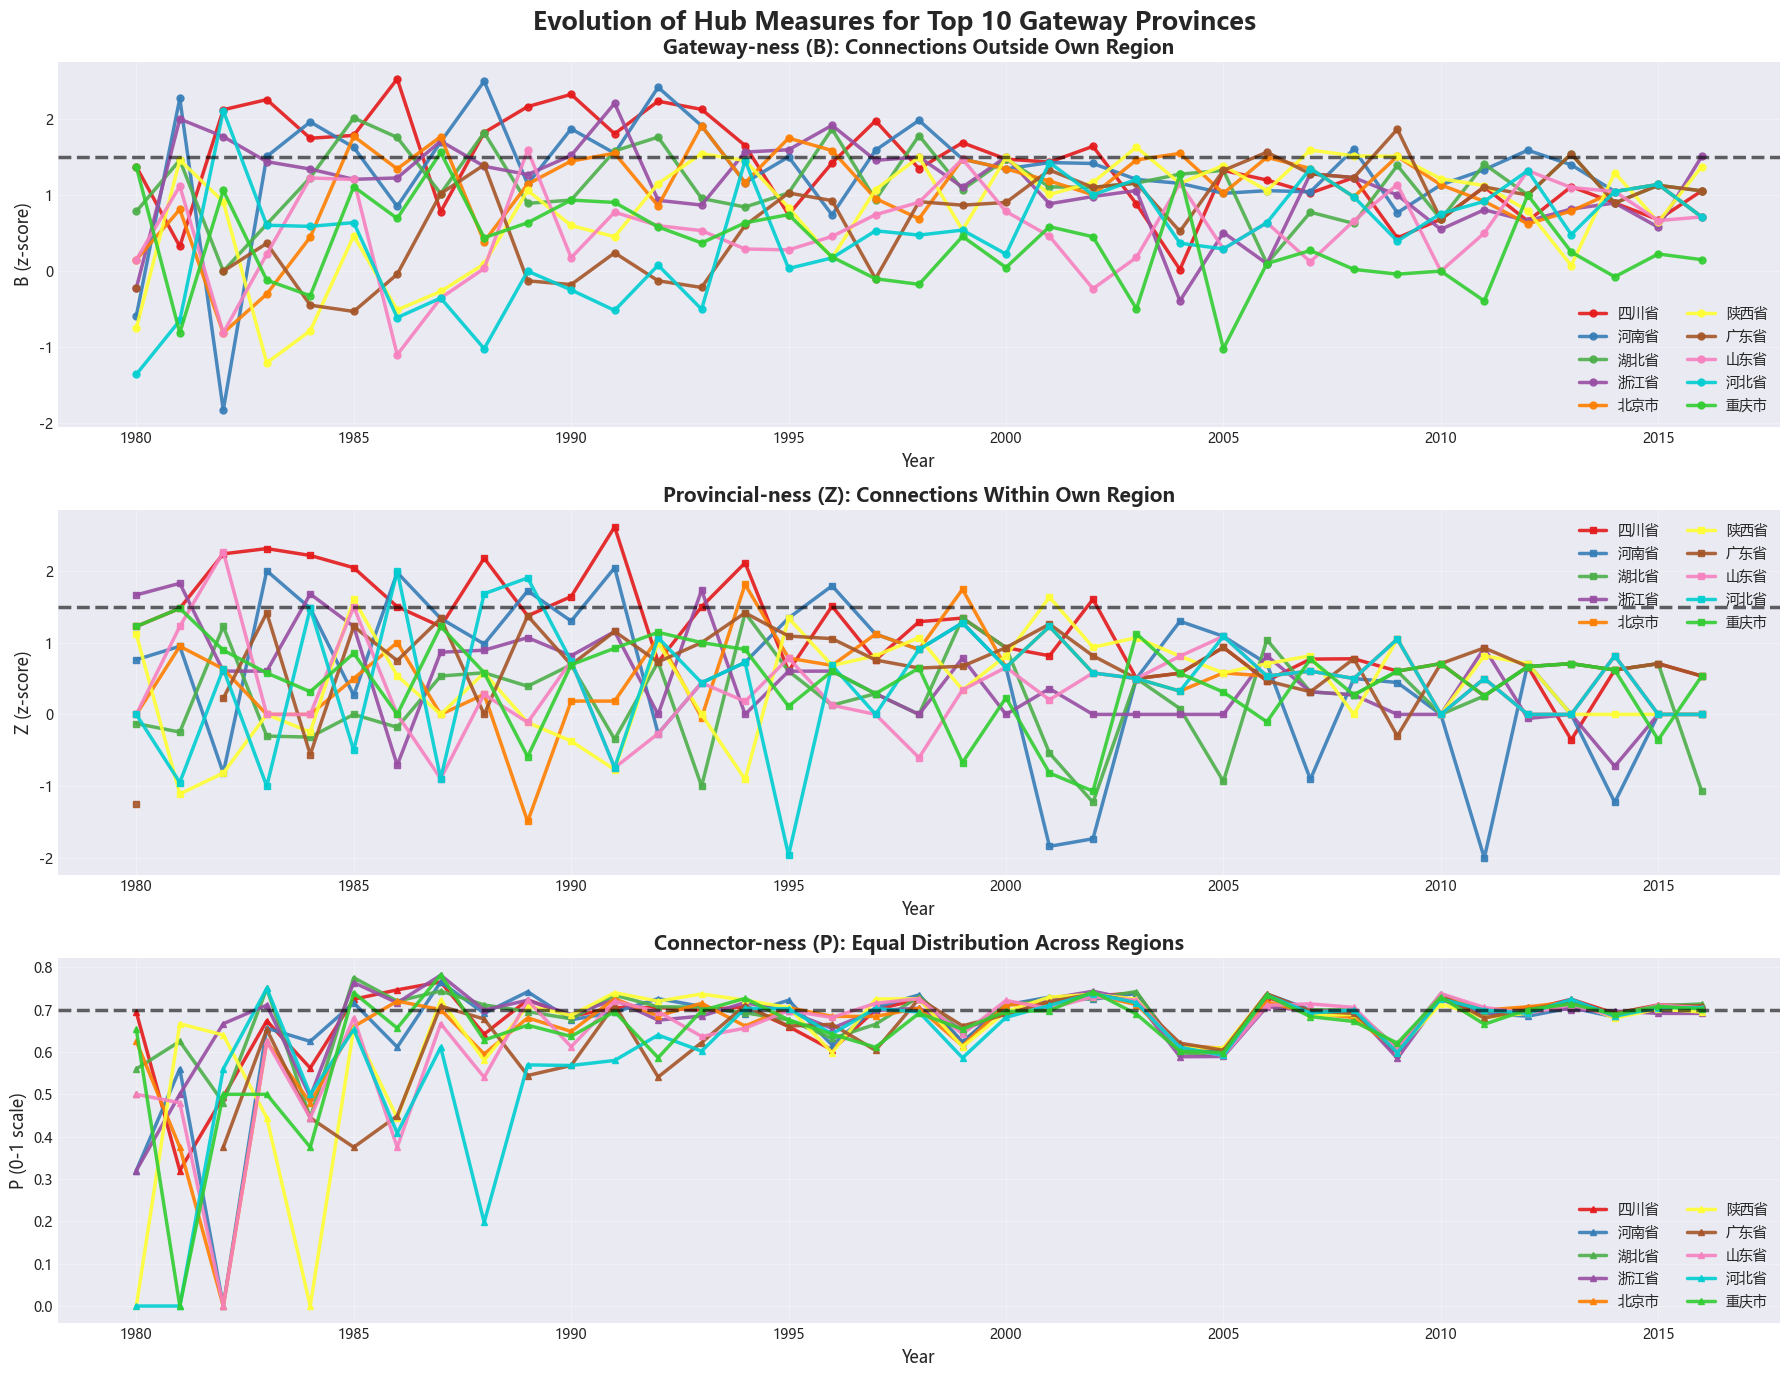

In [106]:
# ============================================================================
# PART 3: VISUALIZATION - EVOLUTION OF TOP PROVINCES
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS - PROVINCE LEVEL")
print("="*80)

# Select major provinces that appear frequently
province_counts = defaultdict(int)
province_avg_B = defaultdict(list)

for year, measures in yearly_hub_measures_province.items():
    for province, vals in measures.items():
        province_counts[province] += 1
        province_avg_B[province].append(vals['B'])

# Get provinces that appear in at least 15 years
major_provinces = [province for province, count in province_counts.items() if count >= 15]
print(f"\nMajor provinces (appear in ≥15 years): {len(major_provinces)}")

# Calculate average B for each major province
province_avg_B_score = {province: np.mean(province_avg_B[province]) for province in major_provinces}
top_provinces = sorted(province_avg_B_score.items(), key=lambda x: x[1], reverse=True)[:10]
provinces_to_track = [province for province, _ in top_provinces]

print(f"\nTracking top 10 provinces by average Gateway-ness:")
for i, (province, avg_b) in enumerate(top_provinces, 1):
    province_name = get_province_name(province)
    print(f"  {i:2d}. {province_name:25s}: Average B = {avg_b:.2f}")

# Extract time series for each measure
province_B_series = {province: [] for province in provinces_to_track}
province_Z_series = {province: [] for province in provinces_to_track}
province_P_series = {province: [] for province in provinces_to_track}
years_available_province = []

for year in sorted(yearly_hub_measures_province.keys()):
    measures = yearly_hub_measures_province[year]
    years_available_province.append(year)
    
    for province in provinces_to_track:
        if province in measures:
            province_B_series[province].append(measures[province]['B'])
            province_Z_series[province].append(measures[province]['Z'])
            province_P_series[province].append(measures[province]['P'])
        else:
            province_B_series[province].append(np.nan)
            province_Z_series[province].append(np.nan)
            province_P_series[province].append(np.nan)

# Plot evolution with enhanced styling
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('Evolution of Hub Measures for Top 10 Gateway Provinces', fontsize=18, fontweight='bold')

# Gateway-ness
ax = axes[0]
for i, province in enumerate(provinces_to_track):
    province_name = get_province_name(province)
    ax.plot(years_available_province, province_B_series[province], marker='o', label=province_name,
            linewidth=2.5, markersize=5, alpha=0.9, color=distinct_colors[i])
ax.set_title('Gateway-ness (B): Connections Outside Own Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('B (z-score)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=1.5, color='black', linestyle='--', alpha=0.6, linewidth=2.5, label='Gateway hub threshold')

# Provincial-ness
ax = axes[1]
for i, province in enumerate(provinces_to_track):
    province_name = get_province_name(province)
    ax.plot(years_available_province, province_Z_series[province], marker='s', label=province_name,
            linewidth=2.5, markersize=5, alpha=0.9, color=distinct_colors[i])
ax.set_title('Provincial-ness (Z): Connections Within Own Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Z (z-score)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=1.5, color='black', linestyle='--', alpha=0.6, linewidth=2.5, label='Provincial hub threshold')

# Connector-ness
ax = axes[2]
for i, province in enumerate(provinces_to_track):
    province_name = get_province_name(province)
    ax.plot(years_available_province, province_P_series[province], marker='^', label=province_name,
            linewidth=2.5, markersize=5, alpha=0.9, color=distinct_colors[i])
ax.set_title('Connector-ness (P): Equal Distribution Across Regions', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('P (0-1 scale)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=0.7, color='black', linestyle='--', alpha=0.6, linewidth=2.5, label='Connector hub threshold')

plt.tight_layout()
plt.show()

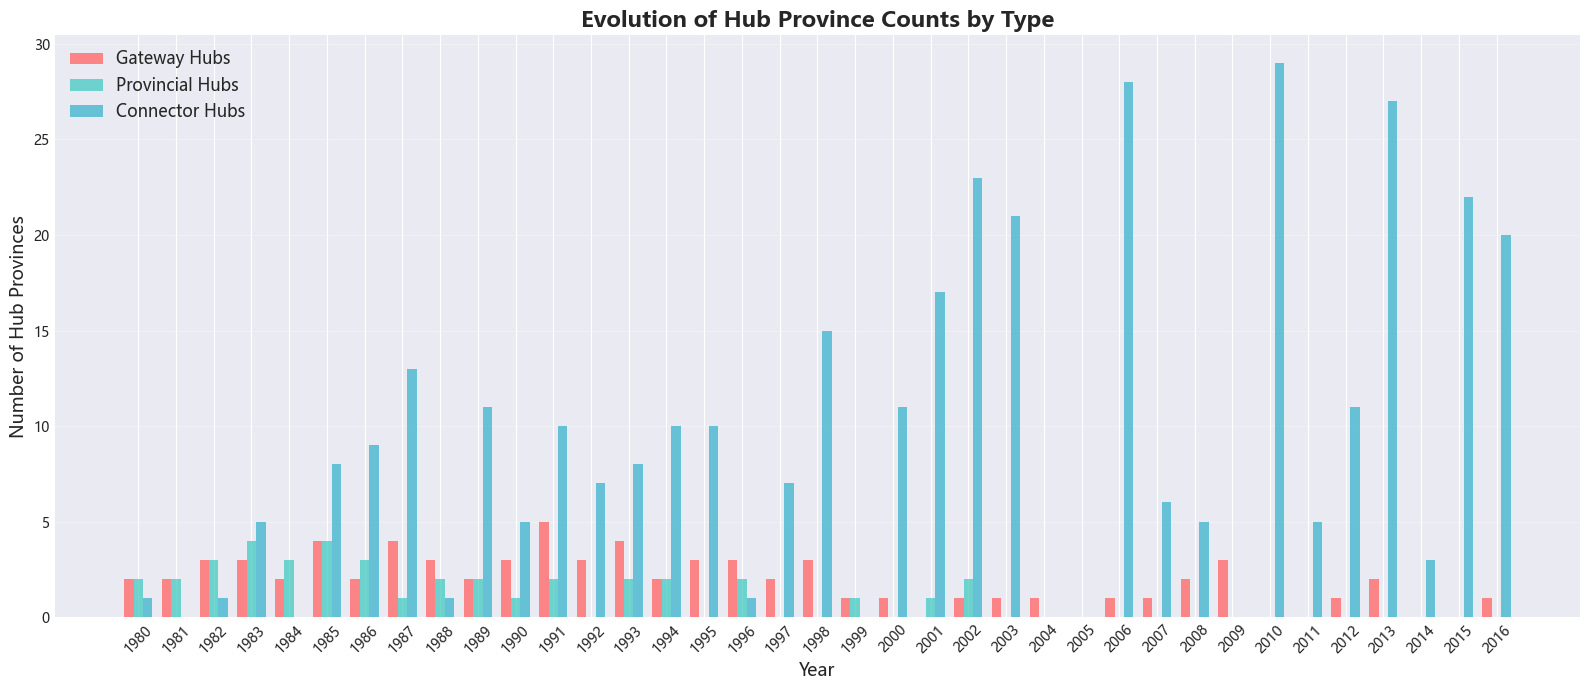


HUB COUNTS SUMMARY - PROVINCE LEVEL

Gateway Hubs:
  Min: 0, Max: 5, Avg: 1.9

Provincial Hubs:
  Min: 0, Max: 4, Avg: 1.1

Connector Hubs:
  Min: 0, Max: 29, Avg: 9.5


In [107]:
# ============================================================================
# PART 4: HUB COUNTS EVOLUTION BAR CHART - PROVINCE LEVEL
# ============================================================================

# Plot evolution of hub counts
hub_counts_data_province = {
    'Gateway': [],
    'Provincial': [],
    'Connector': []
}

years_list_province = sorted(yearly_hub_classification_province.keys())
for year in years_list_province:
    classification = yearly_hub_classification_province[year]
    hub_counts_data_province['Gateway'].append(len(classification['gateway']))
    hub_counts_data_province['Provincial'].append(len(classification['provincial']))
    hub_counts_data_province['Connector'].append(len(classification['connector']))

fig, ax = plt.subplots(figsize=(16, 7))
width = 0.25
x = np.arange(len(years_list_province))

ax.bar(x - width, hub_counts_data_province['Gateway'], width, label='Gateway Hubs', alpha=0.8, color='#FF6B6B')
ax.bar(x, hub_counts_data_province['Provincial'], width, label='Provincial Hubs', alpha=0.8, color='#4ECDC4')
ax.bar(x + width, hub_counts_data_province['Connector'], width, label='Connector Hubs', alpha=0.8, color='#45B7D1')

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Number of Hub Provinces', fontsize=13)
ax.set_title('Evolution of Hub Province Counts by Type', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(years_list_province, rotation=45)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("HUB COUNTS SUMMARY - PROVINCE LEVEL")
print("="*80)
print(f"\nGateway Hubs:")
print(f"  Min: {min(hub_counts_data_province['Gateway'])}, Max: {max(hub_counts_data_province['Gateway'])}, Avg: {np.mean(hub_counts_data_province['Gateway']):.1f}")
print(f"\nProvincial Hubs:")
print(f"  Min: {min(hub_counts_data_province['Provincial'])}, Max: {max(hub_counts_data_province['Provincial'])}, Avg: {np.mean(hub_counts_data_province['Provincial']):.1f}")
print(f"\nConnector Hubs:")
print(f"  Min: {min(hub_counts_data_province['Connector'])}, Max: {max(hub_counts_data_province['Connector'])}, Avg: {np.mean(hub_counts_data_province['Connector']):.1f}")


Generating heatmaps for temporal evolution...


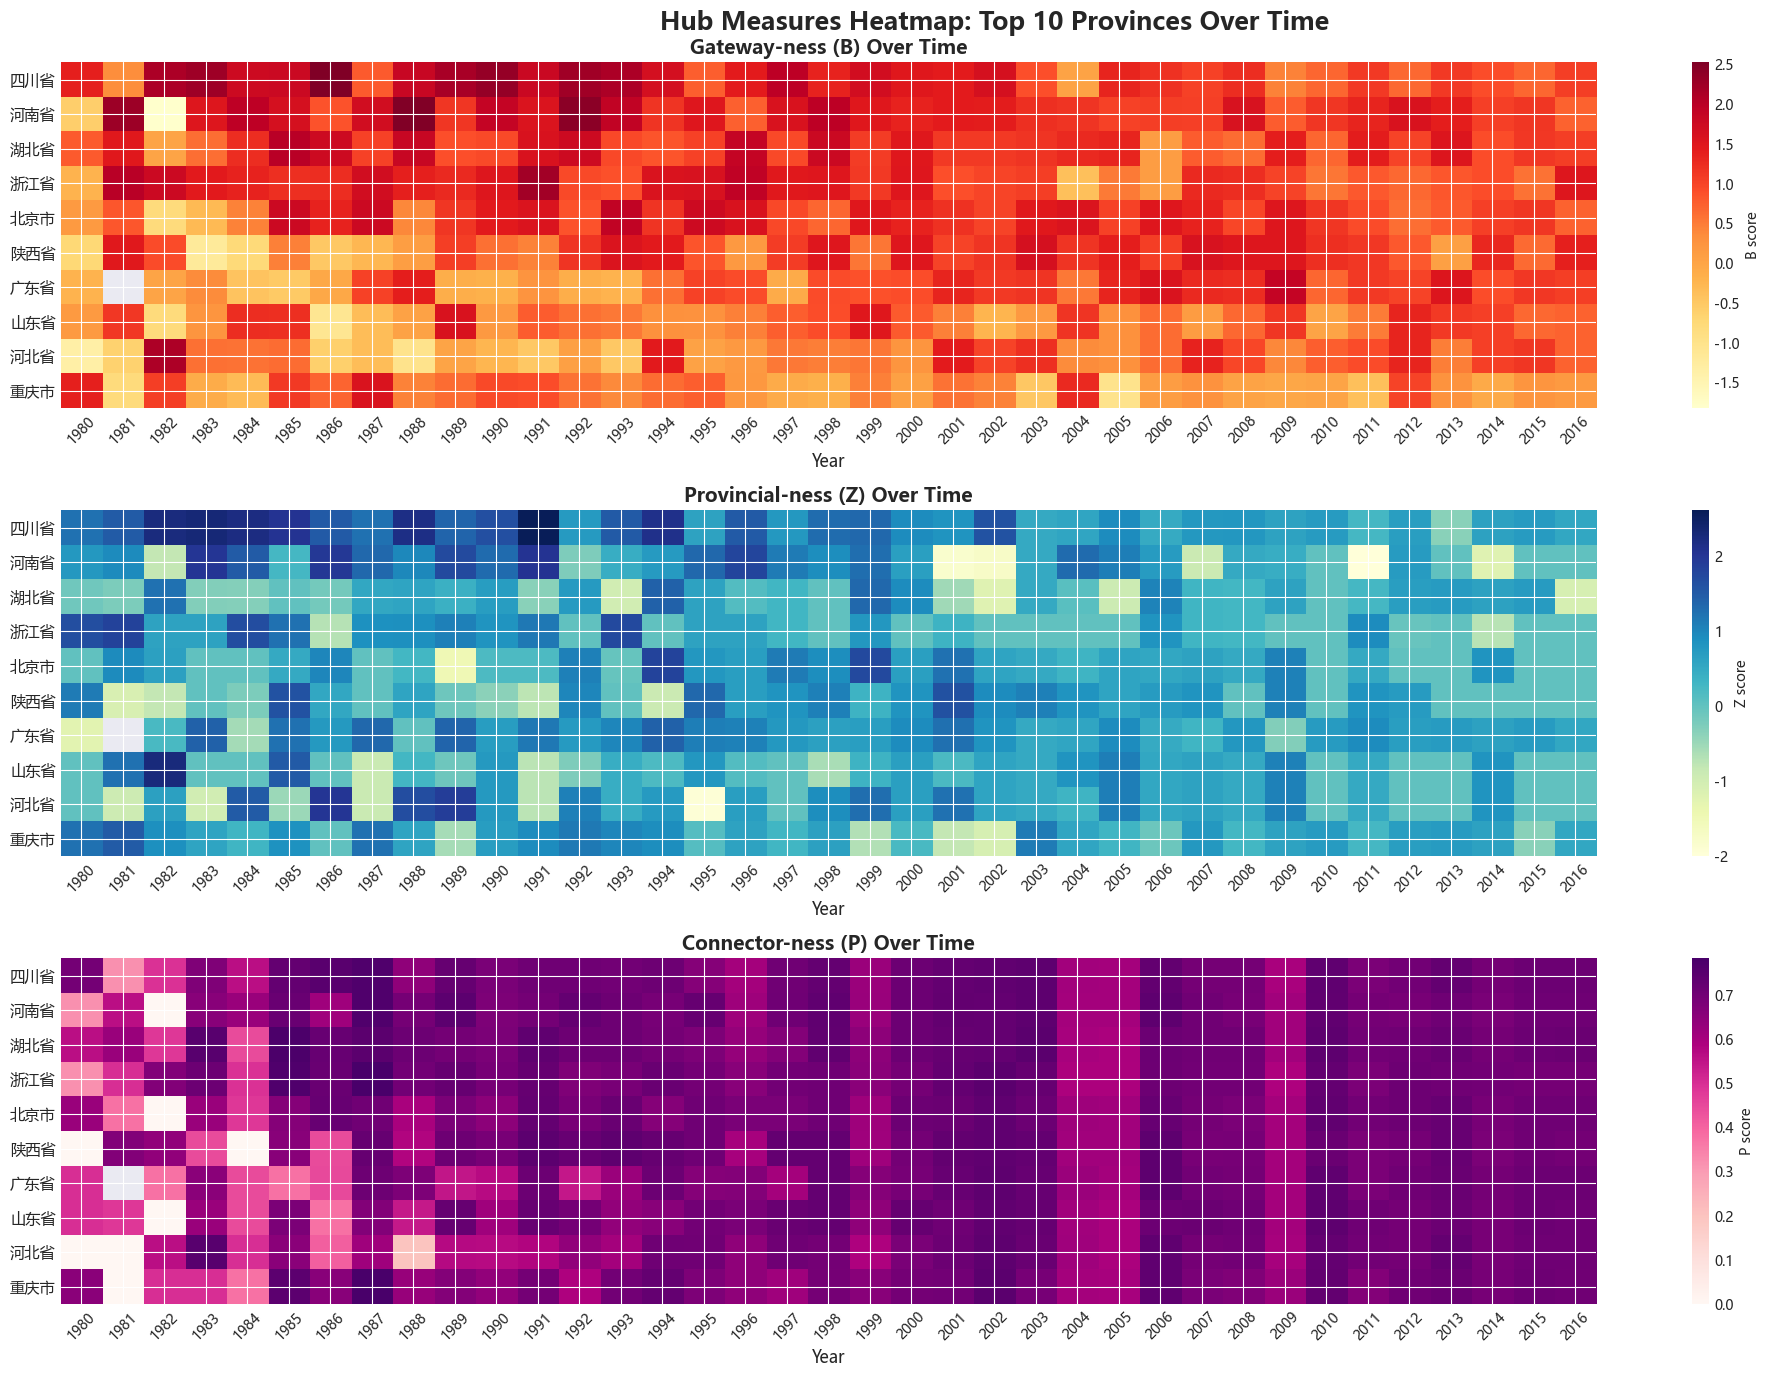


✓ All province-level visualizations complete!


In [108]:
# ============================================================================
# PART 5: HEATMAP VISUALIZATION - PROVINCE LEVEL
# ============================================================================

print("\nGenerating heatmaps for temporal evolution...")

fig, axes = plt.subplots(3, 1, figsize=(20, 14))
fig.suptitle('Hub Measures Heatmap: Top 10 Provinces Over Time', fontsize=18, fontweight='bold')

# Prepare data matrices
B_matrix_province = []
Z_matrix_province = []
P_matrix_province = []

for province in provinces_to_track:
    B_matrix_province.append(province_B_series[province])
    Z_matrix_province.append(province_Z_series[province])
    P_matrix_province.append(province_P_series[province])

# Create province name labels for heatmap
province_name_labels = [get_province_name(province) for province in provinces_to_track]

# Gateway-ness heatmap
ax = axes[0]
im = ax.imshow(B_matrix_province, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(provinces_to_track)))
ax.set_yticklabels(province_name_labels, fontsize=11)
ax.set_xticks(range(len(years_available_province)))
ax.set_xticklabels(years_available_province, rotation=45)
ax.set_title('Gateway-ness (B) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='B score')

# Provincial-ness heatmap
ax = axes[1]
im = ax.imshow(Z_matrix_province, aspect='auto', cmap='YlGnBu', interpolation='nearest')
ax.set_yticks(range(len(provinces_to_track)))
ax.set_yticklabels(province_name_labels, fontsize=11)
ax.set_xticks(range(len(years_available_province)))
ax.set_xticklabels(years_available_province, rotation=45)
ax.set_title('Provincial-ness (Z) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='Z score')

# Connector-ness heatmap
ax = axes[2]
im = ax.imshow(P_matrix_province, aspect='auto', cmap='RdPu', interpolation='nearest')
ax.set_yticks(range(len(provinces_to_track)))
ax.set_yticklabels(province_name_labels, fontsize=11)
ax.set_xticks(range(len(years_available_province)))
ax.set_xticklabels(years_available_province, rotation=45)
ax.set_title('Connector-ness (P) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='P score')

plt.tight_layout()
plt.show()

print("\n✓ All province-level visualizations complete!")

## Summary

This detailed hub analysis provides:

1. **Global Hub Analysis**: Top 10 cities by Gateway-ness (B), Provincial-ness (Z), and Connector-ness (P) across all years combined
2. **Temporal Hub Analysis**: Year-by-year top 10 cities for each hub measure (2000-2016)
3. **Evolution Visualization**: Time series plots showing how the top 10 gateway cities' B, Z, P measures change over time
4. **Hub Counts Evolution**: Bar chart showing the number of gateway, provincial, and connector hubs each year
5. **Heatmap Visualization**: Color-coded temporal evolution of hub measures for top cities

**Key Insights:**
- **Gateway hubs** (B ≥ 1.5): Cities with strong connections outside their own community (e.g., Beijing, Shanghai, Shenzhen)
- **Provincial hubs** (Z ≥ 1.5): Cities dominating within their own community (e.g., regional capitals)
- **Connector hubs** (P ≥ 0.7): Cities with evenly distributed connections across multiple communities

# Rich Club Coefficient Analysis

Calculate the rich club coefficient for each network across different granularities and years.

In [4]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate rich club coefficient for all networks
rich_club_results = []

print("Calculating rich club coefficients...\n")

for granularity in ['county', 'prefecture', 'province']:
    print(f"Processing {granularity} level...")
    for year_key in sorted(graphs[granularity].keys(), key=lambda x: (isinstance(x, str), x)):
        G = graphs[granularity][year_key]
        # Get the graph properties
        n_nodes = G.number_of_nodes()
        n_edges = G.number_of_edges()
        
        # Calculate rich club coefficient
        try:
            # Get rich club coefficients for different k values
            rich_club_coef = nx.rich_club_coefficient(G, normalized=False)
            
            if len(rich_club_coef) > 0:
                # Get the maximum rich club coefficient and its k value
                max_k = max(rich_club_coef.keys())
                max_phi = max(rich_club_coef.values())
                avg_phi = np.mean(list(rich_club_coef.values()))
                
                # Store k value where phi is maximum
                k_at_max_phi = max(rich_club_coef.keys(), key=lambda k: rich_club_coef[k])
                
                rich_club_results.append({
                    'granularity': granularity,
                    'year': year_key if year_key != 'all' else 'all',
                    'n_nodes': n_nodes,
                    'n_edges': n_edges,
                    'max_k': max_k,
                    'max_rich_club_coef': max_phi,
                    'avg_rich_club_coef': avg_phi,
                    'k_at_max_phi': k_at_max_phi,
                    'phi_at_max': rich_club_coef[k_at_max_phi],
                    'n_rich_club_levels': len(rich_club_coef)
                })
            else:
                rich_club_results.append({
                    'granularity': granularity,
                    'year': year_key if year_key != 'all' else 'all',
                    'n_nodes': n_nodes,
                    'n_edges': n_edges,
                    'max_k': 0,
                    'max_rich_club_coef': 0,
                    'avg_rich_club_coef': 0,
                    'k_at_max_phi': 0,
                    'phi_at_max': 0,
                    'n_rich_club_levels': 0
                })
        except Exception as e:
            print(f"  Error calculating rich club for {granularity} - {year_key}: {e}")
            rich_club_results.append({
                'granularity': granularity,
                'year': year_key if year_key != 'all' else 'all',
                'n_nodes': n_nodes,
                'n_edges': n_edges,
                'max_k': np.nan,
                'max_rich_club_coef': np.nan,
                'avg_rich_club_coef': np.nan,
                'k_at_max_phi': np.nan,
                'phi_at_max': np.nan,
                'n_rich_club_levels': 0
            })

# Create DataFrame
rich_club_df = pd.DataFrame(rich_club_results)

# Sort by granularity and year
rich_club_df = rich_club_df.sort_values(['granularity', 'year'])

print(f"\n✓ Rich club coefficients calculated for {len(rich_club_df)} networks")
print(f"\nFirst 15 rows:")
print(rich_club_df.head(15).to_string())
print(f"\nSummary statistics by granularity:")
print(rich_club_df.groupby('granularity')[['max_rich_club_coef', 'avg_rich_club_coef', 'k_at_max_phi']].describe())

Calculating rich club coefficients...

Processing county level...
Processing prefecture level...
Processing province level...

✓ Rich club coefficients calculated for 114 networks

First 15 rows:
   granularity  year  n_nodes  n_edges  max_k  max_rich_club_coef  avg_rich_club_coef  k_at_max_phi  phi_at_max  n_rich_club_levels
0       county  1980      240      133      2            0.166667            0.061863             2    0.166667                   3
1       county  1981      161       85      1            0.027778            0.017189             1    0.027778                   2
2       county  1982      226      135      2            0.047619            0.023463             2    0.047619                   3
3       county  1983      323      186      2            0.012195            0.005257             1    0.012195                   3
4       county  1984      293      173      4            0.333333            0.090369             3    0.333333                   5
5       coun

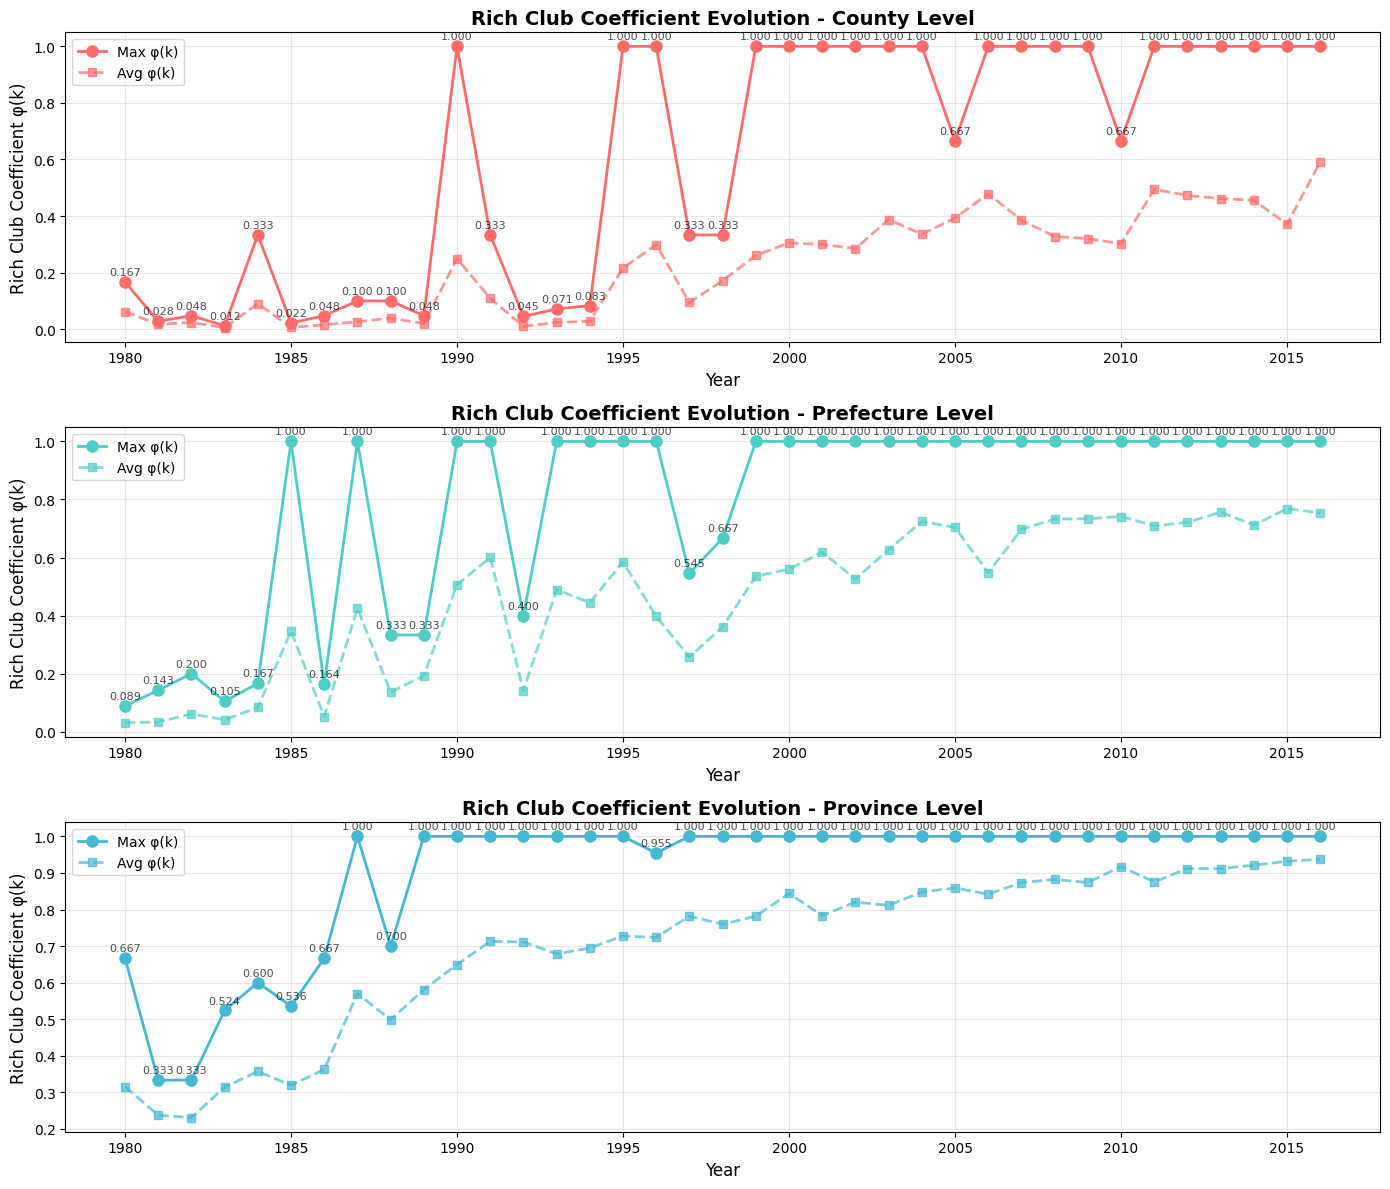


✓ Rich club coefficient evolution plot saved as 'rich_club_evolution.png'


In [5]:
# Visualize rich club coefficient evolution over time
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

granularities = ['county', 'prefecture', 'province']
colors = {'county': '#FF6B6B', 'prefecture': '#4ECDC4', 'province': '#45B7D1'}

for idx, granularity in enumerate(granularities):
    ax = axes[idx]
    
    # Filter data for this granularity (excluding 'all' years)
    data = rich_club_df[(rich_club_df['granularity'] == granularity) & (rich_club_df['year'] != 'all')]
    
    if len(data) > 0:
        # Convert year to numeric for plotting
        data_sorted = data.copy()
        data_sorted['year_num'] = pd.to_numeric(data_sorted['year'], errors='coerce')
        data_sorted = data_sorted.dropna(subset=['year_num']).sort_values('year_num')
        
        # Plot max rich club coefficient
        ax.plot(data_sorted['year_num'], data_sorted['max_rich_club_coef'], 
                marker='o', linewidth=2, markersize=8, 
                color=colors[granularity], label='Max φ(k)')
        
        # Plot average rich club coefficient
        ax.plot(data_sorted['year_num'], data_sorted['avg_rich_club_coef'], 
                marker='s', linewidth=2, markersize=6, alpha=0.7,
                color=colors[granularity], linestyle='--', label='Avg φ(k)')
        
        ax.set_xlabel('Year', fontsize=12)
        ax.set_ylabel('Rich Club Coefficient φ(k)', fontsize=12)
        ax.set_title(f'Rich Club Coefficient Evolution - {granularity.capitalize()} Level', 
                    fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Add value labels for max phi
        for _, row in data_sorted.iterrows():
            if not pd.isna(row['max_rich_club_coef']):
                ax.annotate(f"{row['max_rich_club_coef']:.3f}", 
                          (row['year_num'], row['max_rich_club_coef']),
                          textcoords="offset points", xytext=(0,5), 
                          ha='center', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig('rich_club_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Rich club coefficient evolution plot saved as 'rich_club_evolution.png'")

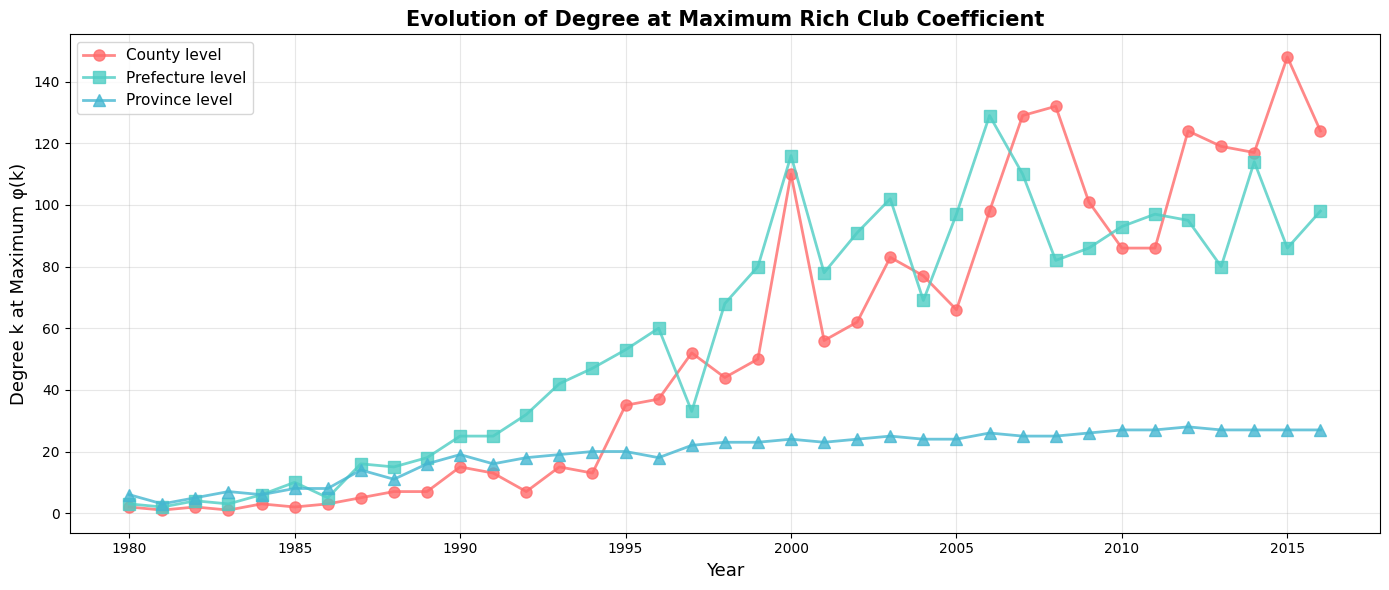


✓ k-value evolution plot saved as 'rich_club_k_evolution.png'


In [6]:
# Visualize k values at maximum rich club coefficient
fig, ax = plt.subplots(figsize=(14, 6))

granularities = ['county', 'prefecture', 'province']
colors = {'county': '#FF6B6B', 'prefecture': '#4ECDC4', 'province': '#45B7D1'}
markers = {'county': 'o', 'prefecture': 's', 'province': '^'}

for granularity in granularities:
    # Filter data for this granularity (excluding 'all' years)
    data = rich_club_df[(rich_club_df['granularity'] == granularity) & (rich_club_df['year'] != 'all')]
    
    if len(data) > 0:
        # Convert year to numeric for plotting
        data_sorted = data.copy()
        data_sorted['year_num'] = pd.to_numeric(data_sorted['year'], errors='coerce')
        data_sorted = data_sorted.dropna(subset=['year_num']).sort_values('year_num')
        
        # Plot k value at max phi
        ax.plot(data_sorted['year_num'], data_sorted['k_at_max_phi'], 
                marker=markers[granularity], linewidth=2, markersize=8, 
                color=colors[granularity], label=f'{granularity.capitalize()} level',
                alpha=0.8)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Degree k at Maximum φ(k)', fontsize=13)
ax.set_title('Evolution of Degree at Maximum Rich Club Coefficient', 
            fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rich_club_k_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ k-value evolution plot saved as 'rich_club_k_evolution.png'")

In [7]:
# Save rich club coefficient results to CSV
rich_club_df.to_csv('network_rich_club_coefficients.csv', index=False)
print("✓ Rich club coefficient data saved to: network_rich_club_coefficients.csv")

# Display summary table
print("\n" + "="*80)
print("RICH CLUB COEFFICIENT SUMMARY BY GRANULARITY AND YEAR")
print("="*80)
print(rich_club_df.to_string(index=False))

# Additional statistics
print("\n" + "="*80)
print("RICH CLUB STATISTICS BY GRANULARITY")
print("="*80)
summary_stats = rich_club_df.groupby('granularity').agg({
    'max_rich_club_coef': ['mean', 'std', 'min', 'max'],
    'avg_rich_club_coef': ['mean', 'std', 'min', 'max'],
    'k_at_max_phi': ['mean', 'std', 'min', 'max']
})
print(summary_stats)

✓ Rich club coefficient data saved to: network_rich_club_coefficients.csv

RICH CLUB COEFFICIENT SUMMARY BY GRANULARITY AND YEAR
granularity year  n_nodes  n_edges  max_k  max_rich_club_coef  avg_rich_club_coef  k_at_max_phi  phi_at_max  n_rich_club_levels
     county 1980      240      133      2            0.166667            0.061863             2    0.166667                   3
     county 1981      161       85      1            0.027778            0.017189             1    0.027778                   2
     county 1982      226      135      2            0.047619            0.023463             2    0.047619                   3
     county 1983      323      186      2            0.012195            0.005257             1    0.012195                   3
     county 1984      293      173      4            0.333333            0.090369             3    0.333333                   5
     county 1985      462      300      5            0.021739            0.005833             2    0.02